# Polymer Glass-Transition Temperature Prediction

### A reproducible polymer-informatics workflow for evaluating model generalisation across polymer families

| **Project information** | **Details** |
|---|---|
| **Author** | Teh Song Xuan |
| **Computational environment** | Python Conda environment (`polymer-tg`) |
| **Core libraries** | RDKit, pandas, NumPy, Matplotlib and scikit-learn |
| **Prediction target** | Reported glass-transition temperature, $T_g$ |
| **Primary evaluation metric** | Mean absolute error (MAE), reported in °C |
| **Supporting metrics** | RMSE and $R^2$ |
| **Molecular input** | Polymer repeat-unit SMILES |
| **Validation focus** | Random structure-grouped validation versus polymer-family holdout validation |

---

## Project overview

This project investigates whether polymer repeat-unit structure can be used to predict reported glass-transition temperature, $T_g$, and, more importantly, whether a model trained on known polymer chemistry can generalise to an unseen polymer family.

The workflow integrates **polymer data curation, RDKit molecular representation, supervised regression and chemistry-aware validation**.

| **Objective** | **Question being addressed** |
|---|---|
| **Traceable polymer-informatics workflow** | Can a reproducible structure-to-$T_g$ model be constructed from audited polymer data? |
| **Polymer-family generalisation** | Does predictive performance remain strong when an entire polymer family is excluded from model training? |

The project therefore evaluates more than model accuracy. Particular attention is given to **structural identity, data leakage, polymer-family overlap, reproducibility and domain of applicability**.

---

## Scientific motivation

Glass-transition temperature describes the temperature region over which segmental mobility changes substantially in an amorphous polymer.

Repeat-unit chemistry can influence $T_g$ through backbone rigidity, flexibility, aromaticity, steric effects and intermolecular interactions. However, reported $T_g$ may also depend on variables not consistently represented in the dataset, including molecular weight, tacticity, crystallinity, crosslinking, formulation, processing history and measurement conditions.

The model is therefore interpreted as predicting:

> **reported dataset $T_g$ from the available repeat-unit structural representation**

rather than calculating a unique, condition-independent physical $T_g$ for every polymer.

---

## Primary research question

> **Can a machine-learning model trained on known polymer families accurately predict the reported $T_g$ of polymers belonging to a family that was absent from training?**

The principal scientific comparison evaluates model performance under two validation strategies:

| **Validation component** | **Random structure-grouped validation** | **Polymer-family holdout validation** |
|---|---|---|
| **Purpose** | Measure prediction within broadly familiar chemical space | Test transfer to an unseen polymer family |
| **Training/test relationship** | Related polymers and families may occur in both partitions | The selected family is completely removed from training |
| **Structural leakage control** | Identical canonical structures cannot cross partitions | No structure carrying the held-out family label remains in training |
| **Scientific interpretation** | Primarily tests interpolation | Tests chemical-domain transfer |
| **Expected difficulty** | Lower | Higher |

Random structure-grouped validation is necessary as a conventional reference, but it cannot by itself establish generalisation to unfamiliar polymer chemistry.

Polymer-family holdout validation deliberately introduces a stronger chemical distribution shift. The difference between the two evaluations therefore provides evidence about how much apparent model performance depends on familiarity with the training chemical space.

---

## Leakage-control principles

| **Potential leakage source** | **Control applied** |
|---|---|
| Repeated structures | Canonical structures are grouped before splitting |
| PID identifiers | Retained for traceability but excluded from predictive features |
| Polymer-family labels | Used for validation only, not as molecular features |
| Multi-label families | Every structure carrying the held-out label is removed from training |
| Test-set information | Regression models are fitted on training data only. Descriptor filtering uses the complete dataset before splitting, so preprocessing is not fully independent of the test structures. |
| Reproducibility | Fixed modelling settings and random seed are recorded |

The central aim is therefore not simply to maximise $R^2$, but to determine **whether predictive accuracy survives a chemically meaningful change in the test domain**.

# 2. Dataset Selection, Structural Audit and Data Curation

## Dataset requirements

The experiment requires both molecular information for modelling and polymer-family information for generalisation testing.

| **Field** | **Role in the project** |
|---|---|
| `SMILES` | Repeat-unit structure for RDKit parsing, descriptors and fingerprints |
| `Tg` | Continuous prediction target |
| `Polymer Class` | Polymer-family labels for family analysis and holdout validation |
| `PID` | Record-level traceability during auditing and error analysis |

`Polymer Class` and `PID` are not used as predictive molecular features.

---

## Dataset selection

Several polymer-data resources were considered against these requirements.

| **Resource** | **Reason not used as the primary working dataset** |
|---|---|
| **PoLyInfo** | Highly relevant scientifically, but direct bulk extraction and redistribution were not suitable for the reproducible public workflow used here |
| **Khazana-associated datasets** | Primarily provide computational structures and calculated properties rather than the required combination of repeat-unit SMILES, reported T<sub>g</sub>, family labels and record identifiers |
| **polyVERSE** | Useful polymer resources are available, but no single reviewed table supplied all four fields required for this validation design |
| **Ramprasad/Kim T<sub>g</sub> collection** | Contains polymer T<sub>g</sub> data, but the required family and record-traceability fields were not available in one directly usable table |
| **RadonPy** | Primarily supports simulation-based polymer-property generation and would require a different simulation-centred workflow |
| **Third-party Kaggle dataset** | Contains repeat-unit SMILES, reported T<sub>g</sub>, polymer-class information and PID-style identifiers and was therefore selected |

These resources were not ranked by general scientific importance. Selection was based specifically on suitability for the **structure-to-property modelling, polymer-family holdout and traceability requirements of this experiment**.

---

## Working dataset and provenance

The working file is:

`Tg_SMILES_class_pid_polyinfo_median (1).csv`
**Dataset availability:**  
A Kaggle page listing `Tg_SMILES_class_pid_polyinfo_median.csv` is available at [Tg SMILES | PID | PolyInfo Class](https://www.kaggle.com/datasets/fridaycode/tg-smiles-pid-polyinfo-class). The local working copy is named `Tg_SMILES_class_pid_polyinfo_median (1).csv`. File-level equivalence with the currently hosted copy has not been independently verified.

The supplied file is treated as a:

> **third-party, PoLyInfo-related processed polymer dataset**

and not as an official PoLyInfo export.

The processed structure count closely corresponds to the **7,174-polymer T<sub>g</sub> modelling collection reported by Uddin and Fan (2024)**, who also investigated molecular descriptors and Morgan fingerprints for polymer T<sub>g</sub> prediction.

This numerical and methodological agreement supports a relationship between the datasets, but does not establish that the published authors created or used this exact PID- and polymer-class-enriched Kaggle file.

**Reference:**  
Uddin, M. J. & Fan, J. (2024). [*Interpretable Machine Learning Framework to Predict the Glass Transition Temperature of Polymers*](https://doi.org/10.3390/polym16081049). *Polymers*, **16**(8), 1049..

---

## Structural audit — key findings

The raw records were audited before modelling so that database-record identity was not confused with structural identity.

| **Audit result** | **Finding** | **Interpretation / decision** |
|---|---:|---|
| Source records | 7,208 | Original records retained for traceability |
| RDKit parsing failures | 0 | All supplied SMILES could be processed |
| Unique raw SMILES | 7,174 | Some structures occur in more than one source record |
| Unique canonical SMILES | 7,174 | Canonicalisation did not reveal additional hidden duplicates |
| SMILES rewritten by RDKit | 49 | Written representation changed; molecular graph did not |
| Additional repeated occurrences | 34 | Repeated source records require structure-level handling |
| Two connection points | 7,204 | Expected representation for most linear repeat units |
| Three connection points | 3 | Retained as unusual multi-connected structures |
| Four connection points | 1 | Retained and flagged rather than automatically removed |

The `*` atoms in the SMILES represent polymer connection sites rather than ordinary elements. Structures containing more than two connection points were therefore investigated but not rejected solely because they differ from the common linear-repeat-unit representation.

---

## Construction of the modelling dataset

The modelling table contains **one row per unique canonical RDKit structure**.

| **Situation** | **Data-curation rule** |
|---|---|
| Single source record | Original reported T<sub>g</sub> retained |
| Repeated canonical structure | Consolidated to one structure-level row |
| Multiple reported T<sub>g</sub> values for the same structure | Median used as the reproducible structure-level target |
| Multiple PIDs | All source PIDs retained for traceability |
| Source disagreement | Minimum, maximum, record count and disagreement information retained |
| Unusual T<sub>g</sub> | Not removed solely because it appears statistically extreme |

After consolidation, the primary modelling dataset contains:

> **7,174 unique canonical structure representations**

This prevents repeated structural inputs from receiving unintended statistical weight and prevents equivalent structures from appearing in both training and test partitions.

---

## Polymer-family handling

`Polymer Class` is a **multi-label field**. A structure may carry more than one family label, so family labels cannot be treated as mutually exclusive classes.

For a family \(F\) used as a holdout:

| **Set** | **Rule** |
|---|---|
| **Training set** | Every structure containing \(F\) is removed |
| **Primary test set** | Structures labelled exclusively as \(F\) |
| **Leakage requirement** | Structures containing \(F\) remaining in training = 0 |

This prevents a multi-label structure carrying the held-out family from remaining indirectly available to the model through another family label.

For the present experiment, a family is eligible for holdout analysis when it contains at least:

| **Criterion** | **Threshold** |
|---|---:|
| Total labelled structures | ≥ 100 |
| Exclusive structures | ≥ 50 |

Eleven polymer families satisfy both criteria.

These thresholds were defined before examining holdout model performance to avoid selecting families according to favourable results.

---

## Scope and limitations

The dataset does not consistently encode molecular weight distribution, tacticity, crystallinity, morphology, crosslink density, formulation, processing history or measurement conditions.

Consequently, disagreement in reported T<sub>g</sub> for apparently identical repeat-unit structures may represent **missing material or experimental information**, not simply database error.

The data-curation strategy therefore favours **traceability and investigation over aggressive deletion**.

# 3. Molecular Features, Modelling and Generalisation Analysis

## Modelling workflow

The curated structure-level dataset is converted into numerical molecular representations before regression modelling.

| **Stage** | **Representation / method** | **Purpose** |
|---|---|---|
| Molecular descriptors | RDKit physicochemical and topological descriptors | Represent broad structural and chemical characteristics |
| Structural fingerprints | Radius-2, 2,048-bit Morgan fingerprints | Represent local molecular substructures |
| Baseline | Training-target median | Establish a structure-blind reference |
| Objective 1 | Random structure-grouped validation | Measure prediction within broadly familiar chemical space |
| Objective 2 | Polymer-family holdout validation | Measure transfer to unseen polymer families |
| Generalisation diagnostics | Tanimoto similarity and prediction-error analysis | Relate prediction reliability to structural coverage |

---

## RDKit descriptor curation

The initial RDKit descriptor matrix was audited for numerical validity and redundancy.

| **Final descriptor check** | **Result** |
|---|---:|
| Polymer structures | 7,174 |
| Final descriptors | 186 |
| Missing values | 0 |
| Infinite values | 0 |
| Constant descriptors | 0 |
| Exact duplicate descriptors | 0 |
| Row alignment preserved | Yes |
| Raw `Ipc` retained | No |
| `log10(Ipc)` retained | Yes |

The raw `Ipc` descriptor spans an extremely large numerical range and is strongly related to molecular size and graph complexity. It was therefore replaced by `log10(Ipc)`, which preserves structural ordering while reducing extreme numerical scaling.

No polymer records were removed because of `Ipc`.

The resulting **186-descriptor matrix** is the final RDKit descriptor representation used for modelling.

---

## Morgan fingerprints

Morgan fingerprints were generated successfully for every structure.

| **Fingerprint setting** | **Result** |
|---|---:|
| Structures | 7,174 |
| Radius | 2 |
| Fingerprint length | 2,048 bits |
| Generation failures | 0 |
| Row alignment preserved | Yes |

Morgan fingerprints provide a complementary representation of local atomic environments and support structural-similarity analysis using the Tanimoto coefficient.

## How RDKit descriptors, Morgan fingerprints and Tanimoto similarity work together

The polymer structures in this project begin as **repeat-unit SMILES**. These SMILES provide a text representation of the chemical structure, but the machine-learning workflow needs numerical representations before the structures can be analysed.

Two complementary representations are therefore used:

- **RDKit molecular descriptors** — used mainly to provide numerical features for predicting reported T<sub>g</sub>.
- **Morgan fingerprints** — used mainly to compare how structurally similar one polymer is to another.

These two paths then come together when interpreting why prediction performance deteriorates for unseen polymer families.

```text
Polymer SMILES
      ↓
Canonical structure
      ↓
      ├──────── RDKit molecular descriptors
      │                ↓
      │        Regression models
      │                ↓
      │        Predicted reported Tg
      │                ↓
      │         Prediction error
      │
      └──────── Morgan fingerprints
                       ↓
               Tanimoto similarity
                       ↓
             Structural familiarity
                       ↓
                       └───────────────┐
                                       ↓
                         Explain family-holdout
                         generalisation behaviour

# Objective 1 — Random Structure-Grouped Validation

## Purpose

Objective 1 evaluates whether molecular structure can predict reported glass-transition temperature, $T_g$, when the test polymers are drawn from chemical space broadly represented in the training data.

To reduce structural leakage, the dataset is split at the **canonical repeat-unit structure level** rather than by individual rows. Canonically equivalent structures are therefore kept within the same partition.

The processed dataset is divided into an **80:20 training/test split** using a fixed random seed for reproducibility.

Key safeguards are:

* no canonical repeat-unit structure appears in both training and test sets;
* `PID` is retained only for traceability and is excluded from predictive features;
* `Polymer Class` is reserved for family analysis and is not used as a molecular predictor;
* reported $T_g$ is used only as the regression target;
* regression models are fitted using training data only; descriptor filtering was performed across the complete dataset before splitting;
* the test set is kept independent of model fitting.

This produces a **structure-aware random validation** that tests prediction on unseen structures while related polymer chemistry may still be represented in training.

---

## Baseline and regression models

A **training-median baseline** is first established. It predicts the same training-set median $T_g$ for every test polymer and therefore provides a structure-blind reference.

Four tree-based regression models are then evaluated using the same partition:

* Decision Tree Regressor
* Random Forest Regressor
* Extra Trees Regressor
* HistGradientBoosting Regressor

Using several model architectures helps determine whether observed performance is specific to one algorithm or reflects a broader relationship between the molecular descriptors and reported $T_g$.

---

## Evaluation metrics

| **Metric**    | **Interpretation**                                                                          |
| ------------- | ------------------------------------------------------------------------------------------- |
| **MAE (°C)**  | Primary metric; average absolute prediction error in temperature units                      |
| **RMSE (°C)** | Gives greater weight to large prediction errors                                             |
| **$R^2$**     | Measures how much variation in reported $T_g$ is explained relative to a constant predictor |

**MAE is used as the primary metric** because it is directly interpretable in °C and can be compared consistently across validation strategies.

---

## Scientific interpretation

Objective 1 primarily evaluates **interpolation**: whether the model can predict new structures that remain reasonably close to polymer chemistry represented during training.

Strong performance would indicate that the molecular descriptors contain useful structure–property information. It would not, however, demonstrate that the model can generalise to an entire polymer family absent from training.

That stricter question is addressed in Objective 2.

---

# Objective 2 — Polymer-Family Holdout Validation

## Purpose

Objective 2 evaluates whether the learned structure–$T_g$ relationships remain transferable when an entire polymer family is excluded from model training.

The central question is:

> **Can a model trained on known polymer families predict reported $T_g$ for an unseen polymer family?**

This provides a more demanding test of chemical generalisation than the random structure-grouped split.

---

## Family eligibility and leakage control

Polymer-family labels are cleaned before holdout analysis, and family eligibility is defined before examining model performance.

For this study, a family is eligible when it contains:

* at least **100 labelled structures**; and
* at least **50 structures exclusively assigned to that family**.

These thresholds provide sufficient data for a meaningful family-level evaluation without treating them as chemically fundamental cut-offs.

Some polymers have multiple family labels. To avoid family-level leakage:

* **all structures carrying the held-out family label are excluded from training**;
* the primary test set contains **structures exclusively assigned to the held-out family**.

A leakage check is performed for every experiment to confirm that no polymer carrying the held-out family label remains in the training set.

---

## Holdout procedure

Each eligible family is evaluated independently.

For each holdout:

1. one polymer family is designated as unseen test chemistry;
2. all structures associated with that family are removed from training;
3. exclusively labelled members of that family form the test set;
4. the same molecular descriptors and regression algorithms used in Objective 1 are applied;
5. the descriptor set established by dataset-wide filtering is reused, while each regression model is fitted only on the corresponding family-excluded training set;
6. MAE, RMSE and $R^2$ are calculated for the held-out family.

Each family holdout is therefore a separate model-training experiment rather than a conventional cross-validation fold.

---

## Comparison with Objective 1

Family-holdout performance is compared with random structure-grouped performance using the same metrics.

Particular attention is given to:

* family-specific MAE, RMSE and $R^2$;
* changes in MAE and $R^2$ relative to Objective 1;
* whether performance deterioration is consistent across several model architectures.

A reduction in accuracy is treated as a **scientific result rather than a modelling failure**, because it identifies where learned structure–property relationships do not transfer well to unfamiliar polymer chemistry.

---

## Structural similarity and polymer-informatics interpretation

Polymer-family labels are useful but do not directly measure chemical distance. Different families may share structural motifs, while polymers within one broad family may themselves be chemically diverse.

Morgan fingerprints and **Tanimoto similarity** are therefore used to quantify how structurally similar each held-out polymer is to the available training chemistry.

This allows the analysis to test whether poorer predictions are associated with greater structural distance from the training set.

Performance differences may also arise from:

* family-specific backbone chemistry, heteroatoms, rigidity or flexibility;
* differences in the reported-$T_g$ distribution between training and holdout families;
* variation in chemical diversity within broad polymer-family labels;
* limitations of repeat-unit RDKit descriptors;
* differences in how individual regression algorithms extrapolate beyond their training domain.

Structural similarity is therefore treated as one possible explanation for generalisation behaviour, not automatically as the sole cause.

---

## Overall validation strategy

| **Validation strategy**                               | **Question addressed**                                                             |
| ----------------------------------------------------- | ---------------------------------------------------------------------------------- |
| **Objective 1 — Random structure-grouped validation** | Can the model predict unseen structures within broadly familiar polymer chemistry? |
| **Objective 2 — Polymer-family holdout validation**   | Can the model transfer to an entire polymer family excluded from training?         |

Objective 1 mainly tests **interpolation**, whereas Objective 2 provides a stricter test of **chemical-domain generalisation**.

Together, the two experiments provide a more realistic assessment of predictive performance than random validation alone.

---

## Scope and limitations

The model is based on repeat-unit SMILES and derived molecular descriptors and therefore does not constitute a complete physical description of polymer glass transition.

Important factors such as molecular weight, tacticity, branching, copolymer composition, crystallinity, processing history and measurement conditions may not be represented consistently in the dataset.

The family-holdout experiment should therefore be interpreted as a **chemistry-aware stress test of model generalisation**, rather than proof that every structural motif in the held-out family is absent from training.

The combined objectives assess not only **how accurately reported $T_g$ can be predicted**, but also **how far the learned structure–property relationships remain transferable beyond the chemistry represented during training**.


import sys
from rdkit import rdBase

print("Python executable:", sys.executable)
print("RDKit version:", rdBase.rdkitVersion)

In [6]:
from pathlib import Path

raw_path = Path("..") / "data" / "raw" / "Tg_SMILES_class_pid_polyinfo_median (1).csv"

print("Current working directory:", Path.cwd())
print("Raw dataset path:", raw_path.resolve())
print("File exists:", raw_path.exists())

Current working directory: C:\Users\sufer\Documents\Polymer_Tg_Project\notebooks
Raw dataset path: C:\Users\sufer\Documents\Polymer_Tg_Project\data\raw\Tg_SMILES_class_pid_polyinfo_median (1).csv
File exists: True


In [7]:
import pandas as pd

df_raw = pd.read_csv(raw_path, encoding="utf-8-sig")

print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])
print("Column names:", df_raw.columns.tolist())

display(df_raw.head())

Number of rows: 7208
Number of columns: 4
Column names: ['SMILES', 'PID', 'Polymer Class', 'Tg']


,SMILES,PID,Polymer Class,Tg
0,*C*,P010001,Polyolefins,-54.0
1,*CC(*)C,P010002,Polyolefins,-3.0
2,*CC(*)CC,P010003,Polyolefins,-24.1
3,*CC(*)CCC,P010004,Polyolefins,-37.0
4,*CC(*)C(C)C,P010006,Polyolefins,60.0


In [8]:
quality_check = pd.DataFrame({
    "Data type": df_raw.dtypes.astype(str),
    "Missing values": df_raw.isna().sum(),
    "Missing percentage": (df_raw.isna().mean() * 100).round(2)
})

display(quality_check)

,Data type,Missing values,Missing percentage
SMILES,str,0,0.0
PID,str,0,0.0
Polymer Class,str,0,0.0
Tg,float64,0,0.0


In [9]:
duplicate_check = pd.Series({
    "Exact duplicate rows": int(df_raw.duplicated().sum()),
    "Duplicate PID values": int(df_raw["PID"].duplicated().sum()),
    "Unique PID values": int(df_raw["PID"].nunique()),
    "Unique SMILES values": int(df_raw["SMILES"].nunique()),
    "Repeated SMILES occurrences": int(df_raw["SMILES"].duplicated().sum())
}, name="Count").to_frame()

display(duplicate_check)

,Count
Exact duplicate rows,0
Duplicate PID values,0
Unique PID values,7208
Unique SMILES values,7174
Repeated SMILES occurrences,34


In [10]:
import sys
from rdkit import rdBase

print("Python executable:", sys.executable)
print("RDKit version:", rdBase.rdkitVersion)

Python executable: C:\Users\sufer\anaconda3\envs\polymer-tg\python.exe
RDKit version: 2026.03.1


In [11]:
tg_numeric = pd.to_numeric(df_raw["Tg"], errors="coerce")

tg_summary = pd.Series({
    "Original data type": str(df_raw["Tg"].dtype),
    "Total records": len(df_raw),
    "Non-numeric or missing values": int(tg_numeric.isna().sum()),
    "Minimum": tg_numeric.min(),
    "1st percentile": tg_numeric.quantile(0.01),
    "25th percentile": tg_numeric.quantile(0.25),
    "Median": tg_numeric.median(),
    "Mean": tg_numeric.mean(),
    "75th percentile": tg_numeric.quantile(0.75),
    "99th percentile": tg_numeric.quantile(0.99),
    "Maximum": tg_numeric.max(),
    "Standard deviation": tg_numeric.std()
}, name="Value").to_frame()

display(tg_summary)

,Value
Original data type,float64
Total records,7208
Non-numeric or missing values,0
Minimum,-139.0
1st percentile,-78.972
25th percentile,54.575
Median,134.0
Mean,141.405966
75th percentile,231.0
99th percentile,388.93


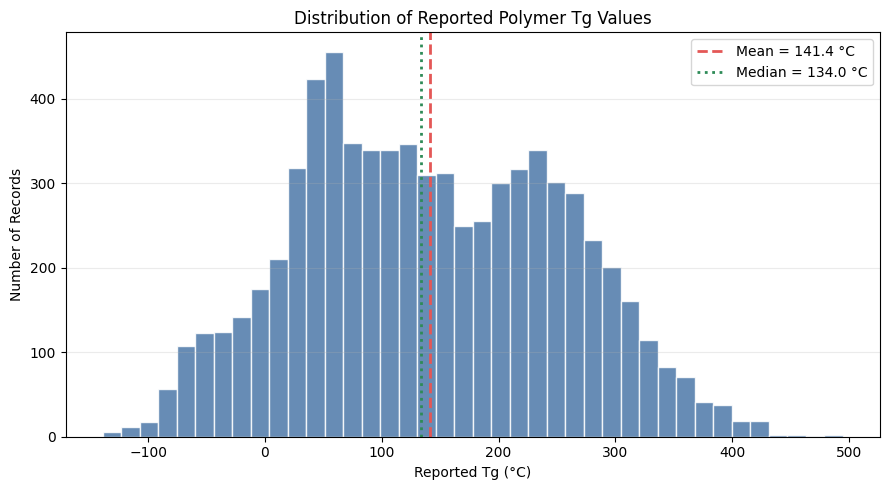

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    tg_numeric.dropna(),
    bins=40,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.85
)

ax.axvline(
    tg_numeric.mean(),
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {tg_numeric.mean():.1f} °C"
)

ax.axvline(
    tg_numeric.median(),
    color="#2E8B57",
    linestyle=":",
    linewidth=2,
    label=f"Median = {tg_numeric.median():.1f} °C"
)

ax.set_title("Distribution of Reported Polymer Tg Values")
ax.set_xlabel("Reported Tg (°C)")
ax.set_ylabel("Number of Records")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Distribution of reported glass-transition temperatures

The dataset contains 7,208 reported $T_g$ records ranging from $-139\,^\circ\mathrm{C}$ to $495\,^\circ\mathrm{C}$. The median is $134.0\,^\circ\mathrm{C}$ and the mean is approximately $141.4\,^\circ\mathrm{C}$. The slightly higher mean suggests modest extension towards higher reported temperatures.

The histogram shows a broad distribution with more than one apparent concentration region. This may reflect the presence of chemically different polymer families with different structure–property relationships. However, the histogram alone does not establish that the distribution contains distinct chemical populations because its appearance also depends on bin width and polymer-class composition.

Records at very low and very high reported $T_g$ values are comparatively uncommon. They will be investigated rather than removed automatically, as unusual temperatures may represent legitimate polymer chemistry rather than data errors.

In [14]:
raw_class_frequency = (
    df_raw["Polymer Class"]
    .value_counts(dropna=False)
    .rename_axis("Raw Polymer Class")
    .to_frame(name="Record Count")
)

raw_class_frequency["Percentage of Dataset"] = (
    raw_class_frequency["Record Count"] / len(df_raw) * 100
).round(2)

print(
    "Number of raw class labels or label combinations:",
    len(raw_class_frequency)
)

display(raw_class_frequency.head(30))

Number of raw class labels or label combinations: 198


,Record Count,Percentage of Dataset
Raw Polymer Class,,
"Polyacrylics, Polyvinyls",600,8.32
"Polyimides/thioimides, Polyoxides/ethers/acetals",454,6.30
Polyesters/thioesters,426,5.91
Polyamides/thioamides,401,5.56
Polyimides/thioimides,324,4.50
Polyoxides/ethers/acetals,301,4.18
"Polyoxides/ethers/acetals, Polyimines",252,3.50
Polysiloxanes/silanes,247,3.43
Polyvinyls,241,3.34


In [15]:
class_label_count = (
    df_raw["Polymer Class"]
    .astype("string")
    .str.split(",")
    .str.len()
)

label_count_distribution = (
    class_label_count
    .value_counts()
    .sort_index()
    .rename_axis("Number of Class Labels")
    .to_frame(name="Record Count")
)

label_count_distribution["Percentage of Dataset"] = (
    label_count_distribution["Record Count"] / len(df_raw) * 100
).round(2)

display(label_count_distribution)

,Record Count,Percentage of Dataset
Number of Class Labels,,
1,2828,39.23
2,3312,45.95
3,890,12.35
4,173,2.40
5,5,0.07


### Polymer-class label multiplicity

The `Polymer Class` field is a multi-label classification field. The values from one to five in the table represent the number of polymer-family labels assigned to each record; they are not class identifiers, rankings or modelling targets.

Of the 7,208 records, 2,828 records (39.23%) have one class label, while 4,380 records (60.77%) have two or more labels. Two-label records are the most common, accounting for 3,312 records (45.95%). Therefore, most records cannot be treated as belonging to mutually exclusive polymer classes.

A record with multiple labels is not automatically evidence of a copolymer. It indicates that the source classification associates the recorded structure with several polymer-family categories.

This result has an important implication for class-holdout validation. If a polymer family is held out, records containing that family within a multi-label combination must not remain in the training set. The individual labels will therefore be parsed and standardised before an explicit multi-label holdout rule is defined. This rule will be established before examining final model performance to prevent result-driven class selection.

In [17]:
from rdkit import Chem

df_structure = df_raw.copy()

# Ask RDKit to convert each SMILES string into a molecular structure
df_structure["rdkit_mol"] = df_structure["SMILES"].apply(Chem.MolFromSmiles)

# True means RDKit successfully understood the structure
df_structure["is_valid_smiles"] = df_structure["rdkit_mol"].notna()

print(f"Total records: {len(df_structure):,}")
print(f"Parsed successfully: {df_structure['is_valid_smiles'].sum():,}")
print(f"Failed to parse: {(~df_structure['is_valid_smiles']).sum():,}")

# Show up to 20 unsuccessful records for investigation
display(
    df_structure.loc[
        ~df_structure["is_valid_smiles"],
        ["PID", "SMILES", "Polymer Class", "Tg"]
    ].head(20)
)

Total records: 7,208
Parsed successfully: 7,208
Failed to parse: 0


,PID,SMILES,Polymer Class,Tg


### RDKit structure-parsing results

All **7,208 repeat-unit SMILES** were parsed successfully by RDKit, with no parsing exceptions. No records were excluded at this stage.

Successful parsing confirms that the supplied SMILES are syntactically compatible with RDKit and can proceed to canonicalisation, descriptor calculation and fingerprint generation. It does not, however, independently verify the chemical correctness of each repeat-unit representation, polymerisation site, or associated **reported \(Tg\)** value.

The structures were therefore retained for subsequent connection-point, canonicalisation and duplicate-structure auditing.

### Polymer connection-point audit

RDKit dummy atoms (`*`) were used to identify polymer connection points. Of the **7,208 records, 7,204 (99.94%)** contain the expected two connection points for a conventional linear repeat-unit representation. Three polyphenylene records contain three connection points, and one polysiloxane/silane record contains four.

Because these four structures parsed successfully and additional connection points may represent branched or multiply connected polymer architectures, they were not treated as errors without independent evidence. All records were retained, with `connection_point_count` preserved as an audit field for traceability and subsequent structural analysis.

In [20]:
# Generate a consistent RDKit representation for every parsed structure
df_structure["canonical_smiles"] = df_structure["rdkit_mol"].apply(
    lambda mol: Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=True
    )
)

canonicalisation_summary = pd.Series({
    "Total records": len(df_structure),
    "Unique raw SMILES": df_structure["SMILES"].nunique(),
    "Unique canonical SMILES": df_structure["canonical_smiles"].nunique(),
    "Missing canonical SMILES": (
        df_structure["canonical_smiles"].isna().sum()
    ),
    "Records whose SMILES text changed": (
        df_structure["SMILES"] != df_structure["canonical_smiles"]
    ).sum(),
    "Additional records beyond first canonical occurrence": (
        df_structure["canonical_smiles"].duplicated().sum()
    )
}).to_frame(name="Count")

display(canonicalisation_summary)

,Count
Total records,7208
Unique raw SMILES,7174
Unique canonical SMILES,7174
Missing canonical SMILES,0
Records whose SMILES text changed,49
Additional records beyond first canonical occurrence,34


### Canonicalisation of repeat-unit SMILES

All **7,208 repeat-unit SMILES** were successfully converted by RDKit into canonical SMILES, with no missing results.

The raw dataset contained **7,174 unique SMILES**, and the canonicalised dataset also contained **7,174 unique SMILES**. RDKit rewrote the text of **49 SMILES** into a standardised form, but this did not create any new duplicate structures. The **34 repeated records** were already duplicates in the original dataset.

Canonicalisation is useful because the same molecular structure can sometimes be written in different valid SMILES forms. RDKit converts these into a consistent representation so that equivalent structures can be grouped more reliably.

However, canonical SMILES describe the molecular graph supplied to RDKit and do not guarantee that every entry represents a chemically distinct polymer. Different choices of repeat-unit boundary or polymer connection points may still produce different SMILES for closely related or equivalent polymer structures.

All records were retained at this stage. The `canonical_smiles` field was used to group identical RDKit structures during duplicate auditing and train–test splitting, ensuring that the same canonical structure could not appear in both training and test sets.

### Canonicalisation of repeat-unit SMILES

All **7,208 repeat-unit SMILES** were successfully converted into canonical SMILES by RDKit.

The dataset contained **7,174 unique SMILES before canonicalisation and 7,174 unique canonical SMILES after canonicalisation**. RDKit changed the written form of **49 SMILES**, but these changes were only standardisations of how the same molecular graph was written. Canonicalisation did not reveal any new duplicate structures. The **34 repeated occurrences** were already present in the original dataset.

Canonicalisation is important because the same structure can sometimes be written in different valid SMILES forms. Converting them into one consistent representation makes structural grouping more reliable.

However, canonical SMILES do not guarantee that every entry represents a completely different polymer. The same polymer may sometimes be represented using different repeat-unit boundaries or connection points.

All records were therefore retained. The `canonical_smiles` column was used to group identical RDKit structures and, later, to ensure that the same canonical structure could not appear in both the training and test sets, reducing the risk of structural data leakage.

In [23]:
import pandas as pd
from rdkit import Chem
from IPython.display import display

# Check that the preceding structure-processing cells have run.
required_columns = [
    "PID",
    "SMILES",
    "canonical_smiles",
    "Polymer Class",
    "Tg"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_structure.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}. "
        "Run the preceding data-loading and canonicalisation cells first."
    )

# Count connection-point markers from the canonical repeat-unit graphs.
# RDKit represents these markers (*) as atoms with atomic number zero.
def count_connection_points(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(
            f"Cannot count connection points: invalid canonical SMILES {smiles!r}"
        )

    return sum(
        atom.GetAtomicNum() == 0
        for atom in mol.GetAtoms()
    )


# Recalculate explicitly so this cell does not depend on an earlier
# kernel session having created the column.
df_structure["connection_point_count"] = (
    df_structure["canonical_smiles"]
    .apply(count_connection_points)
    .astype("int64")
)

# Select every record belonging to a repeated canonical-structure group.
repeated_mask = (
    df_structure["canonical_smiles"]
    .duplicated(keep=False)
)

df_repeated_canonical = (
    df_structure.loc[
        repeated_mask,
        required_columns + ["connection_point_count"]
    ]
    .sort_values(["canonical_smiles", "PID"])
    .copy()
)

# Count records within each repeated canonical-structure group.
repeated_group_sizes = (
    df_repeated_canonical
    .groupby("canonical_smiles")
    .size()
)

repeated_structure_summary = pd.Series({
    "Repeated canonical-structure groups": len(repeated_group_sizes),
    "Records in repeated groups": len(df_repeated_canonical),
    "Additional occurrences beyond the first": (
        repeated_group_sizes.sub(1).sum()
    ),
    "Smallest repeated-group size": (
        repeated_group_sizes.min()
        if not repeated_group_sizes.empty else pd.NA
    ),
    "Largest repeated-group size": (
        repeated_group_sizes.max()
        if not repeated_group_sizes.empty else pd.NA
    )
}, dtype="Int64").to_frame(name="Count")

# Summarise how many groups contain each number of records.
group_size_distribution = (
    repeated_group_sizes
    .value_counts()
    .sort_index()
    .rename_axis("Records per Canonical Structure")
    .reset_index(name="Number of Structure Groups")
)

group_size_distribution["Total Records"] = (
    group_size_distribution["Records per Canonical Structure"]
    * group_size_distribution["Number of Structure Groups"]
)

display(repeated_structure_summary)
display(group_size_distribution)

,Count
Repeated canonical-structure groups,31
Records in repeated groups,65
Additional occurrences beyond the first,34
Smallest repeated-group size,2
Largest repeated-group size,3


,Records per Canonical Structure,Number of Structure Groups,Total Records
0,2,28,56
1,3,3,9


In [24]:
# Assign a short, reproducible audit ID to each repeated canonical structure
canonical_group_order = sorted(
    df_repeated_canonical["canonical_smiles"].unique()
)

canonical_to_group_id = {
    canonical: f"RG{number:03d}"
    for number, canonical in enumerate(canonical_group_order, start=1)
}

df_repeated_canonical["repeated_group_id"] = (
    df_repeated_canonical["canonical_smiles"]
    .map(canonical_to_group_id)
)

# Compare the records within each repeated canonical-structure group
repeated_group_audit = (
    df_repeated_canonical
    .groupby(
        ["repeated_group_id", "canonical_smiles"],
        as_index=False
    )
    .agg(
        record_count=("PID", "size"),
        unique_pid_count=("PID", "nunique"),
        unique_class_count=("Polymer Class", "nunique"),
        unique_tg_count=("Tg", "nunique"),
        tg_min=("Tg", "min"),
        tg_max=("Tg", "max")
    )
)

repeated_group_audit["tg_range"] = (
    repeated_group_audit["tg_max"]
    - repeated_group_audit["tg_min"]
).round(2)

repeated_group_summary = pd.Series({
    "Repeated canonical-structure groups": len(repeated_group_audit),
    "Groups with a different PID for every record": (
        repeated_group_audit["unique_pid_count"]
        == repeated_group_audit["record_count"]
    ).sum(),
    "Groups with identical polymer-class text": (
        repeated_group_audit["unique_class_count"] == 1
    ).sum(),
    "Groups with different polymer-class text": (
        repeated_group_audit["unique_class_count"] > 1
    ).sum(),
    "Groups with identical reported Tg": (
        repeated_group_audit["unique_tg_count"] == 1
    ).sum(),
    "Groups with different reported Tg": (
        repeated_group_audit["unique_tg_count"] > 1
    ).sum(),
    "Largest within-structure Tg range": (
        repeated_group_audit["tg_range"].max()
    )
}).to_frame(name="Count")

display(repeated_group_summary)

display(
    repeated_group_audit[
        [
            "repeated_group_id",
            "record_count",
            "unique_pid_count",
            "unique_class_count",
            "unique_tg_count",
            "tg_min",
            "tg_max",
            "tg_range"
        ]
    ]
    .sort_values(
        ["tg_range", "repeated_group_id"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

,Count
Repeated canonical-structure groups,31.0
Groups with a different PID for every record,31.0
Groups with identical polymer-class text,31.0
Groups with different polymer-class text,0.0
Groups with identical reported Tg,3.0
Groups with different reported Tg,28.0
Largest within-structure Tg range,115.0


,repeated_group_id,record_count,unique_pid_count,unique_class_count,unique_tg_count,tg_min,tg_max,tg_range
0,RG025,2,2,1,2,-22.0,93.00,115.00
1,RG002,2,2,1,2,53.0,149.00,96.00
2,RG003,3,3,1,3,-103.0,-69.00,34.00
3,RG006,2,2,1,2,63.0,90.20,27.20
4,RG001,2,2,1,2,-60.0,-35.00,25.00
5,RG022,2,2,1,2,-45.0,-20.00,25.00
6,RG012,2,2,1,2,262.0,286.00,24.00
7,RG004,3,3,1,3,-105.0,-92.50,12.50
8,RG029,2,2,1,2,61.1,73.05,11.95
9,RG023,2,2,1,2,69.4,80.45,11.05


### Agreement among records sharing the same canonical structure

The dataset contains **31 canonical structures that appear more than once**, corresponding to **65 records** in total. Each record has a different PID, and records sharing the same canonical structure also have the same polymer-class label.

However, their **reported \(Tg\)** values are often different. In **28 of the 31 repeated-structure groups (90.3%)**, the same canonical structure is associated with more than one reported \(Tg\). The largest difference within a single group is **115 °C**.

This matters because two records with the same canonical SMILES produce the same RDKit descriptors and fingerprints. In other words, the model sees essentially the same structural input but may be associated with different reported \(Tg\) values.

This does not necessarily mean that the data are wrong. Polymer \(Tg\) depends on factors that are not captured by repeat-unit SMILES alone, such as molecular weight, tacticity, crystallinity, branching, processing history and measurement conditions. The available dataset does not contain enough information to determine which of these factors caused the differences.

For this reason, repeated structures were not treated automatically as errors. During modelling, identical canonical structures were handled together so that the same structure could not appear in both the training and test sets. This reduces structural data leakage and gives a more realistic estimate of model performance.

In [26]:
# Create a traceable PID–Tg label for each record
df_repeated_canonical["pid_tg_pair"] = (
    df_repeated_canonical.apply(
        lambda row: (
            f"{row['PID']} → {float(row['Tg']):g} °C"
        ),
        axis=1
    )
)

# Place all records from the same canonical structure into one audit row
repeated_record_details = (
    df_repeated_canonical
    .sort_values(
        ["repeated_group_id", "Tg", "PID"]
    )
    .groupby(
        ["repeated_group_id", "canonical_smiles"],
        as_index=False
    )
    .agg(
        record_count=("PID", "size"),
        polymer_class=("Polymer Class", "first"),
        pid_tg_records=(
            "pid_tg_pair",
            lambda values: " | ".join(values)
        ),
        tg_min=("Tg", "min"),
        tg_max=("Tg", "max")
    )
)

repeated_record_details["tg_range"] = (
    repeated_record_details["tg_max"]
    - repeated_record_details["tg_min"]
).round(2)

# Display the groups from largest to smallest Tg disagreement
display(
    repeated_record_details[
        [
            "repeated_group_id",
            "record_count",
            "polymer_class",
            "pid_tg_records",
            "tg_min",
            "tg_max",
            "tg_range"
        ]
    ]
    .sort_values(
        ["tg_range", "repeated_group_id"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

,repeated_group_id,record_count,polymer_class,pid_tg_records,tg_min,tg_max,tg_range
0,RG025,2,Polyesters/thioesters,P390201 → -22 °C | P390202 → 93 °C,-22.0,93.00,115.00
1,RG002,2,Polydienes,P362019 → 53 °C | P360028 → 149 °C,53.0,149.00,96.00
2,RG003,3,Polydienes,P010071 → -103 °C | P010072 → -91 °C | P010070...,-103.0,-69.00,34.00
3,RG006,2,Polysiloxanes/silanes,P472165 → 63 °C | P472161 → 90.2 °C,63.0,90.20,27.20
4,RG001,2,Polydienes,P060003 → -60 °C | P060004 → -35 °C,-60.0,-35.00,25.00
5,RG022,2,"Polyvinyls, Polydienes",P050013 → -45 °C | P060015 → -20 °C,-45.0,-20.00,25.00
6,RG012,2,"Polyimides/thioimides, Polyoxides/ethers/aceta...",P432914 → 262 °C | P432912 → 286 °C,262.0,286.00,24.00
7,RG004,3,Polydienes,P010098 → -105 °C | P010068 → -99.6 °C | P0100...,-105.0,-92.50,12.50
8,RG029,2,Polysiloxanes/silanes,P472312 → 61.1 °C | P472149 → 73.05 °C,61.1,73.05,11.95
9,RG023,2,Polyoxides/ethers/acetals,P372595 → 69.4 °C | P372377 → 80.45 °C,69.4,80.45,11.05


### Record-level review and structure-level aggregation

The **31 repeated canonical structures** correspond to **65 separate PID records**. Most of these repeated structures have different **reported Tg** values: **28 of 31 groups (90.3%)** contain more than one value. The largest disagreements occur for `RG025` (**−22 to 93 °C; range 115 °C**) and `RG002` (**53 to 149 °C; range 96 °C**).

This matters because records with the same canonical SMILES produce the same RDKit descriptors and Morgan fingerprints. In simple terms, the model would see the **same structural input but different target Tg values**. This shows that repeat-unit structure alone cannot capture every factor affecting polymer Tg. Other influences may include molecular weight, tacticity, branching, crystallinity, processing history and measurement conditions, none of which are represented consistently in this dataset.

The available data cannot determine whether these differences arise from genuine material variation, different measurement or source conditions, computed versus experimental values, or upstream data inconsistencies. The disagreement should therefore be treated as **target uncertainty**, not automatically as an error.

For modelling, the data were consolidated to **one row per unique canonical SMILES**. When several records shared the same canonical structure, the **median reported Tg** was used as the structure-level target. The median reduces the influence of unusually high or low values, although it does not recover the missing experimental information and, for widely separated values, may not correspond to an actual measured sample.

All source PIDs and disagreement statistics were retained for traceability, including record count, minimum Tg, maximum Tg and Tg range. Singleton structures kept their original reported Tg. This produced a structure-level dataset of **7,174 unique canonical structures**, preventing repeated structures from receiving extra weight during model training while preserving the original 7,208-record dataset for audit purposes.

In [28]:
# Create one processed row for each unique canonical structure
df_processed = (
    df_structure
    .groupby("canonical_smiles", as_index=False)
    .agg(
        raw_smiles=("SMILES", "first"),
        raw_smiles_count=("SMILES", "nunique"),
        source_pids=(
            "PID",
            lambda values: " | ".join(
                sorted(values.astype(str))
            )
        ),
        source_record_count=("PID", "size"),
        polymer_class=("Polymer Class", "first"),
        class_text_count=("Polymer Class", "nunique"),
        connection_point_count=(
            "connection_point_count",
            "first"
        ),
        connection_point_count_variants=(
            "connection_point_count",
            "nunique"
        ),
        Tg=("Tg", "median"),
        source_tg_unique_count=("Tg", "nunique"),
        source_tg_min=("Tg", "min"),
        source_tg_max=("Tg", "max")
    )
    .sort_values("canonical_smiles")
    .reset_index(drop=True)
)

# Add traceability and disagreement fields
df_processed["source_tg_range"] = (
    df_processed["source_tg_max"]
    - df_processed["source_tg_min"]
).round(2)

df_processed["tg_conflict"] = (
    df_processed["source_tg_unique_count"] > 1
)

df_processed["was_aggregated"] = (
    df_processed["source_record_count"] > 1
)

df_processed["repeated_group_id"] = (
    df_processed["canonical_smiles"]
    .map(canonical_to_group_id)
)

# Verify that the structure-level dataset was created correctly
processed_dataset_summary = pd.Series({
    "Original records in df_raw": len(df_raw),
    "Processed structure-level records": len(df_processed),
    "Rows consolidated": len(df_raw) - len(df_processed),
    "Unique canonical SMILES": (
        df_processed["canonical_smiles"].nunique()
    ),
    "Repeated canonical SMILES remaining": (
        df_processed["canonical_smiles"].duplicated().sum()
    ),
    "Structures combining multiple source records": (
        df_processed["was_aggregated"].sum()
    ),
    "Structures with conflicting reported Tg": (
        df_processed["tg_conflict"].sum()
    ),
    "Structures with conflicting class text": (
        df_processed["class_text_count"].gt(1).sum()
    ),
    "Structures with inconsistent connection-point counts": (
        df_processed["connection_point_count_variants"].gt(1).sum()
    ),
    "Missing processed Tg values": (
        df_processed["Tg"].isna().sum()
    ),
    "Original df_raw records after processing": len(df_raw)
}).to_frame(name="Count")

display(processed_dataset_summary)

,Count
Original records in df_raw,7208
Processed structure-level records,7174
Rows consolidated,34
Unique canonical SMILES,7174
Repeated canonical SMILES remaining,0
Structures combining multiple source records,31
Structures with conflicting reported Tg,28
Structures with conflicting class text,0
Structures with inconsistent connection-point counts,0
Missing processed Tg values,0


### Creation and validation of the structure-level dataset

The original dataset contained **7,208 records**. After grouping repeated canonical structures, the processed dataset contained **7,174 unique canonical structures** — a reduction of **34 rows**, exactly matching the number of repeated canonical-SMILES occurrences identified earlier.

The processed dataset passed the main validation checks:

- **7,174 unique canonical SMILES** and no repeated canonical structures;
- **31 structures** were formed from multiple source records;
- **28 of these 31 structures** had differing reported Tg values;
- no conflicts were found in polymer-class text or connection-point counts; and
- no processed Tg values were missing.

The purpose of this step is to move from a **record-level dataset** to a **structure-level dataset**, where each canonical repeat-unit structure appears only once. For repeated structures, the median reported Tg was used as the structure-level target. In simple terms, this prevents the same molecular structure from being counted several times during modelling simply because it appeared under several PIDs.

The aggregation rule improves the statistical independence of the modelling data, but the median reported Tg should not be interpreted as the unique physical Tg of that polymer. For the 28 structures with conflicting source values, differences may reflect molecular weight, tacticity, crystallinity, processing or measurement conditions, or other information not available in the dataset.

`df_processed` was therefore accepted as the main structure-level dataset for subsequent feature generation and modelling. The original **7,208-row `df_raw` dataset was preserved unchanged**, while source PIDs, record counts and Tg-disagreement fields were retained for traceability. PID information was used only for auditing and was not included as a predictive feature.

In [30]:
# Create the same descriptive summary for raw and processed Tg values
def summarise_tg(values):
    values = pd.to_numeric(values, errors="coerce")

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return pd.Series({
        "Record count": len(values),
        "Missing values": values.isna().sum(),
        "Minimum (°C)": values.min(),
        "First quartile, Q1 (°C)": q1,
        "Median (°C)": values.median(),
        "Mean (°C)": values.mean(),
        "Third quartile, Q3 (°C)": q3,
        "Maximum (°C)": values.max(),
        "Standard deviation (°C)": values.std(),
        "Interquartile range (°C)": q3 - q1
    })

tg_distribution_comparison = pd.concat(
    [
        summarise_tg(df_raw["Tg"]).rename(
            "Raw record-level data"
        ),
        summarise_tg(df_processed["Tg"]).rename(
            "Processed structure-level data"
        )
    ],
    axis=1
)

tg_distribution_comparison["Change after aggregation"] = (
    tg_distribution_comparison[
        "Processed structure-level data"
    ]
    - tg_distribution_comparison[
        "Raw record-level data"
    ]
)

display(tg_distribution_comparison.round(2))

,Raw record-level data,Processed structure-level data,Change after aggregation
Record count,7208.00,7174.00,-34.00
Missing values,0.00,0.00,0.00
Minimum (°C),-139.00,-139.00,0.00
"First quartile, Q1 (°C)",54.58,55.00,0.42
Median (°C),134.00,134.00,0.00
Mean (°C),141.41,141.95,0.54
"Third quartile, Q3 (°C)",231.00,231.00,0.00
Maximum (°C),495.00,495.00,0.00
Standard deviation (°C),112.40,112.18,-0.21
Interquartile range (°C),176.42,176.00,-0.43


### Effect of canonical-structure aggregation on the reported Tg distribution

Canonical-structure aggregation reduced the dataset from **7,208 records to 7,174 unique structures**, consolidating 34 repeated occurrences.

The overall reported Tg distribution changed very little. The **minimum (−139 °C), median (134 °C), third quartile (231 °C) and maximum (495 °C)** remained unchanged. Other summary statistics shifted by less than **1 °C**:

| Measure | Raw data | Processed data | Change |
|---|---:|---:|---:|
| First quartile | 54.58 °C | 55.00 °C | +0.42 °C |
| Mean | 141.41 °C | 141.95 °C | +0.54 °C |
| Standard deviation | 112.40 °C | 112.18 °C | −0.21 °C |
| Interquartile range | 176.42 °C | 176.00 °C | −0.43 °C |

In simple terms, combining repeated structures **removed their extra weighting without noticeably changing the overall Tg distribution**. The mean and median describe the centre of the data, while the standard deviation and interquartile range describe how widely the Tg values are spread.

These small overall changes do not mean that every repeated structure had similar Tg values. Some repeated structures showed large within-group disagreements, so median aggregation should be viewed as a practical structure-level summary rather than the unique physical Tg of a polymer.

The aggregation rule was therefore retained for modelling because it produces one row per canonical structure, avoids repeated structures influencing the model more than once, and preserves the main statistical characteristics of the reported Tg dataset.

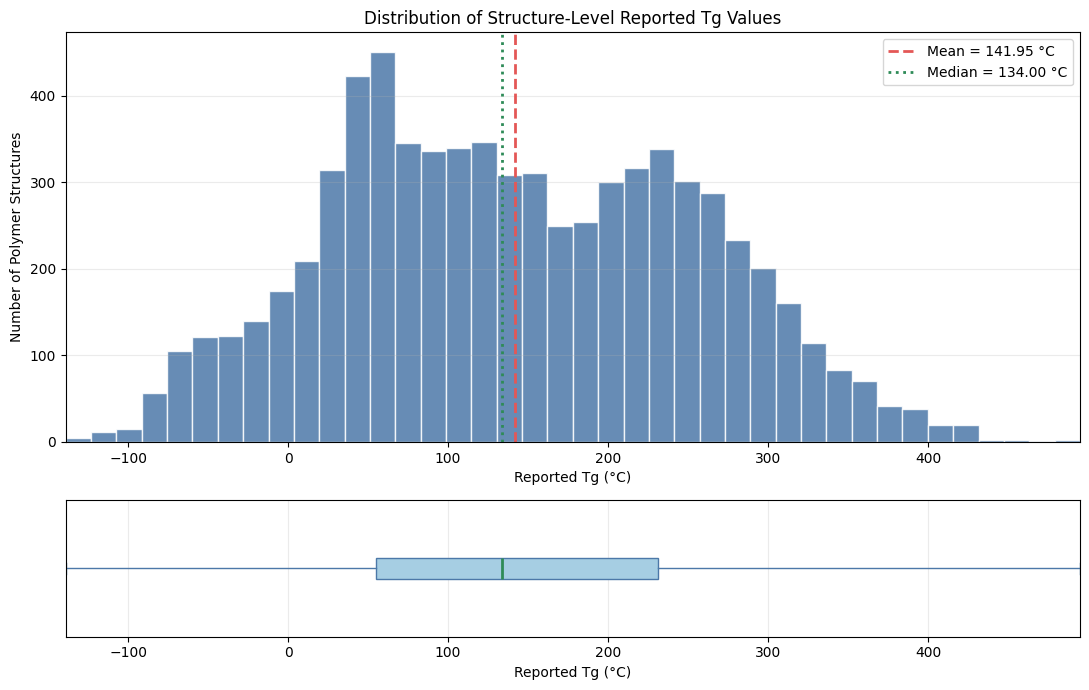

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare the original and processed Tg values
raw_tg_for_bins = pd.to_numeric(
    df_raw["Tg"],
    errors="coerce"
).dropna()

tg_processed = pd.to_numeric(
    df_processed["Tg"],
    errors="coerce"
).dropna()

# Reproduce the original histogram setting of 40 bins
# and save the exact raw-data bin edges
raw_bin_edges = np.histogram_bin_edges(
    raw_tg_for_bins,
    bins=40
)

common_x_limits = (
    raw_tg_for_bins.min(),
    raw_tg_for_bins.max()
)

tg_mean = tg_processed.mean()
tg_median = tg_processed.median()

# Create the processed-data histogram and boxplot
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 7),
    gridspec_kw={"height_ratios": [3, 1]}
)

# Histogram using the exact raw-data bin edges
axes[0].hist(
    tg_processed,
    bins=raw_bin_edges,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.85
)

# Use the same line colours and styles as the original plot
axes[0].axvline(
    tg_mean,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {tg_mean:.2f} °C"
)

axes[0].axvline(
    tg_median,
    color="#2E8B57",
    linestyle=":",
    linewidth=2,
    label=f"Median = {tg_median:.2f} °C"
)

axes[0].set_title(
    "Distribution of Structure-Level Reported Tg Values"
)
axes[0].set_xlabel("Reported Tg (°C)")
axes[0].set_ylabel("Number of Polymer Structures")
axes[0].set_xlim(common_x_limits)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

# Boxplot for the processed structure-level Tg values
axes[1].boxplot(
    tg_processed,
    orientation="horizontal",
    whis=1.5,
    showfliers=True,
    patch_artist=True,
    boxprops={
        "facecolor": "#A6CEE3",
        "edgecolor": "#4C78A8"
    },
    medianprops={
        "color": "#2E8B57",
        "linewidth": 2
    },
    whiskerprops={"color": "#4C78A8"},
    capprops={"color": "#4C78A8"},
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#E45756",
        "markeredgecolor": "#E45756",
        "alpha": 0.65
    }
)

axes[1].set_xlabel("Reported Tg (°C)")
axes[1].set_xlim(common_x_limits)
axes[1].set_yticks([])
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Comparison of the original and processed reported $T_g$ distributions

Aggregation reduced **7,208 records to 7,174 unique canonical structures**, consolidating 34 additional occurrences (approximately **0.47%** of the original records). Each canonical structure now contributes one reported $T_g$ value, calculated as the median of its associated records.

| **Measure** | **Original record-level data** | **Processed structure-level data** | **Change** |
|---|---:|---:|---:|
| Record or structure count | 7,208 | 7,174 | −34 |
| Minimum | −139.00 °C | −139.00 °C | 0.00 °C |
| First quartile | 54.58 °C | 55.00 °C | +0.42 °C |
| Median | 134.00 °C | 134.00 °C | 0.00 °C |
| Mean | 141.41 °C | 141.95 °C | +0.54 °C |
| Third quartile | 231.00 °C | 231.00 °C | 0.00 °C |
| Maximum | 495.00 °C | 495.00 °C | 0.00 °C |
| Standard deviation | 112.40 °C | 112.18 °C | −0.21 °C |
| Interquartile range | 176.42 °C | 176.00 °C | −0.43 °C |

*Changes were calculated before rounding, so they may differ slightly from subtracting the displayed values.*

The overall distribution changed very little. The minimum, median, third quartile and maximum remained unchanged, while all other temperature summary statistics changed by less than **1 °C**. The mean and median describe the centre of the distribution; the standard deviation and interquartile range describe its spread.

**What the figures show.** Each histogram bar counts entries within a temperature interval. In the processed-data boxplot, the box extends from **55 to 231 °C**, covering the middle 50% of reported $T_g$ values. The line inside the box marks the median of **134 °C**.

Both histograms use the same **40 temperature intervals** and horizontal range. However, the original histogram counts records, while the processed histogram counts canonical structures. Their vertical-axis scales should therefore be checked when comparing bar heights.

**Why aggregation matters.** A structure recorded three times previously contributed three entries to the distribution. After aggregation, it contributes one entry, just like a structure recorded once. This removes extra weighting caused by repeated records. Here, changing those weights and replacing repeated values with their median had little effect on the overall distribution.

**Scientific limitations.** Similar overall distributions do not mean that repeated records agree. Median aggregation summarises disagreements but cannot explain them or recover missing information about molecular weight, tacticity, processing history or measurement conditions. For two different reported values, the median lies halfway between them and may not represent an observed sample. A canonical repeat-unit representation therefore does not establish one uniquely determined physical $T_g$.

The **processed structure-level dataset is retained for exploratory analysis, molecular-feature generation and modelling**, with no missing target values. Original PID-level records and disagreement statistics are retained for traceability. Values near either end of the distribution are not excluded solely because they are unusual.

Polymer-family analysis examines whether the more populated temperature regions are associated with particular families; the histogram alone cannot establish that relationship.

In [34]:
# Convert each comma-separated class combination into individual labels
def parse_polymer_class_labels(value):
    if pd.isna(value):
        return []

    labels = [
        label.strip()
        for label in str(value).split(",")
        if label.strip()
    ]

    # Remove accidental repeated labels while preserving their order
    return list(dict.fromkeys(labels))


df_processed["class_labels"] = (
    df_processed["polymer_class"]
    .apply(parse_polymer_class_labels)
)

df_processed["class_label_count"] = (
    df_processed["class_labels"]
    .apply(len)
)

# Create one row per structure–family assignment
class_assignments = (
    df_processed[
        ["canonical_smiles", "class_labels"]
    ]
    .explode("class_labels")
    .rename(
        columns={"class_labels": "polymer_family"}
    )
)

# Count how frequently each individual family occurs
class_frequency = (
    class_assignments["polymer_family"]
    .value_counts()
    .rename_axis("Polymer Family")
    .reset_index(name="Structure Count")
)

class_frequency["Percentage of Structures"] = (
    class_frequency["Structure Count"]
    / len(df_processed)
    * 100
).round(2)

# Count structures carrying one, two or more labels
class_multiplicity = (
    df_processed["class_label_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of Class Labels")
    .reset_index(name="Structure Count")
)

class_multiplicity["Percentage of Structures"] = (
    class_multiplicity["Structure Count"]
    / len(df_processed)
    * 100
).round(2)

# Overall parsing checks
class_parsing_summary = pd.Series({
    "Processed structures": len(df_processed),
    "Unique individual polymer-family labels": (
        class_assignments["polymer_family"].nunique()
    ),
    "Total structure–family assignments": (
        class_assignments["polymer_family"].notna().sum()
    ),
    "Structures with no parsed class label": (
        df_processed["class_label_count"].eq(0).sum()
    ),
    "Structures with one class label": (
        df_processed["class_label_count"].eq(1).sum()
    ),
    "Structures with multiple class labels": (
        df_processed["class_label_count"].gt(1).sum()
    ),
    "Maximum labels assigned to one structure": (
        df_processed["class_label_count"].max()
    )
}).to_frame(name="Count")

display(class_parsing_summary)
display(class_multiplicity)
display(class_frequency)

,Count
Processed structures,7174
Unique individual polymer-family labels,22
Total structure–family assignments,12795
Structures with no parsed class label,0
Structures with one class label,2802
Structures with multiple class labels,4372
Maximum labels assigned to one structure,5


,Number of Class Labels,Structure Count,Percentage of Structures
0,1,2802,39.06
1,2,3306,46.08
2,3,888,12.38
3,4,173,2.41
4,5,5,0.07


,Polymer Family,Structure Count,Percentage of Structures
0,Polyoxides/ethers/acetals,2673,37.26
1,Polyimides/thioimides,1750,24.39
2,Polyamides/thioamides,1383,19.28
3,Polyimines,1234,17.20
4,Polyesters/thioesters,1088,15.17
5,Polyvinyls,1087,15.15
6,Polyketones/thioketones,638,8.89
7,Polyacrylics,601,8.38
8,Polysulfones/sulfoxides/sufonates/sulfoamides,427,5.95
9,Polysiloxanes/silanes,364,5.07


### Interpretation of polymer-family coverage

The **7,174 processed structures span 22 polymer-family labels**, with every structure assigned at least one label. **Multiple labels occur in 60.94% of structures**, producing 12,795 structure–family assignments. These assignments count family memberships, not additional structures: a structure with two labels contributes once to each family’s count. Family percentages therefore overlap and do not sum to 100%.

Family representation is uneven, ranging from **2,673 structures for Polyoxides/ethers/acetals** to **31 for Polyhalo-olefins**. Overall prediction scores may therefore conceal weaker performance in less-represented families. Family counts describe dataset coverage, but do not establish how structurally diverse each family is.

This overlap also affects family-holdout validation. **All structures carrying the held-out family label must be excluded from training**, even when they carry other labels. Under the exclusive-family test rule used in this project, only structures labelled solely with that family enter the test set; its test-set size is therefore smaller than or equal to its total count above.

The parsed labels are retained for family-level analysis and validation, rather than used as predictive molecular features. Having no missing labels confirms complete parsing coverage, but does not independently verify the chemical correctness of the classifications.

In [36]:
from collections import Counter

family_overlap_rows = []

for family in sorted(class_assignments["polymer_family"].dropna().unique()):
    family_mask = df_processed["class_labels"].apply(
        lambda labels: family in labels
    )
    family_structures = df_processed.loc[family_mask]

    total_count = len(family_structures)
    exclusive_count = family_structures["class_label_count"].eq(1).sum()
    multi_label_count = family_structures["class_label_count"].gt(1).sum()

    overlapping_labels = Counter(
        overlapping_family
        for labels in family_structures["class_labels"]
        for overlapping_family in labels
        if overlapping_family != family
    )

    most_common_overlaps = "; ".join(
        f"{label} ({count})"
        for label, count in overlapping_labels.most_common(3)
    )

    family_overlap_rows.append({
        "Polymer Family": family,
        "Total Structures": total_count,
        "Exclusive Structures": exclusive_count,
        "Multi-label Structures": multi_label_count,
        "Multi-label Percentage": round(
            100 * multi_label_count / total_count, 2
        ),
        "Three Most Common Overlapping Families": (
            most_common_overlaps if most_common_overlaps else "None"
        )
    })

family_overlap_summary = (
    pd.DataFrame(family_overlap_rows)
    .sort_values(
        ["Total Structures", "Exclusive Structures"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(family_overlap_summary)

,Polymer Family,Total Structures,Exclusive Structures,Multi-label Structures,Multi-label Percentage,Three Most Common Overlapping Families
0,Polyoxides/ethers/acetals,2673,298,2375,88.85,Polyimides/thioimides (925); Polyamides/thioam...
1,Polyimides/thioimides,1750,324,1426,81.49,Polyoxides/ethers/acetals (925); Polyamides/th...
2,Polyamides/thioamides,1383,401,982,71.01,Polyoxides/ethers/acetals (589); Polyimides/th...
3,Polyimines,1234,216,1018,82.50,Polyoxides/ethers/acetals (568); Polyesters/th...
4,Polyesters/thioesters,1088,424,664,61.03,Polyoxides/ethers/acetals (319); Polyamides/th...
5,Polyvinyls,1087,241,846,77.83,Polyacrylics (601); Polystyrenes (237); Polydi...
6,Polyketones/thioketones,638,4,634,99.37,Polyoxides/ethers/acetals (421); Polyimides/th...
7,Polyacrylics,601,0,601,100.00,Polyvinyls (601); Polystyrenes (1)
8,Polysulfones/sulfoxides/sufonates/sulfoamides,427,27,400,93.68,Polyoxides/ethers/acetals (271); Polyimides/th...
9,Polysiloxanes/silanes,364,239,125,34.34,Polyoxides/ethers/acetals (54); Polyimines (29...


### Polymer-family exclusivity and label overlap

This analysis distinguishes **exclusive structures**, which carry only the family label being examined, from **multi-label structures**, which also carry other family labels. For each family, these two counts add up to its total structure count.

For example, **Polyoxides/ethers/acetals contains 2,673 structures**, but only **298** carry this label alone. The remaining **2,375 (88.85%)** also belong to other labelled families. In the overlap column, **Polyimides/thioimides (925)** means that 925 structures carry both labels; some may carry additional labels as well.

Overlap varies substantially between families. All **601 Polyacrylics** structures and all **237 Polystyrenes** structures also carry the Polyvinyls label, leaving neither family with an exclusively labelled subset. By comparison, **239 of 364 Polysiloxanes/silanes structures** are exclusive, while all **100 Polyphenylenes structures** carry that label alone. A large total family count therefore does not necessarily provide a large exclusive test set.

**Implication for family-holdout validation.** The project uses exclusively labelled structures for testing and excludes every structure carrying the held-out label from training. For a Polyoxides/ethers/acetals holdout:

- **298 exclusive structures enter the test set.**
- **All 2,673 structures carrying this label are excluded from training.**
- The **2,375 multi-label structures enter neither partition** for this particular holdout.

This prevents the held-out label from remaining in training through structures that also have other labels. However, removing overlapping structures also reduces the training coverage of other families. The resulting performance therefore reflects both the withheld family and the training data remaining after exclusion.

**Label exclusivity does not establish chemical distinctness.** A structure with one label may still share molecular fragments with structures in other families. Similarly, multiple labels do not automatically indicate a polymer blend or copolymer. These results describe the supplied classifications; structural-similarity analysis is needed to assess how different the test structures are from the training structures.

All structures and labels are retained in the processed dataset. Exclusivity and overlap inform holdout eligibility and partitioning, rather than serving as reasons to delete records.

In [38]:
# Predefined preliminary eligibility thresholds
minimum_total_structures = 100
minimum_exclusive_structures = 50

family_holdout_eligibility = family_overlap_summary.copy()

family_holdout_eligibility["Meets Total-Size Rule"] = (
    family_holdout_eligibility["Total Structures"]
    >= minimum_total_structures
)

family_holdout_eligibility["Meets Exclusive-Size Rule"] = (
    family_holdout_eligibility["Exclusive Structures"]
    >= minimum_exclusive_structures
)

family_holdout_eligibility["Preliminary Status"] = (
    family_holdout_eligibility[
        ["Meets Total-Size Rule", "Meets Exclusive-Size Rule"]
    ]
    .all(axis=1)
    .map({
        True: "Preliminarily eligible",
        False: "Not preliminarily eligible"
    })
)

family_holdout_eligibility["Reason"] = (
    family_holdout_eligibility.apply(
        lambda row:
            "Meets both predefined thresholds"
            if (
                row["Meets Total-Size Rule"]
                and row["Meets Exclusive-Size Rule"]
            )
            else (
                "Below total-size and exclusive-size thresholds"
                if (
                    not row["Meets Total-Size Rule"]
                    and not row["Meets Exclusive-Size Rule"]
                )
                else (
                    "Below total-size threshold"
                    if not row["Meets Total-Size Rule"]
                    else "Below exclusive-size threshold"
                )
            ),
        axis=1
    )
)

eligibility_columns = [
    "Polymer Family",
    "Total Structures",
    "Exclusive Structures",
    "Multi-label Percentage",
    "Preliminary Status",
    "Reason"
]

display(family_holdout_eligibility[eligibility_columns])

,Polymer Family,Total Structures,Exclusive Structures,Multi-label Percentage,Preliminary Status,Reason
0,Polyoxides/ethers/acetals,2673,298,88.85,Preliminarily eligible,Meets both predefined thresholds
1,Polyimides/thioimides,1750,324,81.49,Preliminarily eligible,Meets both predefined thresholds
2,Polyamides/thioamides,1383,401,71.01,Preliminarily eligible,Meets both predefined thresholds
3,Polyimines,1234,216,82.50,Preliminarily eligible,Meets both predefined thresholds
4,Polyesters/thioesters,1088,424,61.03,Preliminarily eligible,Meets both predefined thresholds
5,Polyvinyls,1087,241,77.83,Preliminarily eligible,Meets both predefined thresholds
6,Polyketones/thioketones,638,4,99.37,Not preliminarily eligible,Below exclusive-size threshold
7,Polyacrylics,601,0,100.00,Not preliminarily eligible,Below exclusive-size threshold
8,Polysulfones/sulfoxides/sufonates/sulfoamides,427,27,93.68,Not preliminarily eligible,Below exclusive-size threshold
9,Polysiloxanes/silanes,364,239,34.34,Preliminarily eligible,Meets both predefined thresholds


### Preliminary eligibility for polymer-family holdout evaluation

**Eleven of the 22 polymer families met both screening requirements:** at least **100 total structures** carrying the family label and at least **50 label-exclusive structures**. A label-exclusive structure carries only the family label being assessed.

These requirements serve different purposes. The **100-structure threshold** sets a minimum level of overall family representation. The **50-exclusive-structure threshold** sets the minimum test-set size under this project's holdout design, because only exclusively labelled structures enter the test set. Every structure carrying the held-out label is excluded from training, including multi-label structures.

For example, **Polyoxides/ethers/acetals passes with 2,673 total structures and 298 exclusive structures**: its holdout test set contains 298 structures, while all 2,673 are excluded from training. **Polyphenylenes also passes**, with 100 total structures, all exclusive. In contrast, **Polyketones/thioketones fails despite having 638 structures**, because only four are exclusive.

Of the 11 families that did not qualify, six met the total-size requirement but lacked 50 exclusive structures. Polyolefins had 55 exclusive structures but failed the 100-total requirement; four other families failed both requirements. Polyacrylics, Polystyrenes and Polyphosphazenes had no exclusive structures, so they cannot provide a test set under the current exclusive-family design. Evaluating them would require a different, explicitly defined holdout design.

**These thresholds are practical choices for this project, not universal statistical standards.** Passing them does not guarantee reliable performance estimates, a broad reported $T_g$ range or chemical separation from the training data. In particular, having only one family label does not mean that a structure lacks molecular similarities to other families. Reported $T_g$ distributions and structural similarity are therefore examined separately to interpret holdout performance.

All **7,174 structures and 22 family labels remain in the processed dataset**, with the supplied labels preserved. Failing this screen excludes a family from selection as a holdout target; it does not identify its records as invalid or automatically remove them from training in other family-holdout runs.

In [40]:
# Select the families that passed both preliminary eligibility rules
eligible_families = set(
    family_holdout_eligibility.loc[
        family_holdout_eligibility["Preliminary Status"]
        == "Preliminarily eligible",
        "Polymer Family"
    ]
)

# Create one row per eligible family–structure assignment
eligible_family_tg = (
    df_processed[
        ["canonical_smiles", "Tg", "class_labels"]
    ]
    .explode("class_labels")
    .rename(columns={"class_labels": "Polymer Family"})
)

eligible_family_tg = eligible_family_tg.loc[
    eligible_family_tg["Polymer Family"].isin(eligible_families)
].copy()

# Summarise the reported Tg distribution within each eligible family
eligible_family_tg_summary = (
    eligible_family_tg
    .groupby("Polymer Family")
    .agg(
        Structure_Count=("canonical_smiles", "nunique"),
        Minimum_Tg=("Tg", "min"),
        Q1_Tg=("Tg", lambda values: values.quantile(0.25)),
        Median_Tg=("Tg", "median"),
        Mean_Tg=("Tg", "mean"),
        Q3_Tg=("Tg", lambda values: values.quantile(0.75)),
        Maximum_Tg=("Tg", "max"),
        Standard_Deviation_Tg=("Tg", "std")
    )
    .reset_index()
)

eligible_family_tg_summary["IQR_Tg"] = (
    eligible_family_tg_summary["Q3_Tg"]
    - eligible_family_tg_summary["Q1_Tg"]
)

eligible_family_tg_summary = (
    eligible_family_tg_summary[
        [
            "Polymer Family",
            "Structure_Count",
            "Minimum_Tg",
            "Q1_Tg",
            "Median_Tg",
            "Mean_Tg",
            "Q3_Tg",
            "Maximum_Tg",
            "IQR_Tg",
            "Standard_Deviation_Tg"
        ]
    ]
    .sort_values("Structure_Count", ascending=False)
    .reset_index(drop=True)
    .round(2)
)

display(eligible_family_tg_summary)

,Polymer Family,Structure_Count,Minimum_Tg,Q1_Tg,Median_Tg,Mean_Tg,Q3_Tg,Maximum_Tg,IQR_Tg,Standard_Deviation_Tg
0,Polyoxides/ethers/acetals,2673,-116.0,107.00,199.7,178.23,254.00,456.0,147.00,102.40
1,Polyimides/thioimides,1750,-9.0,201.00,247.0,240.36,290.00,490.0,89.00,78.62
2,Polyamides/thioamides,1383,-62.0,105.00,203.0,187.57,265.50,428.0,160.50,98.88
3,Polyimines,1234,-105.0,78.00,171.0,171.20,263.75,495.0,185.75,118.47
4,Polyesters/thioesters,1088,-78.6,33.88,74.0,91.44,140.00,400.0,106.12,87.23
5,Polyvinyls,1087,-100.0,34.00,70.0,76.08,117.00,420.0,83.00,70.78
6,Polysiloxanes/silanes,364,-139.0,-43.50,15.5,34.13,73.00,378.0,116.50,105.79
7,Polysulfides,345,-118.0,35.00,128.0,130.77,221.00,495.0,186.00,118.98
8,Polycarbonates/thiocarbonates,227,-50.0,42.50,107.8,107.34,165.00,355.0,122.50,84.78
9,Polyurethanes/thiourethanes,203,-60.0,34.00,65.0,79.29,121.50,225.0,87.50,61.67


### Reported $T_g$ coverage of preliminarily eligible families

The table summarises the reported $T_g$ values of the **11 families that passed the eligibility screen**. Each row includes all structures carrying that family label, including multi-label structures. A structure can therefore contribute to more than one family’s summary. All temperature statistics are expressed in **°C**.

The structure count gives the number of structures carrying the label. The **median** is the middle reported $T_g$ value, while the **mean** is the arithmetic average. **Q1 and Q3** mark the boundaries of the middle 50% of values. Their difference—the **interquartile range (IQR)**—describes the spread of this central half. The minimum and maximum show the full observed range, while the standard deviation measures spread around the mean and is more sensitive to extreme values than the IQR.

For example, **Polyimides/thioimides contains 1,750 structures**, with a median reported $T_g$ of **247 °C**. Its middle 50% lies between **201 and 290 °C**, giving an IQR of **89 °C**. Although its full range extends from **−9 to 490 °C**, these extremes do not describe where most values lie.

**The families occupy different temperature regions.** Polyimides/thioimides has the highest median reported $T_g$ (**247 °C**), followed by Polyamides/thioamides (**203 °C**) and Polyoxides/ethers/acetals (**199.7 °C**). Polysiloxanes/silanes has the lowest median (**15.5 °C**). Polyurethanes/thiourethanes, Polyvinyls and Polyesters/thioesters have medians of **65, 70 and 74 °C**, respectively. The remaining family medians range from **107.8 to 171 °C**. These differences indicate distinct distribution centres, although the families’ reported $T_g$ ranges overlap.

**Variation within families is also substantial.** Polysulfides and Polyimines have the largest IQRs, at **186 and 185.75 °C**, respectively. Their central values are more widely spread than those of Polyvinyls (**83 °C**) or Polyimides/thioimides (**89 °C**). A family can therefore have a high median reported $T_g$ without having the widest distribution. The substantial within-family variation also shows why a family label alone cannot determine an individual structure’s reported $T_g$.

**Implications for model evaluation.** Families centred at different temperatures may create different prediction challenges when withheld from training. However, the actual test set must be compared with its corresponding training set to assess target-distribution shift. MAE and RMSE express prediction errors in °C, whereas $R^2$ also depends on the variation in the test targets. For the same RMSE, a test set with less target variation will have a lower $R^2$.

**Scope and limitations.** These summaries describe all family-labelled structures, not the final exclusive-family test sets. For example, the Polyimides/thioimides row summarises **1,750 structures**, whereas its exclusive holdout test contains **324**; their reported $T_g$ distributions may differ. Final holdout interpretation must therefore use statistics calculated from the actual training and test partitions.

A broad reported $T_g$ distribution does not, by itself, prove broad chemical diversity, and a narrow distribution does not guarantee easy prediction. Structural differences and unrecorded factors such as molecular weight, tacticity and measurement conditions may contribute to the observed spread. No family or individual value is excluded solely because its reported $T_g$ distribution is broad, narrow or extreme.

In [42]:
target_shift_rows = []

for family in sorted(eligible_families):
    heldout_mask = df_processed["class_labels"].apply(
        lambda labels: family in labels
    )

    heldout_tg = df_processed.loc[heldout_mask, "Tg"]
    remaining_tg = df_processed.loc[~heldout_mask, "Tg"]

    heldout_q1 = heldout_tg.quantile(0.25)
    heldout_q3 = heldout_tg.quantile(0.75)
    remaining_q1 = remaining_tg.quantile(0.25)
    remaining_q3 = remaining_tg.quantile(0.75)

    heldout_iqr = heldout_q3 - heldout_q1
    remaining_iqr = remaining_q3 - remaining_q1

    target_shift_rows.append({
        "Polymer Family": family,
        "Held-out Count": len(heldout_tg),
        "Remaining Training Count": len(remaining_tg),
        "Held-out Median Tg": heldout_tg.median(),
        "Training Median Tg": remaining_tg.median(),
        "Median Shift": (
            heldout_tg.median() - remaining_tg.median()
        ),
        "Held-out IQR": heldout_iqr,
        "Training IQR": remaining_iqr,
        "IQR Ratio": (
            heldout_iqr / remaining_iqr
            if remaining_iqr != 0
            else float("nan")
        )
    })

family_target_shift_summary = (
    pd.DataFrame(target_shift_rows)
    .sort_values(
        "Median Shift",
        key=lambda values: values.abs(),
        ascending=False
    )
    .reset_index(drop=True)
    .round(2)
)

display(family_target_shift_summary)

,Polymer Family,Held-out Count,Remaining Training Count,Held-out Median Tg,Training Median Tg,Median Shift,Held-out IQR,Training IQR,IQR Ratio
0,Polyimides/thioimides,1750,5424,247.0,98.0,149.0,89.00,138.00,0.64
1,Polysiloxanes/silanes,364,6810,15.5,141.0,-125.5,116.50,174.00,0.67
2,Polyoxides/ethers/acetals,2673,4501,199.7,102.0,97.7,147.00,154.00,0.95
3,Polyvinyls,1087,6087,70.0,155.0,-85.0,83.00,181.00,0.46
4,Polyamides/thioamides,1383,5791,203.0,120.0,83.0,160.50,170.00,0.94
5,Polyesters/thioesters,1088,6086,74.0,150.0,-76.0,106.12,179.00,0.59
6,Polyurethanes/thiourethanes,203,6971,65.0,138.0,-73.0,87.50,178.58,0.49
7,Polyimines,1234,5940,171.0,127.0,44.0,185.75,174.00,1.07
8,Polycarbonates/thiocarbonates,227,6947,107.8,135.0,-27.2,122.50,178.00,0.69
9,Polysulfides,345,6829,128.0,135.0,-7.0,186.00,177.00,1.05


### Target-distribution shift for preliminary family holdouts

This analysis asks: **does a selected polymer family occupy a different reported $T_g$ region from the structures remaining after that family is removed?** Such a difference is called target-distribution shift because the prediction target—reported $T_g$—has a different distribution between the two groups.

Here, the table’s **“Held-out” columns include all structures carrying the selected family label**, including multi-label structures. The remaining training pool contains no structures carrying that label. For example, removing all **1,750 Polyimides/thioimides structures** leaves **5,424 structures** in the training pool.

**Median shift describes the difference in distribution centres.**

$$
\text{Median shift}
=
\text{Family median reported } T_g
-
\text{Remaining-training median reported } T_g
$$

A positive shift means that the family is centred at a higher temperature; a negative shift means that it is centred at a lower temperature. Median shifts are expressed in **°C**.

**Polyimides/thioimides shows the largest upward shift:** its median is **247 °C**, compared with **98 °C** in the remaining training pool, giving **+149 °C**. Polyoxides/ethers/acetals and Polyamides/thioamides also have higher medians than their respective training pools, with shifts of **+97.7 and +83 °C**.

**Polysiloxanes/silanes shows the largest downward shift:** its median is **15.5 °C**, compared with **141 °C** in the remaining training pool, giving **−125.5 °C**. Polyvinyls, Polyesters/thioesters and Polyurethanes/thiourethanes also have lower medians, with shifts of **−85, −76 and −73 °C**, respectively.

The other four families have smaller shifts: Polyimines (**+44 °C**), Polycarbonates/thiocarbonates (**−27.2 °C**), Polysulfides (**−7 °C**) and Polyphenylenes (**+1 °C**). These results describe differences in typical temperatures; they do not establish whether the family’s values fall outside the training temperature range.

**The IQR ratio compares the spread of the middle 50% of values.**

$$
\text{IQR ratio}
=
\frac{\text{Family IQR}}{\text{Remaining-training IQR}}
$$

The ratio has no units. A value below **1** indicates a narrower central distribution, a value near **1** indicates similar central spread, and a value above **1** indicates a broader central distribution.

For example, **Polyvinyls has an IQR ratio of 0.46**: its middle 50% spans **83 °C**, approximately 46% of the training pool’s **181 °C** span. Polyurethanes/thiourethanes is similarly narrow relative to its training pool (**0.49**). Only Polyimines (**1.07**) and Polysulfides (**1.05**) have slightly broader central distributions than their corresponding training pools.

Centre and spread provide complementary information. **Polyphenylenes has almost no median shift (+1 °C), but its IQR ratio is 0.69**, so similar medians do not mean identical distributions. Polysulfides is comparatively similar to its training pool in both median and IQR, although its distribution shape and tails may still differ.

**Implications for prediction.** Large shifts may help explain systematic underprediction or overprediction if a model does not capture the structural features associated with the family’s temperature range. However, these statistics alone cannot establish prediction difficulty or chemical novelty. A small shift does not guarantee accurate predictions, and a large shift does not guarantee poor performance.

MAE and RMSE describe prediction errors in °C. $R^2$ also depends on test-target variance: for the same RMSE, lower target variance produces a lower $R^2$. IQR describes central spread but is not the variance used to calculate $R^2$, so the IQR ratio alone cannot determine model performance.

**Scope of this preliminary comparison.** The final holdout procedure tests only exclusively labelled structures while excluding all structures carrying the selected label from training. For example, the final Polyimides/thioimides test contains **324 exclusive structures**, rather than the **1,750 structures summarised here**. Final test medians, IQRs and shifts must therefore be calculated from those actual test subsets.

All 11 eligible families are retained for evaluation. Median shift and IQR ratio describe the validation conditions rather than serve as exclusion rules. Their interpretation must be combined with structural similarity and actual prediction errors; overlapping labels and unrecorded factors such as molecular weight, tacticity and measurement conditions may also influence the observed distributions.

In [44]:
# Convert parsed label lists into a portable text representation for CSV export
df_processed_export = df_processed.assign(
    class_labels_text=df_processed["class_labels"].apply(
        lambda labels: " | ".join(labels)
    )
)[
    [
        "canonical_smiles",
        "raw_smiles",
        "Tg",
        "polymer_class",
        "class_labels_text",
        "class_label_count",
        "connection_point_count",
        "source_pids",
        "source_record_count",
        "was_aggregated",
        "repeated_group_id",
        "raw_smiles_count",
        "class_text_count",
        "connection_point_count_variants",
        "source_tg_unique_count",
        "source_tg_min",
        "source_tg_max",
        "source_tg_range",
        "tg_conflict"
    ]
].copy()

# Verify the export dataset before writing it to disk
processed_export_check = pd.Series({
    "Raw rows still present in df_raw": len(df_raw),
    "Raw columns still present in df_raw": len(df_raw.columns),
    "Rows prepared for export": len(df_processed_export),
    "Unique canonical SMILES": (
        df_processed_export["canonical_smiles"].nunique()
    ),
    "Repeated canonical SMILES": (
        df_processed_export["canonical_smiles"].duplicated().sum()
    ),
    "Missing canonical SMILES": (
        df_processed_export["canonical_smiles"].isna().sum()
    ),
    "Missing processed Tg values": (
        df_processed_export["Tg"].isna().sum()
    ),
    "Missing polymer-class text": (
        df_processed_export["polymer_class"].isna().sum()
    ),
    "Missing parsed class-label text": (
        df_processed_export["class_labels_text"].eq("").sum()
    ),
    "Total represented source records": (
        df_processed_export["source_record_count"].sum()
    ),
    "Structures formed by aggregation": (
        df_processed_export["was_aggregated"].sum()
    ),
    "Columns containing Python list values": sum(
        df_processed_export[column]
        .map(lambda value: isinstance(value, list))
        .any()
        for column in df_processed_export.columns
    ),
    "Columns prepared for export": len(df_processed_export.columns)
}).to_frame(name="Count")

display(processed_export_check)

,Count
Raw rows still present in df_raw,7208
Raw columns still present in df_raw,4
Rows prepared for export,7174
Unique canonical SMILES,7174
Repeated canonical SMILES,0
Missing canonical SMILES,0
Missing processed Tg values,0
Missing polymer-class text,0
Missing parsed class-label text,0
Total represented source records,7208


### Preparation and validation of the processed export dataset

The export table, `df_processed_export`, contains **7,174 rows and 19 columns**, with exactly one row per canonical structure. No canonical SMILES are repeated or missing, no processed reported $T_g$ values or polymer-class text are missing, and no parsed class-label text entries are empty. These checks establish that the essential export fields are populated and the one-structure-per-row rule is preserved.

**The reduction in rows retains source-record traceability.** The `source_record_count` values sum to **7,208**, matching the original record count. Of the exported structures, **31 combine multiple source records**. These groups account for the reduction of 34 rows because some contained more than two records. Source PIDs, aggregation indicators and reported $T_g$ disagreement fields retain the information needed to trace each combined row back to its source records.

**The table is prepared for CSV storage.** Polymer-family lists are stored as text in `class_labels_text`, with `|` separating individual labels—for example, `Polyimides/thioimides | Polyoxides/ethers/acetals`. The labels can be reconstructed by splitting this text and trimming surrounding spaces. No Python list values remain in the export table, and RDKit molecule objects are excluded; molecules can be reconstructed from `canonical_smiles`.

The 19 columns retain the structure representations, structure-level median reported $T_g$, family labels, connection-point information and audit fields. Missing `repeated_group_id` values are expected for structures that did not belong to a repeated-record group.

**These checks validate export readiness, not chemical correctness or successful file storage.** The raw DataFrame still has **7,208 rows and four columns**, but unchanged dimensions alone do not prove that every raw value is unchanged. Likewise, matching source-record totals supports record accounting but does not independently verify every PID association. The separate save-and-reload check verifies that the exported values and table structure survive CSV storage.

In [46]:
from pathlib import Path
import pandas as pd

# Define the processed-dataset path
processed_path = (
    Path("..")
    / "data"
    / "processed"
    / "Tg_structure_level_processed_v1.csv"
)

processed_path.parent.mkdir(parents=True, exist_ok=True)
export_available = "df_processed_export" in globals()

# Retain the existing file or create it only when missing
if processed_path.exists():
    processed_file_action = "Existing file retained"
elif export_available:
    df_processed_export.to_csv(
        processed_path,
        index=False,
        encoding="utf-8-sig"
    )
    processed_file_action = "New file created"
else:
    raise RuntimeError(
        "The processed CSV is missing and "
        "df_processed_export is unavailable. "
        "Run the preceding processing cells first."
    )

# Reload the CSV for all subsequent analyses
df_processed_reloaded = pd.read_csv(
    processed_path,
    encoding="utf-8-sig"
)

required_columns = [
    "canonical_smiles",
    "Tg",
    "source_record_count"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_processed_reloaded.columns
]

if missing_columns:
    raise KeyError(
        "Required processed-data columns are missing: "
        + str(missing_columns)
    )

# During Run All, verify the saved file against the current export
if export_available:
    try:
        pd.testing.assert_frame_equal(
            df_processed_reloaded,
            df_processed_export,
            check_dtype=False,
            check_exact=False,
            rtol=1e-12,
            atol=1e-12
        )
        full_table_agreement = True
    except AssertionError as error:
        raise ValueError(
            "The existing processed CSV does not match "
            "df_processed_export."
        ) from error

    maximum_tg_difference = (
        df_processed_reloaded["Tg"]
        - df_processed_export["Tg"]
    ).abs().max()
else:
    full_table_agreement = (
        "Not checked: export DataFrame unavailable"
    )
    maximum_tg_difference = pd.NA

processed_reload_check = pd.Series({
    "Processed-file action": processed_file_action,
    "Reloaded rows": len(df_processed_reloaded),
    "Reloaded columns": len(df_processed_reloaded.columns),
    "Unique canonical SMILES": (
        df_processed_reloaded["canonical_smiles"].nunique()
    ),
    "Repeated canonical SMILES": (
        df_processed_reloaded["canonical_smiles"]
        .duplicated()
        .sum()
    ),
    "Missing canonical SMILES": (
        df_processed_reloaded["canonical_smiles"].isna().sum()
    ),
    "Missing Tg values": (
        df_processed_reloaded["Tg"].isna().sum()
    ),
    "Maximum absolute Tg difference": maximum_tg_difference,
    "Total represented source records": (
        df_processed_reloaded["source_record_count"].sum()
    ),
    "Full table agreement": full_table_agreement
}).to_frame(name="Result")

print("Processed-file path:", processed_path.resolve())
display(processed_reload_check)

Processed-file path: C:\Users\sufer\Documents\Polymer_Tg_Project\data\processed\Tg_structure_level_processed_v1.csv


,Result
Processed-file action,Existing file retained
Reloaded rows,7174
Reloaded columns,19
Unique canonical SMILES,7174
Repeated canonical SMILES,0
Missing canonical SMILES,0
Missing Tg values,0
Maximum absolute Tg difference,0.0
Total represented source records,7208
Full table agreement,True


### Processed dataset export

The validated structure-level dataset was saved as:

`data/processed/Tg_structure_level_processed_v1.csv`

The file contains 7,174 unique canonical structures and retains the processed T<sub>g</sub> target, polymer-family information, source-record traceability and data-curation audit fields. The original raw dataset remains unchanged.

The saved CSV will be reloaded and checked against the in-memory export before it is used for molecular-descriptor generation.

In [48]:
# Import Path so this cell can run after a fresh kernel start
from pathlib import Path

# Define the processed-dataset path
processed_path = (
    Path("..")
    / "data"
    / "processed"
    / "Tg_structure_level_processed_v1.csv"
)

# Create the processed-data directory if required
processed_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Reuse an existing file, or create it when the export DataFrame is available
if processed_path.exists():
    processed_file_action = "Existing file retained"
elif "df_processed_export" in globals():
    df_processed_export.to_csv(
        processed_path,
        index=False,
        encoding="utf-8-sig"
    )
    processed_file_action = "New file created"
else:
    raise RuntimeError(
        "The processed CSV does not exist and "
        "`df_processed_export` is unavailable. "
        "Run the preceding processing cells first."
    )

print("Processed-file action:", processed_file_action)
print("Processed-file path:", processed_path.resolve())
print("File exists:", processed_path.exists())
print("File size in bytes:", processed_path.stat().st_size)

Processed-file action: Existing file retained
Processed-file path: C:\Users\sufer\Documents\Polymer_Tg_Project\data\processed\Tg_structure_level_processed_v1.csv
File exists: True
File size in bytes: 1897195


### Processed dataset export

The processed file, `data/processed/Tg_structure_level_processed_v1.csv`, already existed and was **retained without overwriting**. The output confirms that the file is present and contains **1,897,195 bytes** (approximately **1.90 MB**).

This preserves the previously saved dataset, but does not confirm that its contents match the current `df_processed_export` table. File existence and size alone cannot establish whether the structures, reported $T_g$ values and audit fields are correct. The following read-back verification checks the saved CSV against the current export table.

In [50]:
connection_bond_records = []
connection_structure_flags = []

for row_index, canonical_smiles in enumerate(
    df_processed_reloaded["canonical_smiles"]
):
    mol = Chem.MolFromSmiles(canonical_smiles)

    structure_has_unusual_degree = False
    structure_has_non_single_bond = False

    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 0:
            neighbour_count = atom.GetDegree()

            if neighbour_count != 1:
                structure_has_unusual_degree = True

            for bond in atom.GetBonds():
                bond_type = str(bond.GetBondType())

                if bond.GetBondType() != Chem.BondType.SINGLE:
                    structure_has_non_single_bond = True

                connection_bond_records.append({
                    "row_index": row_index,
                    "canonical_smiles": canonical_smiles,
                    "dummy_atom_degree": neighbour_count,
                    "connection_bond_type": bond_type
                })

    connection_structure_flags.append({
        "row_index": row_index,
        "unusual_dummy_degree": structure_has_unusual_degree,
        "non_single_connection_bond": structure_has_non_single_bond
    })

connection_bond_audit = pd.DataFrame(connection_bond_records)
connection_structure_audit = pd.DataFrame(connection_structure_flags)

connection_bond_type_summary = (
    connection_bond_audit["connection_bond_type"]
    .value_counts()
    .rename_axis("Connection Bond Type")
    .reset_index(name="Bond Count")
)

connection_bond_check = pd.Series({
    "Processed structures examined": len(df_processed_reloaded),
    "Connection-point atoms examined": len(connection_bond_audit),
    "Connection points with degree other than one": (
        connection_bond_audit["dummy_atom_degree"].ne(1).sum()
    ),
    "Structures with unusual connection-point degree": (
        connection_structure_audit["unusual_dummy_degree"].sum()
    ),
    "Non-single connection-point bonds": (
        connection_bond_audit["connection_bond_type"]
        .ne("SINGLE")
        .sum()
    ),
    "Structures with non-single connection-point bonds": (
        connection_structure_audit["non_single_connection_bond"].sum()
    )
}).to_frame(name="Count")

display(connection_bond_check)
display(connection_bond_type_summary)

,Count
Processed structures examined,7174
Connection-point atoms examined,14353
Connection points with degree other than one,0
Structures with unusual connection-point degree,0
Non-single connection-point bonds,50
Structures with non-single connection-point bonds,25


,Connection Bond Type,Bond Count
0,SINGLE,14303
1,DOUBLE,50


### Bond types at polymer connection points

The **7,174 processed structures contain 14,353 connection-point markers (`*`)**. Each marker has exactly **one neighbouring atom**. Of the bonds joining these markers to their neighbours, **14,303 are single bonds** and **50 are double bonds**, with the double bonds occurring in **25 structures**.

**Neighbour count and bond type describe different things.** A marker attached to carbon through either `*–C` or `*=C` has one neighbouring atom: carbon. The first connection is a single bond and the second is a double bond. Therefore, the double-bonded markers still satisfy the one-neighbour check.

The `*` symbol marks where the repeat unit connects to neighbouring units in the polymer chain; it does not identify a physical chemical element or imply a hydrogen atom. A double bond at this boundary records a different connection pattern, but this audit alone does not establish the extent of conjugation or the complete polymer architecture.

**This distinction matters for descriptor preparation.** RDKit calculates descriptors from the molecular graph supplied to it. Retaining, removing or replacing connection markers can change that graph and its descriptor values. In particular, directly replacing a double-bonded `*` with one hydrogen while retaining the double bond would be invalid, because hydrogen cannot form a double bond. Any capping or removal procedure therefore requires an explicit, chemically checked rule.

No structures are removed or modified on the basis of this audit. The original `canonical_smiles` values remain the structural identifiers, and any descriptor-specific representation is stored separately with its transformation documented. The 25 structures with double-bonded connection points are examined in the following section to assess how their boundaries should be handled.

In [52]:
# Count each connection-bond type within every affected structure
connection_bond_counts_by_structure = pd.crosstab(
    connection_bond_audit["row_index"],
    connection_bond_audit["connection_bond_type"]
)

# Ensure both expected count columns exist
for bond_type in ["SINGLE", "DOUBLE"]:
    if bond_type not in connection_bond_counts_by_structure.columns:
        connection_bond_counts_by_structure[bond_type] = 0

# Record the complete connection-bond pattern for each structure
connection_bond_patterns = (
    connection_bond_audit
    .groupby("row_index")["connection_bond_type"]
    .apply(lambda values: " | ".join(sorted(values)))
    .rename("Connection Bond Pattern")
)

# Select only structures containing at least one double-bonded connection point
affected_row_indices = (
    connection_structure_audit.loc[
        connection_structure_audit["non_single_connection_bond"],
        "row_index"
    ]
    .tolist()
)

double_bond_connection_structures = (
    df_processed_reloaded.loc[
        affected_row_indices,
        [
            "canonical_smiles",
            "polymer_class",
            "class_labels_text",
            "Tg",
            "connection_point_count"
        ]
    ]
    .assign(row_index=affected_row_indices)
    .merge(
        connection_bond_counts_by_structure[
            ["SINGLE", "DOUBLE"]
        ].reset_index(),
        on="row_index",
        how="left"
    )
    .merge(
        connection_bond_patterns.reset_index(),
        on="row_index",
        how="left"
    )
    .rename(columns={
        "canonical_smiles": "Canonical SMILES",
        "polymer_class": "Polymer Class",
        "class_labels_text": "Parsed Family Labels",
        "Tg": "Reported Tg",
        "connection_point_count": "Connection-Point Count",
        "SINGLE": "Single-Bond Connections",
        "DOUBLE": "Double-Bond Connections"
    })
    [
        [
            "row_index",
            "Canonical SMILES",
            "Polymer Class",
            "Parsed Family Labels",
            "Reported Tg",
            "Connection-Point Count",
            "Single-Bond Connections",
            "Double-Bond Connections",
            "Connection Bond Pattern"
        ]
    ]
    .sort_values(
        ["Polymer Class", "Canonical SMILES"]
    )
    .reset_index(drop=True)
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", None
):
    display(double_bond_connection_structures)

,row_index,Canonical SMILES,Polymer Class,Parsed Family Labels,Reported Tg,Connection-Point Count,Single-Bond Connections,Double-Bond Connections,Connection Bond Pattern
0,219,*=CNc1ccc(CCc2ccc(N=*)cc2)cc1,Polyimines,Polyimines,125.0,2,0,2,DOUBLE | DOUBLE
1,220,*=CNc1ccc(Cc2ccc(N=*)cc2)cc1,Polyimines,Polyimines,95.5,2,0,2,DOUBLE | DOUBLE
2,221,*=Cc1cc(OCCCCCCCC)c(/C=N/c2ccc(N=*)cc2)cc1OCCCCCCCC,Polyimines,Polyimines,32.7,2,0,2,DOUBLE | DOUBLE
3,222,*=Cc1ccc(/C=N/c2c(-c3ccccc3)cc(-c3ccc(-c4cc(-c5ccccc5)c(N=*)c(-c5ccccc5)c4)cc3)cc2-c2ccccc2)cc1,Polyimines,Polyimines,300.0,2,0,2,DOUBLE | DOUBLE
4,232,*=Nc1ccc(/N=C(/C=C/C(=*)c2ccccc2)c2ccccc2)cc1,Polyimines,Polyimines,157.0,2,0,2,DOUBLE | DOUBLE
5,233,*=Nc1ccc(/N=C(\c2ccccc2)c2ccc(C(=*)c3ccccc3)cc2)cc1,Polyimines,Polyimines,179.0,2,0,2,DOUBLE | DOUBLE
6,235,*=Nc1ccc(Cc2ccc(NC(=*)C)cc2)cc1,Polyimines,Polyimines,142.0,2,0,2,DOUBLE | DOUBLE
7,236,*=Nc1ccc(Cc2ccc(NC(=*)CC)cc2)cc1,Polyimines,Polyimines,130.0,2,0,2,DOUBLE | DOUBLE
8,237,*=Nc1ccc(Cc2ccc(NC(=*)CCC)cc2)cc1,Polyimines,Polyimines,110.0,2,0,2,DOUBLE | DOUBLE
9,238,*=Nc1ccc(Cc2ccc(NC(=*)CCCC)cc2)cc1,Polyimines,Polyimines,106.0,2,0,2,DOUBLE | DOUBLE


### Structures with double-bonded connection points

All **25 affected structures have two connection markers, both attached through double bonds**, giving the pattern `DOUBLE | DOUBLE`. None has a mixture of single- and double-bonded connections. These structures therefore account for all **50 double-bonded connection points** identified in the preceding audit.

Every affected structure carries the **Polyimines** label: 13 carry this label alone, nine also carry Polyphosphazenes, and three carry additional combinations of ether-, ester- and, in one case, sulfur-related family labels. Their reported $T_g$ values range from **−21 to 300 °C**. This wide range shows that sharing the same boundary-bond pattern does not imply similar reported $T_g$.

Patterns such as `*=C` and `N=*` describe a double bond crossing the selected repeat-unit boundary. Their repeated occurrence is consistent with a systematic representation convention, but does not independently verify the intended polymer connectivity or establish extended conjugation. The `*` markers indicate polymer continuation; they are not hydrogen atoms or physical chain ends.

**All 25 structures are retained**, with their original `canonical_smiles` unchanged. Successful parsing and the consistent boundary pattern provide no basis for excluding them solely because their connection bonds are double. However, direct replacement of a double-bonded `*` with hydrogen while retaining that bond would be invalid. A separate transformation test therefore examines whether removing connection markers can produce usable finite molecular graphs.


### Assessment of terminal connection-point removal

Removing terminal `*` markers was tested across all **7,174 structures**. The procedure succeeded for **6,964 structures**, but **210 failed RDKit sanitisation**, the checks used to assess whether the transformed molecular graph satisfies RDKit’s chemical consistency rules.

The successful transformations produced only **6,883 unique candidate SMILES**. Thus, there were **81 additional occurrences beyond the unique candidate count**: some originally distinct canonical repeat-unit representations became identical after their connection markers were removed. This does not mean that 81 pairs were found or that the original polymers were duplicates.

**The transformation therefore had two problems: it failed for some structures and erased distinctions between others.** Connection markers encode where a repeat unit joins neighbouring units. Removing them can cause different connection patterns to produce the same finite fragment, losing information that may matter for structure–property modelling.

The 210 failures concern the transformed graphs; they do not establish that the original repeat-unit SMILES are invalid. Likewise, successful sanitisation does not prove that a resulting finite fragment faithfully represents the polymer.

**Terminal connection-point removal is rejected for descriptor generation in this project.** Descriptors are calculated from the validated canonical repeat-unit graphs with their `*` markers retained, followed by checks for calculation failures, missing or infinite values and unsuitable features. This preserves the original representation consistently, although descriptor values remain dependent on the chosen repeat-unit boundaries and treatment of dummy atoms; they are not automatically equivalent to properties of a complete polymer chain.

In [54]:
import numpy as np
from rdkit.Chem import Descriptors
from rdkit import rdBase

# Use the descriptor collection supplied by the installed RDKit version
descriptor_names = [
    descriptor_name
    for descriptor_name, _ in Descriptors._descList
]

descriptor_records = []
descriptor_calculation_failures = []

# Prevent repetitive RDKit logs while retaining failures in an audit list
with rdBase.BlockLogs():
    for row_index, canonical_smiles in enumerate(
        df_processed_reloaded["canonical_smiles"]
    ):
        mol = Chem.MolFromSmiles(canonical_smiles)

        if mol is None:
            descriptor_records.append({
                name: np.nan for name in descriptor_names
            })
            descriptor_calculation_failures.append({
                "row_index": row_index,
                "canonical_smiles": canonical_smiles,
                "failure_reason": "Canonical SMILES did not parse"
            })
            continue

        try:
            descriptor_values = Descriptors.CalcMolDescriptors(
                mol,
                missingVal=np.nan,
                silent=True
            )

            descriptor_records.append({
                name: descriptor_values.get(name, np.nan)
                for name in descriptor_names
            })

        except Exception as error:
            descriptor_records.append({
                name: np.nan for name in descriptor_names
            })
            descriptor_calculation_failures.append({
                "row_index": row_index,
                "canonical_smiles": canonical_smiles,
                "failure_reason": str(error)
            })

df_rdkit_descriptors_raw = pd.DataFrame(
    descriptor_records,
    columns=descriptor_names,
    index=df_processed_reloaded.index
)

descriptor_numeric_values = (
    df_rdkit_descriptors_raw.to_numpy(dtype=float)
)

descriptor_generation_summary = pd.Series({
    "Structures submitted": len(df_processed_reloaded),
    "Descriptor columns generated": (
        df_rdkit_descriptors_raw.shape[1]
    ),
    "Descriptor rows generated": (
        df_rdkit_descriptors_raw.shape[0]
    ),
    "Complete-molecule calculation failures": (
        len(descriptor_calculation_failures)
    ),
    "Structures with at least one missing descriptor": (
        df_rdkit_descriptors_raw.isna().any(axis=1).sum()
    ),
    "Descriptor columns containing missing values": (
        df_rdkit_descriptors_raw.isna().any(axis=0).sum()
    ),
    "Total missing descriptor values": (
        df_rdkit_descriptors_raw.isna().sum().sum()
    ),
    "Descriptor columns containing infinite values": (
        np.isinf(descriptor_numeric_values).any(axis=0).sum()
    ),
    "Total infinite descriptor values": (
        np.isinf(descriptor_numeric_values).sum()
    )
}).to_frame(name="Count")

print("First five structures and first ten raw RDKit descriptors:")
display(df_rdkit_descriptors_raw.iloc[:5, :10])

print("Raw RDKit descriptor-generation summary:")
display(descriptor_generation_summary)

First five structures and first ten raw RDKit descriptors:


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons
0,2.340949,2.340949,0.212059,0.212059,0.647668,14.611111,234.342,216.198,234.140851,90
1,2.359213,2.359213,0.229847,0.229847,0.641768,13.611111,234.342,216.198,234.140851,90
2,5.878170,5.878170,0.149643,0.149643,0.576375,12.952381,270.331,256.219,270.104465,100
3,2.501636,2.501636,0.180573,-1.532540,0.417787,14.708333,334.579,304.339,334.211677,126
4,2.416782,2.416782,0.223397,-1.162170,0.566716,14.611111,250.417,232.273,250.117777,90


Raw RDKit descriptor-generation summary:


,Count
Structures submitted,7174
Descriptor columns generated,217
Descriptor rows generated,7174
Complete-molecule calculation failures,0
Structures with at least one missing descriptor,7174
Descriptor columns containing missing values,12
Total missing descriptor values,84612
Descriptor columns containing infinite values,4
Total infinite descriptor values,694


### Generation of raw RDKit descriptors

RDKit generated a **7,174 × 217 descriptor matrix** from the canonical repeat-unit graphs, retaining their `*` connection markers. Each row represents one processed structure, and each column contains a numerical description of a structural property. These descriptors provide candidate inputs for predicting reported $T_g$; they are not themselves predictions.

**The first table previews five structures and ten descriptors.** It illustrates how different structures receive different numerical descriptions. For example, the first two structures have the same `MolWt` value (**234.342**) but different values for several other descriptors. A single property therefore does not uniquely describe a structure; multiple descriptors capture different aspects of its representation. Here, `MolWt` refers to the encoded repeat-unit graph and must not be interpreted as the molecular weight of the complete polymer chain.

**The summary table shows that generation completed, but the matrix still needs cleaning.** No complete-molecule calculation failures were recorded. However, individual descriptor calculations produced **84,612 missing entries across 12 columns** and **694 infinite entries across four columns**. These are counts of matrix entries, not counts of invalid polymers.

Every structure has at least one missing descriptor. Removing every row with a missing value would therefore remove the entire dataset. The appropriate first step is to investigate the affected descriptor columns rather than discard structures.

Missing values indicate that a usable numerical result was unavailable; infinite values are also unsuitable as ordinary model inputs. The summary does not establish their causes or prove that the same descriptor is missing for every structure. Possible causes must be investigated at descriptor level rather than attributed automatically to the connection markers.

The raw matrix is retained for auditing, and no structure is excluded solely because of missing or infinite descriptor values. Descriptor suitability also requires more than numerical finiteness: values remain dependent on the chosen repeat-unit representation. Any imputation, scaling or model-driven feature selection must be fitted using training data only. The following descriptor-level audit identifies where non-finite values occur and supports documented feature-curation decisions.

In [56]:
# Count missing values in each raw descriptor column
descriptor_missing_counts = (
    df_rdkit_descriptors_raw
    .isna()
    .sum()
)

# Count positive and negative infinite values in each column
descriptor_infinite_counts = pd.Series(
    np.isinf(
        df_rdkit_descriptors_raw.to_numpy(dtype=float)
    ).sum(axis=0),
    index=df_rdkit_descriptors_raw.columns
)

# Combine missing and infinite values as non-finite values
descriptor_nonfinite_counts = (
    descriptor_missing_counts
    + descriptor_infinite_counts
)

# Select only descriptors with at least one non-finite value
affected_descriptor_names = descriptor_nonfinite_counts[
    descriptor_nonfinite_counts > 0
].index

nonfinite_descriptor_audit = pd.DataFrame({
    "Descriptor": affected_descriptor_names,
    "Missing Count": (
        descriptor_missing_counts.loc[
            affected_descriptor_names
        ].values
    ),
    "Infinite Count": (
        descriptor_infinite_counts.loc[
            affected_descriptor_names
        ].values
    )
})

nonfinite_descriptor_audit["Non-finite Count"] = (
    nonfinite_descriptor_audit["Missing Count"]
    + nonfinite_descriptor_audit["Infinite Count"]
)

nonfinite_descriptor_audit["Finite Count"] = (
    len(df_rdkit_descriptors_raw)
    - nonfinite_descriptor_audit["Non-finite Count"]
)

nonfinite_descriptor_audit["Missing Percentage"] = (
    nonfinite_descriptor_audit["Missing Count"]
    / len(df_rdkit_descriptors_raw)
    * 100
)

nonfinite_descriptor_audit["Infinite Percentage"] = (
    nonfinite_descriptor_audit["Infinite Count"]
    / len(df_rdkit_descriptors_raw)
    * 100
)

nonfinite_descriptor_audit["Non-finite Percentage"] = (
    nonfinite_descriptor_audit["Non-finite Count"]
    / len(df_rdkit_descriptors_raw)
    * 100
)

nonfinite_descriptor_audit = (
    nonfinite_descriptor_audit
    .sort_values(
        ["Non-finite Count", "Descriptor"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

percentage_columns = [
    "Missing Percentage",
    "Infinite Percentage",
    "Non-finite Percentage"
]

nonfinite_descriptor_audit[percentage_columns] = (
    nonfinite_descriptor_audit[percentage_columns]
    .round(2)
)

display(nonfinite_descriptor_audit)

,Descriptor,Missing Count,Infinite Count,Non-finite Count,Finite Count,Missing Percentage,Infinite Percentage,Non-finite Percentage
0,BCUT2D_CHGHI,7174,0,7174,0,100.00,0.00,100.00
1,BCUT2D_CHGLO,7174,0,7174,0,100.00,0.00,100.00
2,BCUT2D_LOGPHI,7174,0,7174,0,100.00,0.00,100.00
3,BCUT2D_LOGPLOW,7174,0,7174,0,100.00,0.00,100.00
4,BCUT2D_MRHI,7174,0,7174,0,100.00,0.00,100.00
5,BCUT2D_MRLOW,7174,0,7174,0,100.00,0.00,100.00
6,BCUT2D_MWHI,7174,0,7174,0,100.00,0.00,100.00
7,BCUT2D_MWLOW,7174,0,7174,0,100.00,0.00,100.00
8,MaxAbsPartialCharge,6805,315,7120,54,94.86,4.39,99.25
9,MaxPartialCharge,6805,315,7120,54,94.86,4.39,99.25


### Descriptors containing non-finite values

The audit identifies **12 affected columns among the 217 raw descriptors**. Here, **non-finite** means either missing (`NaN`) or infinite (`inf` or `−inf`). For each descriptor, the missing and infinite counts add up to the non-finite count; the finite and non-finite counts together account for all **7,174 structures**.

**Eight BCUT2D descriptors have no usable numerical values:** every entry is missing. This explains why every structure had at least one missing descriptor in the preceding summary—the same eight columns are missing throughout the dataset.

The other four affected columns summarise calculated atomic partial charges. `MaxAbsPartialCharge` and `MaxPartialCharge` each contain **6,805 missing values and 315 infinite values**, leaving only **54 finite values**. `MinAbsPartialCharge` and `MinPartialCharge` each contain **6,805 missing values and 32 infinite values**, leaving **337 finite values**. Together, these four columns account for all **694 infinite entries**.

**The problem is concentrated in particular descriptors, not the entire dataset.** BCUT2D and partial-charge descriptors depend on atom-level property calculations. The retained `*` markers are dummy atoms rather than ordinary chemical elements, which may limit the applicability of these calculations. However, this audit does not isolate the cause, so the failures cannot be attributed solely to the connection markers.

**The 12 affected columns are excluded rather than imputed.** Imputation means replacing unavailable values with estimates. Eight columns contain no finite values from which to estimate replacements, while the other four would require replacement of **95.30–99.25%** of their entries. Such extensive replacement would provide little directly calculated structural information and would not resolve the underlying calculation problems.

All **7,174 structures are retained**, leaving **205 candidate descriptor columns with no missing or infinite values at this stage**. Finite values are not automatically informative or chemically appropriate: the remaining descriptors still require checks for constant values, limited variation and extreme numerical behaviour. The raw matrix and excluded-column list are retained for traceability.

In [58]:
# Record the descriptor columns excluded because of non-finite values
excluded_nonfinite_descriptors = (
    nonfinite_descriptor_audit["Descriptor"]
    .tolist()
)

# Create a new finite descriptor matrix without changing the raw matrix
df_rdkit_descriptors_finite = (
    df_rdkit_descriptors_raw
    .drop(columns=excluded_nonfinite_descriptors)
    .copy()
)

finite_descriptor_values = (
    df_rdkit_descriptors_finite.to_numpy(dtype=float)
)

finite_descriptor_check = pd.Series({
    "Original raw descriptor rows": (
        df_rdkit_descriptors_raw.shape[0]
    ),
    "Original raw descriptor columns": (
        df_rdkit_descriptors_raw.shape[1]
    ),
    "Excluded non-finite descriptor columns": (
        len(excluded_nonfinite_descriptors)
    ),
    "Finite descriptor rows": (
        df_rdkit_descriptors_finite.shape[0]
    ),
    "Finite descriptor columns": (
        df_rdkit_descriptors_finite.shape[1]
    ),
    "Missing values remaining": (
        df_rdkit_descriptors_finite.isna().sum().sum()
    ),
    "Infinite values remaining": (
        np.isinf(finite_descriptor_values).sum()
    ),
    "Row index agrees with processed dataset": (
        df_rdkit_descriptors_finite.index.equals(
            df_processed_reloaded.index
        )
    ),
    "Excluded columns still present": (
        df_rdkit_descriptors_finite.columns
        .isin(excluded_nonfinite_descriptors)
        .sum()
    )
}).to_frame(name="Result")

display(finite_descriptor_check)

,Result
Original raw descriptor rows,7174
Original raw descriptor columns,217
Excluded non-finite descriptor columns,12
Finite descriptor rows,7174
Finite descriptor columns,205
Missing values remaining,0
Infinite values remaining,0
Row index agrees with processed dataset,True
Excluded columns still present,0


### Creation of the finite RDKit descriptor matrix

Removing the **12 descriptors with missing or infinite values** reduced the matrix from **217 to 205 columns**, while retaining all **7,174 structures**. No missing or infinite values remain, and none of the excluded columns is still present. Here, “finite” means that every entry is an ordinary numerical value.

Only descriptor columns were removed; the structure rows were preserved. The matching row index confirms index consistency with the processed dataset, supporting the alignment of each structure’s descriptors with its canonical SMILES and reported $T_g$ target.

The resulting `df_rdkit_descriptors_finite` is retained as the **candidate feature matrix**, not yet the final modelling input. A complete numerical column may still be constant, nearly constant, redundant or unusually large in scale. For example, a descriptor with the same value for every structure cannot help distinguish their reported $T_g$ values.

The original 217-column matrix and the 12-column exclusion list are retained for traceability. The remaining descriptors are assessed for variation and numerical behaviour before the modelling feature set is finalised.

In [60]:
# Define the reproducible near-constant screening threshold
near_constant_threshold_percentage = 99.0

descriptor_variation_records = []

for descriptor_name in df_rdkit_descriptors_finite.columns:
    descriptor_values = df_rdkit_descriptors_finite[
        descriptor_name
    ]

    unique_value_count = descriptor_values.nunique()

    dominant_value_count = (
        descriptor_values
        .value_counts(dropna=False)
        .iloc[0]
    )

    dominant_value_percentage = (
        dominant_value_count
        / len(descriptor_values)
        * 100
    )

    if unique_value_count == 1:
        variation_status = "Constant"
    elif (
        dominant_value_percentage
        >= near_constant_threshold_percentage
    ):
        variation_status = "Near-constant"
    else:
        variation_status = "Variable"

    descriptor_variation_records.append({
        "Descriptor": descriptor_name,
        "Unique Value Count": unique_value_count,
        "Dominant Value Count": dominant_value_count,
        "Dominant Value Percentage": (
            dominant_value_percentage
        ),
        "Minimum": descriptor_values.min(),
        "Maximum": descriptor_values.max(),
        "Standard Deviation": descriptor_values.std(),
        "Variation Status": variation_status
    })

descriptor_variation_audit = pd.DataFrame(
    descriptor_variation_records
)

descriptor_variation_audit[
    "Dominant Value Percentage"
] = descriptor_variation_audit[
    "Dominant Value Percentage"
].round(2)

flagged_low_variation_descriptors = (
    descriptor_variation_audit.loc[
        descriptor_variation_audit[
            "Variation Status"
        ].isin(["Constant", "Near-constant"])
    ]
    .sort_values(
        [
            "Variation Status",
            "Dominant Value Percentage",
            "Descriptor"
        ],
        ascending=[True, False, True]
    )
    .reset_index(drop=True)
)

descriptor_variation_summary = pd.Series({
    "Finite descriptors examined": (
        len(descriptor_variation_audit)
    ),
    "Constant descriptors": (
        descriptor_variation_audit[
            "Variation Status"
        ].eq("Constant").sum()
    ),
    "Near-constant descriptors at 99% threshold": (
        descriptor_variation_audit[
            "Variation Status"
        ].eq("Near-constant").sum()
    ),
    "Variable descriptors": (
        descriptor_variation_audit[
            "Variation Status"
        ].eq("Variable").sum()
    )
}).to_frame(name="Count")

display(descriptor_variation_summary)
display(flagged_low_variation_descriptors)

,Count
Finite descriptors examined,205
Constant descriptors,11
Near-constant descriptors at 99% threshold,41
Variable descriptors,153


,Descriptor,Unique Value Count,Dominant Value Count,Dominant Value Percentage,Minimum,Maximum,Standard Deviation,Variation Status
0,SMR_VSA8,1,7174,100.00,0.0,0.000000,0.000000,Constant
1,SlogP_VSA9,1,7174,100.00,0.0,0.000000,0.000000,Constant
2,fr_barbitur,1,7174,100.00,0.0,0.000000,0.000000,Constant
3,fr_benzodiazepine,1,7174,100.00,0.0,0.000000,0.000000,Constant
4,fr_dihydropyridine,1,7174,100.00,0.0,0.000000,0.000000,Constant
5,fr_guanido,1,7174,100.00,0.0,0.000000,0.000000,Constant
6,fr_isothiocyan,1,7174,100.00,0.0,0.000000,0.000000,Constant
7,fr_lactam,1,7174,100.00,0.0,0.000000,0.000000,Constant
8,fr_nitroso,1,7174,100.00,0.0,0.000000,0.000000,Constant
9,fr_prisulfonamd,1,7174,100.00,0.0,0.000000,0.000000,Constant


### Constant and near-constant descriptor audit

Of the **205 finite descriptors**, **11 are constant**, **41 are near-constant**, and **153 fall outside these two categories**. Near-constant descriptors have more than one value, but at least **99% of structures share their most common value**. The 99% threshold is a screening convention used in this project, not a universal measure of feature usefulness.

**How to read the table.** “Unique Value Count” gives the number of different values in a descriptor column. “Dominant Value Count” shows how many structures share its most frequent value, and “Dominant Value Percentage” expresses that count as a percentage of all 7,174 structures. Minimum, maximum and standard deviation provide additional information about its variation.

All **11 constant descriptors equal zero for every structure**. For example, `fr_lactam` has one unique value, a dominant-value percentage of **100%**, and a standard deviation of **zero**. Such a column cannot distinguish structures or help explain differences in their reported $T_g$. These zeros describe the descriptor output for the supplied molecular representations; they are not missing values.

**Near-constant descriptors still contain some variation.** For example, `fr_epoxide` equals zero for **7,173 structures** and one for just **one structure**, giving a dominant-value percentage of **99.99%**. By comparison, `fr_sulfide` has four distinct values, with **7,103 structures (99.01%)** sharing the dominant value and 71 taking other values. Near-constant therefore means that variation is rare, not absent.

Many flagged descriptors count uncommon structural features. Their rarity does not establish whether they are useful for predicting reported $T_g$: a feature may matter for a small subset, but very few examples also limit what a model can learn about it. This audit examines descriptor variation only, not predictive performance.

**The 11 constant descriptors are excluded, while the 41 near-constant descriptors are retained and flagged.** This leaves **194 candidate descriptors** and preserves all **7,174 structures**. The detailed audit records which columns were removed.

A descriptor that varies across the complete dataset may become constant within a training partition if its rare values occur only in the held-out structures. Any additional filtering based on a validation split must therefore be determined from its training data alone. This dataset-wide audit should not be described as evidence that training-specific preprocessing has already been performed.

In [62]:
# Record the descriptors that are constant across all structures
constant_descriptor_names = (
    descriptor_variation_audit.loc[
        descriptor_variation_audit["Variation Status"]
        == "Constant",
        "Descriptor"
    ]
    .tolist()
)

# Remove only globally constant descriptors
df_rdkit_descriptors_nonconstant = (
    df_rdkit_descriptors_finite
    .drop(columns=constant_descriptor_names)
    .copy()
)

nonconstant_descriptor_values = (
    df_rdkit_descriptors_nonconstant.to_numpy(dtype=float)
)

nonconstant_descriptor_check = pd.Series({
    "Finite descriptor rows before removal": (
        df_rdkit_descriptors_finite.shape[0]
    ),
    "Finite descriptor columns before removal": (
        df_rdkit_descriptors_finite.shape[1]
    ),
    "Constant descriptor columns excluded": (
        len(constant_descriptor_names)
    ),
    "Non-constant descriptor rows": (
        df_rdkit_descriptors_nonconstant.shape[0]
    ),
    "Non-constant descriptor columns": (
        df_rdkit_descriptors_nonconstant.shape[1]
    ),
    "Missing values remaining": (
        df_rdkit_descriptors_nonconstant.isna().sum().sum()
    ),
    "Infinite values remaining": (
        np.isinf(nonconstant_descriptor_values).sum()
    ),
    "Globally constant columns remaining": (
        df_rdkit_descriptors_nonconstant.nunique()
        .eq(1)
        .sum()
    ),
    "Near-constant columns retained": (
        df_rdkit_descriptors_nonconstant.columns
        .isin(
            descriptor_variation_audit.loc[
                descriptor_variation_audit["Variation Status"]
                == "Near-constant",
                "Descriptor"
            ]
        )
        .sum()
    ),
    "Row index agrees with processed dataset": (
        df_rdkit_descriptors_nonconstant.index.equals(
            df_processed_reloaded.index
        )
    ),
    "Excluded constant columns still present": (
        df_rdkit_descriptors_nonconstant.columns
        .isin(constant_descriptor_names)
        .sum()
    )
}).to_frame(name="Result")

display(nonconstant_descriptor_check)

,Result
Finite descriptor rows before removal,7174
Finite descriptor columns before removal,205
Constant descriptor columns excluded,11
Non-constant descriptor rows,7174
Non-constant descriptor columns,194
Missing values remaining,0
Infinite values remaining,0
Globally constant columns remaining,0
Near-constant columns retained,41
Row index agrees with processed dataset,True


### Removal of globally constant descriptors

Removing the **11 globally constant columns** reduced the feature matrix from **205 to 194 descriptors**, while retaining all **7,174 structures**. No missing, infinite or globally constant values remain, and the row index still matches the processed dataset. Only feature columns were removed, preserving the association between each structure and its reported $T_g$ target.

The **41 near-constant descriptors remain** because they vary for a small number of structures and may capture relevant rare features. Their retention preserves that information without assuming that it improves prediction.

The resulting `df_rdkit_descriptors_nonconstant` is retained as the current candidate matrix. Non-constant does not mean independent or predictive: two descriptors may still contain identical values, while others may be strongly correlated or numerically extreme. The following audit checks for exact duplicate columns.

In [64]:
# Identify descriptor columns with exactly identical values
duplicate_descriptor_mask = (
    df_rdkit_descriptors_nonconstant.T.duplicated(keep="first")
)

duplicate_descriptor_names = (
    df_rdkit_descriptors_nonconstant.columns[
        duplicate_descriptor_mask
    ].tolist()
)

# Match every duplicate descriptor to the first identical descriptor
duplicate_descriptor_records = []

for duplicate_name in duplicate_descriptor_names:
    duplicate_position = (
        df_rdkit_descriptors_nonconstant.columns.get_loc(
            duplicate_name
        )
    )

    retained_match = None

    for retained_name in (
        df_rdkit_descriptors_nonconstant.columns[:duplicate_position]
    ):
        if df_rdkit_descriptors_nonconstant[
            duplicate_name
        ].equals(
            df_rdkit_descriptors_nonconstant[retained_name]
        ):
            retained_match = retained_name
            break

    duplicate_descriptor_records.append({
        "Duplicate Descriptor": duplicate_name,
        "Identical Retained Descriptor": retained_match
    })

exact_duplicate_descriptor_audit = pd.DataFrame(
    duplicate_descriptor_records,
    columns=[
        "Duplicate Descriptor",
        "Identical Retained Descriptor"
    ]
)

exact_duplicate_summary = pd.Series({
    "Descriptor columns examined": (
        df_rdkit_descriptors_nonconstant.shape[1]
    ),
    "Distinct descriptor value patterns": (
        (~duplicate_descriptor_mask).sum()
    ),
    "Exact duplicate descriptor columns": (
        duplicate_descriptor_mask.sum()
    ),
    "Columns remaining if first copy is retained": (
        (~duplicate_descriptor_mask).sum()
    ),
    "Duplicate mappings without a retained match": (
        exact_duplicate_descriptor_audit[
            "Identical Retained Descriptor"
        ].isna().sum()
    )
}).to_frame(name="Count")

print("Exact duplicate descriptor summary:")
display(exact_duplicate_summary)

print("Duplicate descriptors and their retained equivalents:")
display(exact_duplicate_descriptor_audit)

Exact duplicate descriptor summary:


,Count
Descriptor columns examined,194
Distinct descriptor value patterns,186
Exact duplicate descriptor columns,8
Columns remaining if first copy is retained,186
Duplicate mappings without a retained match,0


Duplicate descriptors and their retained equivalents:


,Duplicate Descriptor,Identical Retained Descriptor
0,NumUnspecifiedAtomStereoCenters,NumAtomStereoCenters
1,fr_COO2,fr_COO
2,fr_Nhpyrrole,fr_Ar_NH
3,fr_amide,NumAmideBonds
4,fr_diazo,fr_azide
5,fr_phenol,fr_Ar_OH
6,fr_phenol_noOrthoHbond,fr_Ar_OH
7,fr_phos_ester,fr_phos_acid


### Exact duplicate RDKit descriptor audit

The **194 non-constant descriptors contain 186 distinct column-value patterns**. Eight columns exactly repeat an earlier column across all **7,174 structures**, and every duplicate has an identified retained counterpart.

**The mapping table shows which copy is retained.** For example, `fr_amide` and `NumAmideBonds` give identical values for every structure in this dataset, so retaining `NumAmideBonds` preserves their shared numerical information. Similarly, both `fr_phenol` and `fr_phenol_noOrthoHbond` match `fr_Ar_OH`; one retained column therefore replaces three identical copies.

These are **duplicate feature columns, not duplicate polymer structures**. Removing the extra copies preserves every structure and every distinct numerical feature pattern. It also avoids representing the same information multiple times, which can affect model fitting and make feature importance harder to interpret.

**Numerical equality here does not imply chemical equivalence everywhere.** Descriptors with different definitions can produce identical values for the structures represented in this dataset. Their values may differ for other molecules or representations. This audit also does not identify merely correlated columns or establish whether the retained descriptors predict reported $T_g$.

The first column in each identical group is retained, and the **eight later-occurring copies are selected for removal**, leaving **186 candidate descriptors**. The duplicate-to-retained mapping is preserved for reproducibility. The subsequent matrix check verifies that removal preserves all 7,174 rows, their alignment and numerical completeness.

In [66]:
# Remove exact duplicate descriptors while retaining the first copy
df_rdkit_descriptors_deduplicated = (
    df_rdkit_descriptors_nonconstant
    .drop(columns=duplicate_descriptor_names)
    .copy()
)

deduplicated_descriptor_values = (
    df_rdkit_descriptors_deduplicated.to_numpy(dtype=float)
)

deduplicated_descriptor_check = pd.Series({
    "Descriptor rows before removal": (
        df_rdkit_descriptors_nonconstant.shape[0]
    ),
    "Descriptor columns before removal": (
        df_rdkit_descriptors_nonconstant.shape[1]
    ),
    "Exact duplicate columns excluded": (
        len(duplicate_descriptor_names)
    ),
    "Deduplicated descriptor rows": (
        df_rdkit_descriptors_deduplicated.shape[0]
    ),
    "Deduplicated descriptor columns": (
        df_rdkit_descriptors_deduplicated.shape[1]
    ),
    "Missing values remaining": (
        df_rdkit_descriptors_deduplicated.isna().sum().sum()
    ),
    "Infinite values remaining": (
        np.isinf(deduplicated_descriptor_values).sum()
    ),
    "Globally constant columns remaining": (
        df_rdkit_descriptors_deduplicated
        .nunique()
        .eq(1)
        .sum()
    ),
    "Exact duplicate columns remaining": (
        df_rdkit_descriptors_deduplicated
        .T
        .duplicated(keep="first")
        .sum()
    ),
    "Row index agrees with processed dataset": (
        df_rdkit_descriptors_deduplicated.index.equals(
            df_processed_reloaded.index
        )
    ),
    "Excluded duplicate columns still present": (
        df_rdkit_descriptors_deduplicated.columns
        .isin(duplicate_descriptor_names)
        .sum()
    ),
    "Mapped retained descriptors missing": (
        ~exact_duplicate_descriptor_audit[
            "Identical Retained Descriptor"
        ].isin(df_rdkit_descriptors_deduplicated.columns)
    ).sum(),
    "Expected column order preserved": (
        df_rdkit_descriptors_deduplicated.columns.equals(
            df_rdkit_descriptors_nonconstant.columns[
                ~duplicate_descriptor_mask
            ]
        )
    )
}).to_frame(name="Result")

display(deduplicated_descriptor_check)

,Result
Descriptor rows before removal,7174
Descriptor columns before removal,194
Exact duplicate columns excluded,8
Deduplicated descriptor rows,7174
Deduplicated descriptor columns,186
Missing values remaining,0
Infinite values remaining,0
Globally constant columns remaining,0
Exact duplicate columns remaining,0
Row index agrees with processed dataset,True


### Removal of exact duplicate RDKit descriptors

Removing **eight exact duplicate columns (4.12% of the 194 examined)** leaves **186 descriptor columns for all 7,174 structures**. No missing values, infinite values, globally constant columns or exact duplicate columns remain. Every selected representative descriptor is present, and the expected column order and row-index alignment are preserved.

Each removed column has an identical retained counterpart, so this step preserves every distinct numerical feature pattern in the current dataset. Only descriptor columns were removed; the structure rows and their association with reported $T_g$ targets were preserved. The duplicate-to-retained mapping remains documented in `exact_duplicate_descriptor_audit`.

The resulting `df_rdkit_descriptors_deduplicated` is retained as the candidate matrix. **Duplicate-free does not mean that all descriptors provide independent or useful information:** some may still be strongly correlated, near-constant or numerically extreme. Descriptor pairs that match here may also differ for other molecular datasets. Numerical ranges and distributions are therefore assessed separately, with any data-fitted preprocessing determined from training data only.

In [68]:
# Define reproducible screening thresholds for descriptive auditing
strong_skewness_threshold = 2.0
very_strong_skewness_threshold = 10.0

# Calculate distribution statistics for every retained descriptor
descriptor_distribution_audit = (
    df_rdkit_descriptors_deduplicated
    .describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    )
    .T
    .rename_axis("Descriptor")
    .reset_index()
    .rename(columns={
        "count": "Count",
        "mean": "Mean",
        "std": "Standard Deviation",
        "min": "Minimum",
        "1%": "1st Percentile",
        "25%": "First Quartile",
        "50%": "Median",
        "75%": "Third Quartile",
        "99%": "99th Percentile",
        "max": "Maximum"
    })
)

descriptor_distribution_audit["Range"] = (
    descriptor_distribution_audit["Maximum"]
    - descriptor_distribution_audit["Minimum"]
)

descriptor_distribution_audit["Interquartile Range"] = (
    descriptor_distribution_audit["Third Quartile"]
    - descriptor_distribution_audit["First Quartile"]
)

descriptor_distribution_audit["Maximum Absolute Value"] = (
    df_rdkit_descriptors_deduplicated
    .abs()
    .max()
    .reindex(descriptor_distribution_audit["Descriptor"])
    .to_numpy()
)

descriptor_distribution_audit["Skewness"] = (
    df_rdkit_descriptors_deduplicated
    .skew()
    .reindex(descriptor_distribution_audit["Descriptor"])
    .to_numpy()
)

descriptor_distribution_audit["Absolute Skewness"] = (
    descriptor_distribution_audit["Skewness"].abs()
)

descriptor_distribution_audit["Zero Percentage"] = (
    df_rdkit_descriptors_deduplicated
    .eq(0)
    .mean()
    .mul(100)
    .reindex(descriptor_distribution_audit["Descriptor"])
    .to_numpy()
)

distribution_numeric_columns = (
    descriptor_distribution_audit
    .select_dtypes(include=np.number)
    .columns
)

descriptor_distribution_summary = pd.Series({
    "Descriptors examined": (
        len(descriptor_distribution_audit)
    ),
    "Descriptors with zero interquartile range": (
        descriptor_distribution_audit[
            "Interquartile Range"
        ].eq(0).sum()
    ),
    "Descriptors with absolute skewness >= 2": (
        descriptor_distribution_audit[
            "Absolute Skewness"
        ].ge(strong_skewness_threshold).sum()
    ),
    "Descriptors with absolute skewness >= 10": (
        descriptor_distribution_audit[
            "Absolute Skewness"
        ].ge(very_strong_skewness_threshold).sum()
    ),
    "Descriptors with at least 99% zero values": (
        descriptor_distribution_audit[
            "Zero Percentage"
        ].ge(99.0).sum()
    ),
    "Non-finite audit statistics": (
        ~np.isfinite(
            descriptor_distribution_audit[
                distribution_numeric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
}).to_frame(name="Result")

largest_scale_descriptors = (
    descriptor_distribution_audit
    .nlargest(10, "Maximum Absolute Value")
    [[
        "Descriptor",
        "Minimum",
        "Maximum",
        "Range",
        "Mean",
        "Standard Deviation",
        "Maximum Absolute Value"
    ]]
    .round(3)
    .reset_index(drop=True)
)

most_skewed_descriptors = (
    descriptor_distribution_audit
    .nlargest(10, "Absolute Skewness")
    [[
        "Descriptor",
        "Median",
        "Interquartile Range",
        "Skewness",
        "Absolute Skewness",
        "Zero Percentage"
    ]]
    .round(3)
    .reset_index(drop=True)
)

print("Descriptor-distribution summary:")
display(descriptor_distribution_summary)

print("Ten descriptors with the largest numerical scale:")
display(largest_scale_descriptors)

print("Ten descriptors with the strongest absolute skewness:")
display(most_skewed_descriptors)

Descriptor-distribution summary:


,Result
Descriptors examined,186
Descriptors with zero interquartile range,86
Descriptors with absolute skewness >= 2,117
Descriptors with absolute skewness >= 10,50
Descriptors with at least 99% zero values,36
Non-finite audit statistics,0


Ten descriptors with the largest numerical scale:


,Descriptor,Minimum,Maximum,Range,Mean,Standard Deviation,Maximum Absolute Value
0,Ipc,2.755,1.220725e+59,1.220725e+59,1.701596e+55,1.441242e+57,1.220725e+59
1,BertzCT,2.755,8.056485e+03,8.053730e+03,1.384873e+03,1.063394e+03,8.056485e+03
2,MolWt,14.027,2.202482e+03,2.188455e+03,4.780980e+02,2.520340e+02,2.202482e+03
3,ExactMolWt,14.016,2.200901e+03,2.186885e+03,4.776870e+02,2.518350e+02,2.200901e+03
4,HeavyAtomMolWt,12.011,2.083538e+03,2.071527e+03,4.534670e+02,2.427580e+02,2.083538e+03
5,LabuteASA,8.739,9.502000e+02,9.414600e+02,2.027010e+02,1.070800e+02,9.502000e+02
6,NumValenceElectrons,6.000,8.280000e+02,8.220000e+02,1.766240e+02,9.201700e+01,8.280000e+02
7,MolMR,4.807,6.159180e+02,6.111110e+02,1.305730e+02,7.122700e+01,6.159180e+02
8,VSA_EState1,-1.979,5.300310e+02,5.320100e+02,2.353400e+01,4.116600e+01,5.300310e+02
9,PEOE_VSA14,7.427,5.011940e+02,4.937670e+02,1.742520e+02,7.733700e+01,5.011940e+02


Ten descriptors with the strongest absolute skewness:


,Descriptor,Median,Interquartile Range,Skewness,Absolute Skewness,Zero Percentage
0,Ipc,6.887497e+07,6.286778e+10,84.699,84.699,0.000
1,fr_HOCCN,0.000000e+00,0.000000e+00,84.699,84.699,99.986
2,fr_isocyan,0.000000e+00,0.000000e+00,84.699,84.699,99.986
3,fr_tetrazole,0.000000e+00,0.000000e+00,84.699,84.699,99.986
4,fr_SH,0.000000e+00,0.000000e+00,84.699,84.699,99.986
5,fr_epoxide,0.000000e+00,0.000000e+00,84.699,84.699,99.986
6,fr_azide,0.000000e+00,0.000000e+00,68.174,68.174,99.972
7,fr_aldehyde,0.000000e+00,0.000000e+00,68.174,68.174,99.972
8,fr_priamide,0.000000e+00,0.000000e+00,59.879,59.879,99.972
9,fr_term_acetylene,0.000000e+00,0.000000e+00,59.879,59.879,99.972


### RDKit descriptor distribution and numerical-scale audit

The **186 remaining descriptors** were examined for numerical scale, concentration of values and distribution asymmetry. All calculated audit statistics were finite, but several descriptors showed sparse or extreme distributions.

**The summary table describes overlapping characteristics.** There are **86 descriptors with zero IQR**, **117 with absolute skewness of at least 2**, and **50 with absolute skewness of at least 10**. Additionally, **36 descriptors are zero for at least 99% of structures**. These counts should not be added together: a descriptor can satisfy several conditions, and the 50 most strongly skewed descriptors are included within the group of 117.

**Zero IQR does not mean zero variation everywhere.** It means that Q1 and Q3 are equal, so the central half of the distribution has no spread between these quartiles. Values outside that central region may still differ. For example, `fr_epoxide` is zero for **7,173 structures** and non-zero for one. Its IQR is zero, but the column is not constant.

**Skewness describes asymmetry.** Strong positive skewness occurs when most values are relatively small and a few are much larger. Five displayed fragment descriptors—including `fr_epoxide` and `fr_SH`—are non-zero for only **one structure each**; four others are non-zero for only **two structures each**. Their high skewness reflects rare descriptor occurrences rather than automatically indicating calculation errors. However, so few examples provide limited evidence from which a model can learn their relationship with reported $T_g$.

**The numerical-scale table identifies `Ipc` as exceptional.** Its maximum is approximately **$1.22 \times 10^{59}$**, whereas the next-largest descriptor maximum, for `BertzCT`, is approximately **$8.06 \times 10^3$**, or **8,056**. The notation `e+59` in the output means “multiplied by $10^{59}$”; it is not an error message.

Within `Ipc` itself, the median is approximately **$6.89 \times 10^7$**, while the mean is approximately **$1.70 \times 10^{55}$**. This enormous difference, together with skewness of **84.699**, shows how strongly the upper tail affects its summary statistics. These are descriptor values, not temperatures or prediction errors.

Different descriptors naturally have different scales, but a large numerical value does not imply greater predictive importance. The extreme `Ipc` values require inspection of the associated structures and descriptor behaviour before deciding on their treatment. The audit alone cannot distinguish structural complexity, repeat-unit representation effects and numerical limitations as possible explanations.

**All 186 descriptors are retained at this stage.** No feature or structure is removed solely because of high skewness, zero IQR or a large value. `Ipc` is flagged for targeted investigation, while sparse descriptors remain documented. These distribution checks do not establish predictive usefulness; any preprocessing parameters learned from data must be fitted using training data only.

In [70]:
# Identify structures producing the ten largest Ipc values
ipc_context_columns = [
    "canonical_smiles",
    "polymer_class",
    "class_labels_text",
    "Tg",
    "source_pids",
    "source_record_count",
    "connection_point_count"
]

ipc_comparison_candidates = [
    "Ipc",
    "AvgIpc",
    "BertzCT",
    "MolWt",
    "HeavyAtomMolWt",
    "HeavyAtomCount",
    "NumValenceElectrons"
]

missing_context_columns = [
    column
    for column in ipc_context_columns
    if column not in df_processed_reloaded.columns
]

if missing_context_columns:
    raise KeyError(
        "Required processed-data columns are missing: "
        f"{missing_context_columns}"
    )

if "Ipc" not in df_rdkit_descriptors_deduplicated.columns:
    raise KeyError(
        "`Ipc` is missing from the deduplicated descriptor matrix."
    )

available_ipc_comparison_descriptors = [
    descriptor
    for descriptor in ipc_comparison_candidates
    if descriptor in df_rdkit_descriptors_deduplicated.columns
]

ipc_structure_audit = pd.concat(
    [
        df_processed_reloaded[ipc_context_columns],
        df_rdkit_descriptors_deduplicated[
            available_ipc_comparison_descriptors
        ]
    ],
    axis=1
)

top_ipc_indices = (
    ipc_structure_audit["Ipc"]
    .nlargest(10)
    .index
)

largest_ipc_structures = (
    ipc_structure_audit
    .loc[top_ipc_indices]
    .copy()
)

largest_ipc_structures.insert(
    0,
    "Ipc Rank",
    range(1, len(largest_ipc_structures) + 1)
)

largest_ipc_structures.insert(
    1,
    "row_index",
    largest_ipc_structures.index
)

largest_ipc_structures["SMILES Character Count"] = (
    largest_ipc_structures["canonical_smiles"]
    .str.len()
)

largest_ipc_structures["log10(Ipc)"] = np.log10(
    largest_ipc_structures["Ipc"]
)

largest_ipc_context = (
    largest_ipc_structures[
        [
            "Ipc Rank",
            "row_index",
            "canonical_smiles",
            "polymer_class",
            "class_labels_text",
            "Tg",
            "source_pids",
            "source_record_count",
            "connection_point_count",
            "SMILES Character Count"
        ]
    ]
    .rename(columns={
        "canonical_smiles": "Canonical SMILES",
        "polymer_class": "Polymer Class",
        "class_labels_text": "Parsed Family Labels",
        "Tg": "Reported Tg",
        "source_pids": "Source PIDs",
        "source_record_count": "Source Record Count",
        "connection_point_count": "Connection-Point Count"
    })
    .reset_index(drop=True)
)

largest_ipc_descriptor_comparison = (
    largest_ipc_structures[
        [
            "Ipc Rank",
            "row_index",
            "Ipc",
            "log10(Ipc)"
        ]
        + [
            descriptor
            for descriptor in available_ipc_comparison_descriptors
            if descriptor != "Ipc"
        ]
    ]
    .reset_index(drop=True)
)

print("Chemical and dataset context for the ten largest Ipc values:")
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None
):
    display(largest_ipc_context)

print("Descriptor comparison for the same ten structures:")
with pd.option_context(
    "display.max_columns", None,
    "display.float_format", "{:.6e}".format
):
    display(largest_ipc_descriptor_comparison)

Chemical and dataset context for the ten largest Ipc values:


,Ipc Rank,row_index,Canonical SMILES,Polymer Class,Parsed Family Labels,Reported Tg,Source PIDs,Source Record Count,Connection-Point Count,SMILES Character Count
0,1,5638,*c1cc(C(c2ccc(OCc3cc(OCCN(C)c4ccc(/C=C/C5=CC(=C(C#N)C#N)CC(C)(C)C5)cc4)cc(OCCN(C)c4ccc(/C=C/C5=CC(=C(C#N)C#N)CC(C)(C)C5)cc4)c3)c(N3C(=O)c4ccc(Oc5ccc6c(c5)C(=O)N(*)C6=O)cc4C3=O)c2)(C(F)(F)F)C(F)(F)F)ccc1OCc1cc(OCCN(C)c2ccc(/C=C/C3=CC(=C(C#N)C#N)CC(C)(C)C3)cc2)cc(OCCN(C)c2ccc(/C=C/C3=CC(=C(C#N)C#N)CC(C)(C)C3)cc2)c1,"Polyimides/thioimides, Polyoxides/ethers/acetals",Polyimides/thioimides | Polyoxides/ethers/acetals,178.0,P433287,1,2,314
1,2,5632,*c1cc(C(c2ccc(OCCN(C)c3ccc(/C=C/C4=CC(=C(/C#N)C(=O)OCc5ccc(Oc6c(F)c(F)c(F)c(F)c6F)cc5)/CC(C)(C)C4)cc3)c(N3C(=O)c4ccc(Oc5ccc6c(c5)C(=O)N(*)C6=O)cc4C3=O)c2)(C(F)(F)F)C(F)(F)F)ccc1OCCN(c1ccccc1)c1ccc(/C=C/C2=CC(=C(/C#N)C(=O)OCc3ccc(Oc4c(F)c(F)c(F)c(F)c4F)cc3)/CC(C)(C)C2)cc1,"Polyimides/thioimides, Polyoxides/ethers/acetals",Polyimides/thioimides | Polyoxides/ethers/acetals,162.0,P433100,1,2,271
2,3,5631,*c1cc(C(c2ccc(OCCN(C)c3ccc(/C=C/C4=CC(=C(/C#N)C(=O)OCCc5ccccc5)/CC(C)(C)C4)cc3)c(N3C(=O)c4ccc(Oc5ccc6c(c5)C(=O)N(*)C6=O)cc4C3=O)c2)(C(F)(F)F)C(F)(F)F)ccc1OCCN(c1ccccc1)c1ccc(/C=C/C2=CC(=C(/C#N)C(=O)OCCc3ccccc3)/CC(C)(C)C2)cc1,"Polyimides/thioimides, Polyoxides/ethers/acetals",Polyimides/thioimides | Polyoxides/ethers/acetals,177.0,P433099,1,2,225
3,4,641,*C(=O)c1ccc2c(c1)C(=O)N(c1ccc(-c3c(-c4ccc(-c5ccccc5)cc4)cc(-c4ccc(OCCCCCCCCCCOc5ccc(-c6cc(-c7ccc(-c8ccccc8)cc7)c(-c7ccc(N8C(=O)c9ccc(*)cc9C8=O)cc7)c(-c7ccc(-c8ccccc8)cc7)c6)cc5)cc4)cc3-c3ccc(-c4ccccc4)cc3)cc1)C2=O,"Polyimides/thioimides, Polyoxides/ethers/acetals, Polyketones/thioketones",Polyimides/thioimides | Polyoxides/ethers/acetals | Polyketones/thioketones,103.5,P432299,1,2,213
4,5,5843,*c1ccc(-c2nc3cc(Oc4ccc(NC(=O)CN5C(=O)c6ccc(C(c7ccc8c(c7)C(=O)N(CC(=O)Nc7ccc(Oc9ccc%10nc(-c%11ccccc%11)c(-c%11ccc(N%12C(=O)c%13ccc%14c%15c(ccc(c%13%15)C%12=O)C(=O)N(*)C%14=O)cc%11)nc%10c9)cc7)C8=O)(C(F)(F)F)C(F)(F)F)cc6C5=O)cc4)ccc3nc2-c2ccccc2)cc1,"Polyimides/thioimides, Polyoxides/ethers/acetals, Polyamides/thioamides, Polyimines",Polyimides/thioimides | Polyoxides/ethers/acetals | Polyamides/thioamides | Polyimines,306.0,P432676,1,2,247
5,6,642,*C(=O)c1ccc2c(c1)C(=O)N(c1ccc(-c3c(-c4ccc(-c5ccccc5)cc4)cc(-c4ccc(OCCCCCCOc5ccc(-c6cc(-c7ccc(-c8ccccc8)cc7)c(-c7ccc(N8C(=O)c9ccc(*)cc9C8=O)cc7)c(-c7ccc(-c8ccccc8)cc7)c6)cc5)cc4)cc3-c3ccc(-c4ccccc4)cc3)cc1)C2=O,"Polyimides/thioimides, Polyoxides/ethers/acetals, Polyketones/thioketones",Polyimides/thioimides | Polyoxides/ethers/acetals | Polyketones/thioketones,111.5,P432298,1,2,209
6,7,6282,*c1ccc(Oc2ccc(-c3nc4cc(Oc5ccc(NC(=O)c6ccc7c(c6)C(=O)N(c6ccc(C(c8ccc(N9C(=O)c%10ccc(C(=O)Nc%11ccc(Oc%12ccc%13nc(-c%14ccc([N+](=O)[O-])cc%14)c(*)nc%13c%12)cc%11)cc%10C9=O)cc8)(C(F)(F)F)C(F)(F)F)cc6)C7=O)cc5)ccc4nc3-c3ccc([N+](=O)[O-])cc3)cc2)cc1,"Polyimides/thioimides, Polyoxides/ethers/acetals, Polyamides/thioamides, Polyimines",Polyimides/thioimides | Polyoxides/ethers/acetals | Polyamides/thioamides | Polyimines,303.0,P430091,1,2,243
7,8,3597,*N=P(*)(OCCOCCOCCOP1(OCCOCCOC)=NP(OCCOCCOC)(OCCOCCOC)=NP(OCCOCCOC)(OCCOCCOC)=N1)OCCOCCOCCOP1(OCCOCCOC)=NP(OCCOCCOC)(OCCOCCOC)=NP(OCCOCCOC)(OCCOCCOC)=N1,"Polyphosphazenes, Polyimines",Polyphosphazenes | Polyimines,-38.0,P462198,1,2,151
8,9,5688,*c1ccc(-c2c(-c3ccc(-c4ccccc4)cc3)cc(-c3ccc(OCCCCCCCCCCOc4ccc(-c5cc(-c6ccc(-c7ccccc7)cc6)c(-c6ccc(-n7c(=O)c8cc9c(=O)n(*)c(=O)c9cc8c7=O)cc6)c(-c6ccc(-c7ccccc7)cc6)c5)cc4)cc3)cc2-c2ccc(-c3ccccc3)cc2)cc1,"Polyimides/thioimides, Polyoxides/ethers/acetals",Polyimides/thioimides | Polyoxides/ethers/acetals,121.0,P432297,1,2,199
9,10,5636,*c1cc(C(c2ccc(OCCN(c3ccccc3)c3ccc(/C=C/C4=CC(=C(/C#N)S(C)(=O)=O)/CC(C)(C)C4)cc3)c(N3C(=O)c4ccc(Oc5ccc6c(c5)C(=O)N(*)C6=O)cc4C3=O)c2)(C(F)(F)F)C(F)(F)F)ccc1OCCN(c1ccccc1)c1ccc(/C=C/C2=CC(=C(/C#N)S(C)(=O)=O)/CC(C)(C)C2)cc1,"Polyimides/thioimides, Polyoxides/ethers/acetals",Polyimides/thioimides | Polyoxides/ethers/acetals,234.0,P433097,1,2,220


Descriptor comparison for the same ten structures:


,Ipc Rank,row_index,Ipc,log10(Ipc),AvgIpc,BertzCT,MolWt,HeavyAtomMolWt,HeavyAtomCount,NumValenceElectrons
0,1,5638,1.220725e+59,5.908662e+01,9.299855e-01,8.056485e+03,2.202482e+03,2.083538e+03,164,828
1,2,5632,1.592001e+48,4.820194e+01,1.328548e+00,7.188096e+03,1.943755e+03,1.869163e+03,141,718
2,3,5631,1.024125e+38,3.801035e+01,1.084584e+00,5.777939e+03,1.607715e+03,1.527075e+03,119,602
3,4,641,5.836341e+37,3.776614e+01,1.306801e+00,6.336235e+03,1.555884e+03,1.473228e+03,120,578
4,5,5843,2.267384e+37,3.735553e+01,1.697664e+00,6.721514e+03,1.563409e+03,1.515025e+03,117,568
5,6,642,4.249356e+35,3.562832e+01,1.538906e+00,6.254988e+03,1.499776e+03,1.425184e+03,116,554
6,7,6282,1.464571e+35,3.516571e+01,8.850258e-01,6.418297e+03,1.529348e+03,1.482980e+03,114,556
7,8,3597,1.244120e+34,3.409486e+01,7.534566e-01,2.400766e+03,1.802583e+03,1.667511e+03,114,680
8,9,5688,6.141241e+33,3.378826e+01,1.686340e+00,6.197865e+03,1.451776e+03,1.373152e+03,112,540
9,10,5636,1.910599e+33,3.328117e+01,1.137200e+00,5.639565e+03,1.529648e+03,1.459088e+03,110,560


### Investigation of extreme `Ipc` values

The ten structures with the largest `Ipc` values have **110–164 heavy atoms** and relatively large size- and complexity-related descriptors. All have **two connection points and one source record**, so their extreme values are not attributable to combining repeated records or having unusually many connection markers. Nine carry both Polyimides/thioimides and Polyoxides/ethers/acetals labels; the remaining structure carries Polyphosphazenes and Polyimines labels.

**The largest value belongs to source PID `P433287`.** Its `Ipc` is approximately **$1.22 \times 10^{59}$**, alongside **164 heavy atoms**, `MolWt` of approximately **2,202.48**, and `BertzCT` of approximately **8,056.49**. These results are consistent with a large, complex repeat-unit graph, although they do not independently establish the numerical reliability of `Ipc`. Here, `MolWt` describes the encoded repeat unit, not the molecular weight of the complete polymer chain.

**The comparison table shows how strongly the choice of descriptor affects numerical scale.** Across these ten structures, `AvgIpc` ranges from approximately **0.75 to 1.70**, while raw `Ipc` spans approximately **$1.91 \times 10^{33}$ to $1.22 \times 10^{59}$**. The extreme magnitude is therefore not shared by all related descriptors. Taking $\log_{10}(Ipc)$ compresses these values to approximately **33.28–59.09**, preserving their order while making their numerical range more manageable. This compression does not, by itself, prove that the transformed descriptor improves prediction.

Their reported $T_g$ values range from **−38 to 306 °C**. The structure with the largest `Ipc` has a reported $T_g$ of **178 °C**, rather than the highest temperature in this subset. A very large `Ipc` therefore does not automatically imply a high reported $T_g$; other structural characteristics also matter.

**All structures are retained, and raw `Ipc` remains flagged for further assessment.** This inspection covers only the ten largest values and cannot establish a dataset-wide relationship with size, complexity or reported $T_g$. Repeat-unit representation may also influence these descriptors. Full-dataset comparisons of raw `Ipc`, $\log_{10}(Ipc)$ and related features provide the basis for deciding whether to retain, transform or exclude it.

In [72]:
# Compare raw and log10-transformed Ipc across all structures
ipc_relationship_descriptors = [
    "AvgIpc",
    "BertzCT",
    "MolWt",
    "HeavyAtomMolWt",
    "HeavyAtomCount",
    "NumValenceElectrons"
]

required_ipc_descriptors = [
    "Ipc"
] + ipc_relationship_descriptors

missing_ipc_descriptors = [
    descriptor
    for descriptor in required_ipc_descriptors
    if descriptor not in df_rdkit_descriptors_deduplicated.columns
]

if missing_ipc_descriptors:
    raise KeyError(
        "Required descriptors are missing: "
        + str(missing_ipc_descriptors)
    )

if "canonical_smiles" not in df_processed_reloaded.columns:
    raise KeyError(
        "`canonical_smiles` is missing from the processed dataset."
    )

if not df_rdkit_descriptors_deduplicated.index.equals(
    df_processed_reloaded.index
):
    raise ValueError(
        "The descriptor and processed-dataset indices are not aligned."
    )

ipc_raw = (
    df_rdkit_descriptors_deduplicated["Ipc"]
    .astype(float)
    .rename("Raw Ipc")
)

if not np.isfinite(ipc_raw.to_numpy()).all():
    raise ValueError("Raw `Ipc` contains non-finite values.")

if ipc_raw.le(0).any():
    raise ValueError(
        "`Ipc` contains zero or negative values and "
        "cannot be log10-transformed."
    )

ipc_log10 = np.log10(ipc_raw).rename("log10(Ipc)")

ipc_transformation_summary = pd.DataFrame({
    "Raw Ipc": {
        "Minimum": ipc_raw.min(),
        "Median": ipc_raw.median(),
        "Interquartile Range": (
            ipc_raw.quantile(0.75)
            - ipc_raw.quantile(0.25)
        ),
        "Maximum": ipc_raw.max(),
        "Mean": ipc_raw.mean(),
        "Standard Deviation": ipc_raw.std(),
        "Skewness": ipc_raw.skew()
    },
    "log10(Ipc)": {
        "Minimum": ipc_log10.min(),
        "Median": ipc_log10.median(),
        "Interquartile Range": (
            ipc_log10.quantile(0.75)
            - ipc_log10.quantile(0.25)
        ),
        "Maximum": ipc_log10.max(),
        "Mean": ipc_log10.mean(),
        "Standard Deviation": ipc_log10.std(),
        "Skewness": ipc_log10.skew()
    }
}).T

ipc_relationship_data = (
    df_rdkit_descriptors_deduplicated[
        ipc_relationship_descriptors
    ]
    .astype(float)
    .copy()
)

ipc_relationship_data.insert(
    0,
    "SMILES Character Count",
    df_processed_reloaded[
        "canonical_smiles"
    ].str.len()
)

ipc_relationship_rows = []

for descriptor in ipc_relationship_data.columns:
    descriptor_values = ipc_relationship_data[descriptor]

    ipc_relationship_rows.append({
        "Comparison Descriptor": descriptor,
        "Pearson with Raw Ipc": (
            ipc_raw.corr(descriptor_values)
        ),
        "Pearson with log10(Ipc)": (
            ipc_log10.corr(descriptor_values)
        ),
        "Spearman with Ipc": (
            ipc_raw.rank().corr(
                descriptor_values.rank()
            )
        )
    })

ipc_relationship_audit = (
    pd.DataFrame(ipc_relationship_rows)
    .round(3)
)

print(
    "Ipc distribution before and after "
    "log10 transformation:"
)

with pd.option_context(
    "display.float_format",
    "{:.6e}".format
):
    display(ipc_transformation_summary)

print(
    "Relationship with size and "
    "complexity descriptors:"
)

display(ipc_relationship_audit)

Ipc distribution before and after log10 transformation:


,Minimum,Median,Interquartile Range,Maximum,Mean,Standard Deviation,Skewness
Raw Ipc,2.754888e+00,6.887497e+07,6.286778e+10,1.220725e+59,1.701596e+55,1.441242e+57,8.469947e+01
log10(Ipc),4.401039e-01,7.838061e+00,6.032562e+00,5.908662e+01,8.226414e+00,4.513283e+00,1.396937e+00


Relationship with size and complexity descriptors:


,Comparison Descriptor,Pearson with Raw Ipc,Pearson with log10(Ipc),Spearman with Ipc
0,SMILES Character Count,0.084,0.969,0.976
1,AvgIpc,-0.040,0.591,0.855
2,BertzCT,0.074,0.957,0.970
3,MolWt,0.081,0.976,0.985
4,HeavyAtomMolWt,0.079,0.974,0.984
5,HeavyAtomCount,0.081,0.989,0.998
6,NumValenceElectrons,0.084,0.978,0.987


### Treatment of the `Ipc` descriptor

**The logarithmic transformation substantially reduces the extreme numerical scale of `Ipc`.** Raw values range from approximately **2.75 to $1.22 \times 10^{59}$**; after applying $\log_{10}$, the range becomes approximately **0.44–59.09**. Skewness decreases from **84.70 to 1.40**, indicating a much less asymmetric distribution, although it remains right-skewed.

A base-10 logarithm expresses values in powers of ten: for example, $10^3$ becomes 3 and $10^6$ becomes 6. It compresses large differences while preserving the order of positive values. All observed `Ipc` values are positive, so no offset is needed before transformation. This changes the descriptor scale, not the structures or their reported $T_g$ targets.

**The correlation table shows a strong relationship with repeat-unit size.** Pearson correlation measures how closely two variables follow a straight-line relationship. For heavy-atom count, it increases from **0.081 with raw `Ipc`** to **0.989 with $\log_{10}(Ipc)$**. The transformed descriptor also correlates strongly with `MolWt` (**0.976**), valence-electron count (**0.978**) and `BertzCT` (**0.957**).

Spearman correlation compares the ordering of values rather than their numerical spacing. Its value of **0.998 between raw `Ipc` and heavy-atom count** shows that structures with more heavy atoms almost consistently have larger `Ipc` values, despite the weak raw-scale Pearson correlation. The contrast is consistent with a strongly nonlinear relationship and an extreme upper tail. A logarithm preserves ranks, so it does not change the underlying Spearman relationship.

These findings support an association between extreme `Ipc` values and repeat-unit size and complexity, but **do not prove that every extreme value is numerically reliable**. They also do not establish independent predictive value for reported $T_g$. The strong correlations indicate substantial overlap with information already represented by other descriptors, and `MolWt` still refers to the encoded repeat unit rather than the complete polymer chain.

**Raw `Ipc` is replaced by `log10(Ipc)` in the modelling matrix**, with all 7,174 structures retained. This reduces the numerical range without discarding the descriptor’s ordering information. The logarithm has no parameters to fit, although any subsequent data-dependent preprocessing must use training data only. The audit supports this numerical treatment; it does not demonstrate improved prediction accuracy.

In [74]:
# Finalise the RDKit descriptor matrix by replacing raw Ipc with log10(Ipc)

df_rdkit_descriptors_final = (
    df_rdkit_descriptors_deduplicated.copy()
)

df_rdkit_descriptors_final["log10(Ipc)"] = np.log10(
    df_rdkit_descriptors_final["Ipc"]
)

df_rdkit_descriptors_final = (
    df_rdkit_descriptors_final.drop(columns=["Ipc"])
)

final_descriptor_values = (
    df_rdkit_descriptors_final.to_numpy(dtype=float)
)

final_descriptor_check = pd.Series({
    "Rows": df_rdkit_descriptors_final.shape[0],
    "Columns": df_rdkit_descriptors_final.shape[1],
    "Raw Ipc present": (
        "Ipc" in df_rdkit_descriptors_final.columns
    ),
    "log10(Ipc) present": (
        "log10(Ipc)" in df_rdkit_descriptors_final.columns
    ),
    "Missing values": (
        df_rdkit_descriptors_final.isna().sum().sum()
    ),
    "Infinite values": (
        np.isinf(final_descriptor_values).sum()
    ),
    "Row alignment preserved": (
        df_rdkit_descriptors_final.index.equals(
            df_processed_reloaded.index
        )
    )
}).to_frame(name="Result")

display(final_descriptor_check)

,Result
Rows,7174
Columns,186
Raw Ipc present,False
log10(Ipc) present,True
Missing values,0
Infinite values,0
Row alignment preserved,True


### Final RDKit descriptor matrix
The final feature matrix contains **7,174 structures and 186 descriptors**, with no missing or infinite values. Raw `Ipc` has been **replaced by `log10(Ipc)`**, rather than added alongside it, so the column count remains unchanged. All structure rows are retained, with alignment to the processed dataset preserved.

Each row provides 186 numerical features for its corresponding polymer structure and reported $T_g$ target. The matrix passes the numerical completeness checks and is retained for modelling; these checks do not establish predictive accuracy or guarantee that every descriptor contributes useful information.

The descriptors summarise the encoded repeat-unit graphs, including their connection markers. They do not independently supply unrecorded information about polymer-chain molecular weight distributions, tacticity, crystallinity, processing history or measurement conditions. These representation limits remain relevant when interpreting model performance.

**Preprocessing limitation.** Non-finite, constant and exact duplicate descriptor columns were identified using all 7,174 structures before validation splitting. These decisions did not use reported $T_g$ values, but they used descriptor information from structures subsequently assigned to test sets. This exploratory evaluation therefore does not implement strictly training-only preprocessing. The effect on predictive performance has not been quantified; a stricter evaluation would determine data-dependent filtering within each training partition and apply those rules to its test partition.

In [76]:
from rdkit.Chem import rdFingerprintGenerator

# Morgan fingerprint settings
morgan_radius = 2
morgan_n_bits = 2048

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=morgan_radius,
    fpSize=morgan_n_bits
)

morgan_fingerprints = []
morgan_failures = []

for row_index, canonical_smiles in enumerate(
    df_processed_reloaded["canonical_smiles"]
):
    mol = Chem.MolFromSmiles(canonical_smiles)

    if mol is None:
        morgan_fingerprints.append(None)
        morgan_failures.append(row_index)
    else:
        morgan_fingerprints.append(
            morgan_generator.GetFingerprint(mol)
        )

morgan_check = pd.Series({
    "Structures": len(df_processed_reloaded),
    "Fingerprints generated": sum(
        fp is not None for fp in morgan_fingerprints
    ),
    "Failures": len(morgan_failures),
    "Radius": morgan_radius,
    "Fingerprint bits": morgan_n_bits,
    "Row alignment preserved": (
        len(morgan_fingerprints) == len(df_processed_reloaded)
    )
}).to_frame(name="Result")

display(morgan_check)

,Result
Structures,7174
Fingerprints generated,7174
Failures,0
Radius,2
Fingerprint bits,2048
Row alignment preserved,True


### Morgan fingerprint generation

Morgan fingerprints were generated for **all 7,174 structures**, using **radius 2** and **2,048 bits per fingerprint**. No generation failures were recorded. Fingerprints were created in the same order as the processed dataset, preserving their correspondence with the polymer structures and reported $T_g$ values.

**What is a Morgan fingerprint?** It is a numerical record of local structural patterns in a molecular graph. RDKit examines the surroundings of each atom and encodes the patterns it encounters into a fixed-length sequence of zeros and ones. This gives each repeat-unit structure a compact representation that can be compared with other structures.

**Radius 2 means looking up to two bonds away from each atom.** The calculation begins with atom-level information and progressively incorporates neighbouring atoms and bonds. For example, carbon atoms near oxygen or nitrogen can have different local environments from carbon atoms surrounded only by carbon. The radius describes distance through bonds, not physical distance in space, and does not mean that only two atoms are examined.

**The 2,048 bits are 2,048 binary positions.** A position is switched to 1 when a structural pattern maps to it; otherwise, it remains 0. They are not 2,048 named chemical properties or 2,048 atoms. Different patterns can map to the same position—a limitation called a hash collision—so a bit cannot always be interpreted as one unique functional group. This binary representation also records presence rather than directly counting every occurrence of a repeated pattern.

**Fingerprints complement the 186 RDKit descriptors.** Descriptors provide numerical summaries such as size, complexity and fragment counts. Morgan fingerprints encode local atom-and-bond environments. Structures with similar overall size may therefore have different fingerprints if their local connectivity differs.

In this project, the regression models use the **RDKit descriptor matrix**, while Morgan fingerprints support **structural-similarity analysis**. For each held-out structure, its fingerprint can be compared with those of the training structures to identify its closest represented neighbour.

**Tanimoto similarity measures overlap between the bits switched on in two fingerprints:**

$$
T(A,B)=\frac{c}{a+b-c}
$$

Here, $a$ and $b$ are the numbers of bits switched on in fingerprints A and B, and $c$ is the number switched on in both. For example, if each fingerprint has 100 active bits and they share 80, their similarity is $80/(100+100-80)\approx0.67$.

A value of **1** means identical bit patterns, while **0** means no shared active bits. A similarity of 0.70 does not mean that two polymers are “70% chemically identical.” It describes overlap under these fingerprint settings, and identical fingerprints do not guarantee identical molecular structures.

**Why this matters for family holdout.** A structure from an excluded family may still share local patterns with the training polymers. Comparing each test structure with training fingerprints helps assess whether larger prediction errors are associated with less familiar local chemistry. Similarity alone does not determine accuracy or prove chemical novelty.

The fingerprints describe the supplied repeat-unit graphs, including their `*` connection markers. They do not reconstruct the complete polymer chain or directly encode unrecorded molecular-weight distributions, processing history or measurement conditions. The **radius-2, 2,048-bit fingerprints are retained for structural comparison**, with no polymer records removed.

# Objective 1 — Traceable Polymer-Informatics Workflow and Random Structure-Grouped Validation

In [79]:
from sklearn.model_selection import GroupShuffleSplit

random_seed = 42
test_size = 0.20

groups = df_processed_reloaded["canonical_smiles"]
y = df_processed_reloaded["Tg"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=test_size,
    random_state=random_seed
)

train_idx, test_idx = next(
    splitter.split(df_processed_reloaded, y, groups=groups)
)

train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])

split_check = pd.Series({
    "Training structures": len(train_idx),
    "Test structures": len(test_idx),
    "Training %": round(100 * len(train_idx) / len(y), 1),
    "Test %": round(100 * len(test_idx) / len(y), 1),
    "Canonical structure overlap": len(train_groups & test_groups),
    "Random seed": random_seed
}).to_frame(name="Result")

display(split_check)

,Result
Training structures,5739.0
Test structures,1435.0
Training %,80.0
Test %,20.0
Canonical structure overlap,0.0
Random seed,42.0


### Random structure-grouped train/test split

The processed dataset was divided into **5,739 training structures (80%)** and **1,435 test structures (20%)**. The model learns relationships between molecular descriptors and reported $T_g$ from the training set. The test set then assesses predictions for structures withheld from model fitting.

**Canonical-structure overlap is zero:** no identical canonical SMILES appears in both partitions. Grouping by canonical SMILES keeps records with the same encoded structure together, preventing that structure from appearing on both sides of the split. This safeguards structural separation but does not establish that the test polymers are chemically unrelated to the training polymers.

For example, two different repeat units may share similar backbones while differing in a substituent. They have different canonical SMILES and can enter different partitions, yet remain structurally similar. This random split therefore evaluates unseen structures within the dataset’s existing chemical coverage; it does not test an entirely excluded polymer family.

**Random seed 42** makes the partition reproducible for the same dataset, row order and splitting procedure. The number has no scientific significance. Counts such as `5739.0` are whole numbers displayed with decimal formatting.

The split is retained for **Objective 1**, with regression models fitted only on the training partition and descriptor filtering performed across the complete dataset before splitting.  **Objective 2** provides the more demanding polymer-family holdout comparison, and Morgan fingerprint similarity helps assess how closely its test structures resemble those remaining in training.

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

baseline_rows = []

for name, value in {
    "Training mean": y_train.mean(),
    "Training median": y_train.median()
}.items():

    y_pred = np.full(len(y_test), value)

    baseline_rows.append({
        "Baseline": name,
        "Prediction value": value,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    })

baseline_results = pd.DataFrame(baseline_rows)

display(baseline_results.round(3))

,Baseline,Prediction value,MAE,RMSE,R²
0,Training mean,143.305,93.433,110.083,-0.004
1,Training median,137.000,92.916,109.875,-0.000


### Baseline prediction performance

Two constant predictors were evaluated on the **1,435 test structures**. The training-mean baseline predicts **143.305 °C for every structure**, while the training-median baseline predicts **137.000 °C for every structure**. Both prediction values are calculated using training data only; neither baseline uses molecular descriptors.

These baselines establish a simple reference: **how accurately can reported $T_g$ be predicted without considering differences between polymer structures?** A useful structure-based model should improve substantially on this reference.

**MAE describes the average absolute prediction error.** The mean baseline achieves **93.433 °C**, while the median baseline achieves **92.916 °C**. Thus, always predicting 137 °C produces an average absolute error of approximately **93 °C** across the test set. This is an average, not a statement that every prediction is wrong by that amount.

**RMSE gives greater weight to larger errors.** Its values are **110.083 °C** for the mean baseline and **109.875 °C** for the median baseline. Their higher values relative to MAE indicate that larger errors contribute more strongly to this metric.

**Both $R^2$ values are approximately zero**, as expected for predictors that do not distinguish between structures. The mean baseline has $R^2=-0.004$, while the median baseline’s displayed value of `−0.000` is a small negative number rounded to three decimal places. Negative values mean that these predictions perform slightly worse, in squared-error terms, than predicting the test-set mean. That test-set mean is the reference used in the $R^2$ calculation; it is not used to construct either baseline.

The **training-median baseline is retained as the primary reference**, with **MAE = 92.916 °C**, **RMSE = 109.875 °C** and **$R^2 \approx 0$**. Its advantage over the mean baseline is small. The main purpose is to provide a transparent benchmark against which the descriptor-based models can demonstrate the value of molecular-structure information.

In [83]:
# Prepare descriptor matrices using the established split

X_train_desc = df_rdkit_descriptors_final.iloc[train_idx].copy()
X_test_desc = df_rdkit_descriptors_final.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

matrix_check = pd.Series({
    "X_train rows": X_train_desc.shape[0],
    "X_train columns": X_train_desc.shape[1],
    "X_test rows": X_test_desc.shape[0],
    "X_test columns": X_test_desc.shape[1],
    "y_train rows": len(y_train),
    "y_test rows": len(y_test),
    "Missing values": (
        X_train_desc.isna().sum().sum()
        + X_test_desc.isna().sum().sum()
    )
}).to_frame(name="Result")

display(matrix_check)

,Result
X_train rows,5739
X_train columns,186
X_test rows,1435
X_test columns,186
y_train rows,5739
y_test rows,1435
Missing values,0


### RDKit descriptor modelling matrices

The established split produces **5,739 training structures** and **1,435 test structures**, each represented by the same **186 descriptor columns**. No missing descriptor values are present in either matrix.

Here, **`X` contains the molecular descriptors**, while **`y` contains the reported $T_g$ values**. Each row of `X_train` supplies the numerical features for one training structure, paired with its target in `y_train`. The model learns from these pairs, then uses `X_test` to make predictions that are compared with `y_test`.

The matching row counts confirm that each partition contains equal numbers of feature rows and target values. The code applies the same split indices to both features and targets, preserving their established correspondence; matching counts alone would not prove correct alignment.

These matrices are retained for regression modelling. This check confirms their dimensions and descriptor completeness, but does not assess prediction accuracy. Any data-dependent preprocessing must be fitted on the training partition and then applied to the test partition.

In [85]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

extra_trees_model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

extra_trees_model.fit(X_train_desc, y_train)

y_pred_extra_trees = extra_trees_model.predict(X_test_desc)

extra_trees_results = pd.DataFrame({
    "Model": ["Extra Trees"],
    "MAE": [mean_absolute_error(y_test, y_pred_extra_trees)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_extra_trees))],
    "R²": [r2_score(y_test, y_pred_extra_trees)]
})

display(extra_trees_results.round(3))

,Model,MAE,RMSE,R²
0,Extra Trees,25.196,37.092,0.886


In [86]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(X_train_desc, y_train)

y_pred_dt = decision_tree_model.predict(X_test_desc)

decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "MAE": [mean_absolute_error(y_test, y_pred_dt)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_dt))],
    "R²": [r2_score(y_test, y_pred_dt)]
})

display(decision_tree_results.round(3))

,Model,MAE,RMSE,R²
0,Decision Tree,39.74,59.221,0.709


In [87]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_desc, y_train)

y_pred_rf = random_forest_model.predict(X_test_desc)

random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [mean_absolute_error(y_test, y_pred_rf)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    "R²": [r2_score(y_test, y_pred_rf)]
})

display(random_forest_results.round(3))

,Model,MAE,RMSE,R²
0,Random Forest,27.477,39.646,0.87


In [88]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    random_state=42
)

hgb_model.fit(X_train_desc, y_train)

y_pred_hgb = hgb_model.predict(X_test_desc)

hgb_results = pd.DataFrame({
    "Model": ["HistGradientBoosting"],
    "MAE": [mean_absolute_error(y_test, y_pred_hgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_hgb))],
    "R²": [r2_score(y_test, y_pred_hgb)]
})

display(hgb_results.round(3))

,Model,MAE,RMSE,R²
0,HistGradientBoosting,25.657,37.426,0.884


In [89]:
median_baseline_row = (
    baseline_results.loc[
        baseline_results["Baseline"] == "Training median",
        ["MAE", "RMSE", "R²"]
    ]
    .assign(Model="Median baseline")
    [["Model", "MAE", "RMSE", "R²"]]
)

objective1_comparison = pd.concat(
    [
        median_baseline_row,
        decision_tree_results,
        random_forest_results,
        extra_trees_results,
        hgb_results
    ],
    ignore_index=True
)

objective1_comparison = (
    objective1_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(objective1_comparison.round(3))

,Model,MAE,RMSE,R²
0,Extra Trees,25.196,37.092,0.886
1,HistGradientBoosting,25.657,37.426,0.884
2,Random Forest,27.477,39.646,0.870
3,Decision Tree,39.740,59.221,0.709
4,Median baseline,92.916,109.875,-0.000


### Objective 1 — Model performance under random structure-grouped validation

All four regression models outperform the training-median baseline on the **1,435 test structures**, using the **186 RDKit descriptors**. This shows that the structure-derived features provide predictive information beyond assigning every polymer the same reported $T_g$ value.

**Extra Trees achieves the lowest errors on this split**, with **MAE = 25.196 °C**, **RMSE = 37.092 °C** and **$R^2 = 0.886$**. Its MAE means that the predictions differ from the reported values by approximately **25.2 °C on average**, ignoring whether each prediction is too high or too low. This is not an error bound: individual predictions can be substantially less accurate.

Compared with the baseline MAE of **92.916 °C**, Extra Trees reduces average absolute error by approximately **72.9%**. The descriptor-based model therefore makes a substantial improvement over the structure-blind reference.

**HistGradientBoosting performs almost equally well**, with MAE **25.657 °C** and $R^2$ **0.884**. Its MAE is only **0.461 °C** higher than that of Extra Trees. Random Forest follows with MAE **27.477 °C**, while the single Decision Tree has the largest model error at **39.740 °C**. The three ensemble methods, which combine multiple trees, perform better than the individual tree in this evaluation. However, one split does not establish that the small difference between the two leading models is statistically meaningful or reproducible.

**RMSE highlights the influence of larger errors.** For Extra Trees, RMSE is **37.092 °C**, compared with MAE **25.196 °C**. This difference indicates uneven error magnitudes, with larger errors contributing more strongly to RMSE. The summary metrics do not identify which structures produce those errors.

**$R^2$ compares squared prediction errors with variation around the test-set mean.** An Extra Trees value of **0.886** corresponds to an 88.6% reduction in summed squared error relative to predicting that mean for every test structure. It does not mean that 88.6% of predictions are correct or within a particular temperature tolerance. The baseline’s displayed $R^2$ of `−0.000` is a small negative value rounded to three decimal places and is effectively zero.

**These results establish strong performance under the random split, not generalisation to an excluded polymer family.** Canonical-structure overlap is zero, but related repeat units and members of the same families can occur in both training and testing. The models may therefore benefit from familiar structural patterns when predicting the withheld structures.

Extra Trees is the best-performing model in this comparison, with HistGradientBoosting a close second. All four models are carried forward to **Objective 2**, where polymer-family exclusion provides the more demanding test. MAE remains the primary metric, supported by RMSE and $R^2$, and performance changes are interpreted alongside structural similarity and reported $T_g$ distribution shifts.

# Objective 2 — Polymer-Family Holdout Validation and Generalisation Analysis

In [92]:
# Define polymer-family holdout eligibility before looking at model performance

min_total_family = 100
min_exclusive_family = 50

family_rows = []

all_families = sorted({
    family
    for labels in df_processed["class_labels"]
    for family in labels
})

for family in all_families:
    contains_family = df_processed["class_labels"].apply(
        lambda labels: family in labels
    )
    exclusive_family = df_processed["class_labels"].apply(
        lambda labels: labels == [family]
    )

    total_count = int(contains_family.sum())
    exclusive_count = int(exclusive_family.sum())

    family_rows.append({
        "Polymer family": family,
        "Total labelled structures": total_count,
        "Exclusive structures": exclusive_count,
        "Eligible": (
            total_count >= min_total_family
            and exclusive_count >= min_exclusive_family
        )
    })

family_holdout_eligibility = (
    pd.DataFrame(family_rows)
    .sort_values(
        ["Eligible", "Total labelled structures"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(family_holdout_eligibility)

,Polymer family,Total labelled structures,Exclusive structures,Eligible
0,Polyoxides/ethers/acetals,2673,298,True
1,Polyimides/thioimides,1750,324,True
2,Polyamides/thioamides,1383,401,True
3,Polyimines,1234,216,True
4,Polyesters/thioesters,1088,424,True
5,Polyvinyls,1087,241,True
6,Polysiloxanes/silanes,364,239,True
7,Polysulfides,345,85,True
8,Polycarbonates/thiocarbonates,227,148,True
9,Polyurethanes/thiourethanes,203,76,True


### Polymer-family holdout eligibility

**Eleven of the 22 polymer families meet both eligibility requirements:** at least **100 total labelled structures** and at least **50 exclusively labelled structures**. `Eligible = True` means that both conditions are satisfied; `False` means that one or both are not.

**The two counts describe different groups.** “Total labelled structures” includes every structure carrying the family label, including those with additional labels. “Exclusive structures” includes only structures carrying that family label alone. Under this project's validation design, the exclusive count determines the test-set size, while the total count determines how many structures must be excluded from training.

For example, **Polyimides/thioimides has 1,750 total structures and 324 exclusive structures**. Its holdout therefore uses **324 test structures** and excludes all **1,750 family-labelled structures from training**, leaving **5,424 training structures**. The remaining 1,426 multi-label structures are omitted from both partitions for this particular holdout. Each eligible family is evaluated separately with its own training and test sets.

**A large family does not necessarily provide a sufficiently large exclusive test set.** Polyketones/thioketones contains **638 structures**, but only **four** are exclusive, so it fails the exclusive-size requirement. Polyacrylics, Polystyrenes and Polyphosphazenes have no exclusive structures and cannot supply test sets under this design. Conversely, Polyolefins has **55 exclusive structures** but fails the requirement of 100 total structures.

Among eligible families, exclusive test-set sizes range from **76 for Polyurethanes/thiourethanes** to **424 for Polyesters/thioesters**. These differences matter when interpreting performance: smaller test sets can produce estimates that are more sensitive to individual large errors.

The thresholds are practical screening rules, not guarantees of reliable predictions or chemical distinctness. An exclusively labelled structure can still share molecular fragments with other families, so structural similarity is examined separately. Eligibility is determined from counts rather than model scores.

All **11 eligible families are retained for Objective 2**. Ineligible families remain in the processed dataset and may contribute training structures when they do not carry the family label excluded in a particular run. Failure to meet these thresholds does not imply that their records are invalid.

In [94]:
holdout_family = family_holdout_eligibility.loc[
    family_holdout_eligibility["Eligible"],
    "Polymer family"
].iloc[0]

# Test set: structures belonging exclusively to the held-out family
holdout_test_mask = df_processed["class_labels"].apply(
    lambda labels: labels == [holdout_family]
)

# Training set: exclude every structure containing that family
holdout_train_mask = df_processed["class_labels"].apply(
    lambda labels: holdout_family not in labels
)

holdout_check = pd.Series({
    "Held-out family": holdout_family,
    "Training structures": int(holdout_train_mask.sum()),
    "Exclusive test structures": int(holdout_test_mask.sum()),
    "All family-containing structures excluded": int(
        (~holdout_train_mask).sum()
    ),
    "Held-out family remaining in training": int(
        df_processed.loc[
            holdout_train_mask, "class_labels"
        ].apply(lambda labels: holdout_family in labels).sum()
    )
}).to_frame(name="Result")

display(holdout_check)

,Result
Held-out family,Polyoxides/ethers/acetals
Training structures,4501
Exclusive test structures,298
All family-containing structures excluded,2673
Held-out family remaining in training,0


### Verification of polymer-family exclusion

The holdout check uses **Polyoxides/ethers/acetals** as an example. All **2,673 structures carrying this label** are excluded from training, leaving **4,501 training structures**. The test set contains the **298 structures labelled exclusively as Polyoxides/ethers/acetals**.

The remaining **2,375 structures** carry this family label alongside other labels. They enter neither training nor testing for this holdout. They are not deleted from the processed dataset; their exclusion applies only to this particular partition.

The counts therefore account for all structures:

$$
7,174 = 4,501\text{ training} + 298\text{ test} + 2,375\text{ omitted}
$$

**“Held-out family remaining in training = 0” confirms that the family-exclusion rule was applied successfully.** Keeping a multi-label structure in training merely because it also belongs to another family would violate this rule: the model would still encounter a structure carrying the withheld label.

This is a stricter test than the random split in Objective 1. The model must predict reported $T_g$ for exclusively labelled members of a family absent from its training labels. However, absence of the label does not guarantee absence of related chemical fragments; Morgan fingerprint similarity is used to examine that distinction.

This check verifies partition construction, not prediction accuracy or every possible source of leakage. The same exclusion rule is applied separately to each eligible family, with model performance interpreted alongside test-set size, structural similarity and reported $T_g$ distribution differences.

In [96]:
# Evaluate Extra Trees on the first polymer-family holdout

train_positions = np.flatnonzero(holdout_train_mask.to_numpy())
test_positions = np.flatnonzero(holdout_test_mask.to_numpy())

X_train_holdout = df_rdkit_descriptors_final.iloc[train_positions]
X_test_holdout = df_rdkit_descriptors_final.iloc[test_positions]

y_train_holdout = y.iloc[train_positions]
y_test_holdout = y.iloc[test_positions]

extra_trees_holdout = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

extra_trees_holdout.fit(X_train_holdout, y_train_holdout)

y_pred_holdout = extra_trees_holdout.predict(X_test_holdout)

holdout_result = pd.DataFrame({
    "Held-out family": [holdout_family],
    "Test structures": [len(y_test_holdout)],
    "MAE": [mean_absolute_error(y_test_holdout, y_pred_holdout)],
    "RMSE": [np.sqrt(mean_squared_error(y_test_holdout, y_pred_holdout))],
    "R²": [r2_score(y_test_holdout, y_pred_holdout)]
})

display(holdout_result.round(3))

,Held-out family,Test structures,MAE,RMSE,R²
0,Polyoxides/ethers/acetals,298,38.813,52.955,0.668


In [97]:
eligible_families = family_holdout_eligibility.loc[
    family_holdout_eligibility["Eligible"],
    "Polymer family"
].tolist()

family_holdout_rows = []

for family in eligible_families:

    test_mask = df_processed["class_labels"].apply(
        lambda labels: labels == [family]
    )

    train_mask = df_processed["class_labels"].apply(
        lambda labels: family not in labels
    )

    train_pos = np.flatnonzero(train_mask.to_numpy())
    test_pos = np.flatnonzero(test_mask.to_numpy())

    X_train_family = df_rdkit_descriptors_final.iloc[train_pos]
    X_test_family = df_rdkit_descriptors_final.iloc[test_pos]

    y_train_family = y.iloc[train_pos]
    y_test_family = y.iloc[test_pos]

    model = ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_family, y_train_family)
    y_pred_family = model.predict(X_test_family)

    family_holdout_rows.append({
        "Held-out family": family,
        "Training structures": len(train_pos),
        "Test structures": len(test_pos),
        "MAE": mean_absolute_error(
            y_test_family, y_pred_family
        ),
        "RMSE": np.sqrt(
            mean_squared_error(y_test_family, y_pred_family)
        ),
        "R²": r2_score(
            y_test_family, y_pred_family
        )
    })

family_holdout_results = pd.DataFrame(
    family_holdout_rows
).sort_values("MAE").reset_index(drop=True)

display(family_holdout_results.round(3))

,Held-out family,Training structures,Test structures,MAE,RMSE,R²
0,Polycarbonates/thiocarbonates,6947,148,37.808,50.560,0.628
1,Polyoxides/ethers/acetals,4501,298,38.813,52.955,0.668
2,Polyesters/thioesters,6086,424,40.487,52.001,0.686
3,Polyphenylenes,7074,100,45.639,64.165,0.324
4,Polysulfides,6829,85,52.826,67.146,0.258
5,Polyimines,5940,216,52.967,72.280,0.673
6,Polyvinyls,6087,241,53.105,73.524,0.072
7,Polyurethanes/thiourethanes,6971,76,53.546,69.854,-1.918
8,Polyimides/thioimides,5424,324,55.759,69.397,0.497
9,Polyamides/thioamides,5791,401,63.238,79.479,0.273


### Objective 2 — Extra Trees performance across polymer-family holdouts

Extra Trees was retrained separately for each of the **11 eligible families** using the 186 RDKit descriptors. For each run, all structures carrying the selected family label were excluded from training, and only exclusively labelled structures entered the test set. The table is ordered from lowest to highest MAE.

**Prediction errors increase for every family relative to the Objective 1 reference.** Family-holdout MAEs range from **37.808 to 79.191 °C**, compared with **25.196 °C** under random structure-grouped validation—approximately **1.50–3.14 times the Objective 1 MAE**. This indicates that the strong random-split performance does not transfer uniformly to families excluded from training.

**The lowest holdout errors occur for Polycarbonates/thiocarbonates, Polyoxides/ethers/acetals and Polyesters/thioesters**, with MAEs of **37.808, 38.813 and 40.487 °C**, respectively. These models retain useful predictive performance, although their errors remain larger than the random-validation reference.

**Polysiloxanes/silanes is the most difficult family by MAE**, with an average absolute error of **79.191 °C**, RMSE of **91.498 °C** and $R^2=-1.040$. Polyamides/thioamides also shows substantial deterioration, with MAE **63.238 °C**. MAE describes the average error magnitude; it does not reveal whether predictions are systematically too high or too low.

**Negative $R^2$ identifies particularly weak performance relative to the test-set mean.** Polyurethanes/thiourethanes has $R^2=-1.918$, while Polysiloxanes/silanes has $R^2=-1.040$. Their summed squared prediction errors are therefore approximately **2.92 and 2.04 times**, respectively, those obtained by predicting each test set’s own mean. That mean is the mathematical reference for $R^2$, not a deployable baseline learned from training data.

**MAE and $R^2$ answer different questions.** Polyimines and Polyvinyls have similar MAEs—**52.967 and 53.105 °C**—but very different $R^2$ values of **0.673 and 0.072**. MAE measures error directly in °C, whereas $R^2$ measures squared error relative to variation within the particular test set. Similar absolute errors can therefore represent very different performance when the test distributions differ. RMSE exceeds MAE in every row because it gives greater weight to larger errors.

These comparisons require care. Test sets contain **76–424 structures**, and the training pool changes with each excluded family. The Objective 1 reference also covers a different mixture of test structures, so the MAE ratios describe performance differences between validation conditions rather than isolate the effect of family exclusion alone.

**The central finding is uneven generalisation, with severe deterioration for some families.** The table establishes where performance weakens, but does not establish why. Structural-similarity analysis, actual training/test reported $T_g$ distributions and residual inspection are needed to distinguish unfamiliar chemistry, target-distribution differences and systematic prediction bias. The results also apply specifically to exclusively labelled family members, rather than every multi-label member of each family.

In [99]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd


# ============================================================
# 1. Define the same four models used in Objective 1
# ============================================================

model_order = [
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting"
]

holdout_models = {
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        random_state=42
    )
}


# ============================================================
# 2. Evaluate all four models across all eligible families
# ============================================================

family_model_rows = []

for family in eligible_families:

    # Test set:
    # structures labelled exclusively as the held-out family
    test_mask = df_processed["class_labels"].apply(
        lambda labels: labels == [family]
    )

    # Training set:
    # exclude every structure containing the held-out family
    train_mask = df_processed["class_labels"].apply(
        lambda labels: family not in labels
    )

    train_pos = np.flatnonzero(
        train_mask.to_numpy()
    )

    test_pos = np.flatnonzero(
        test_mask.to_numpy()
    )

    X_train_family = (
        df_rdkit_descriptors_final
        .iloc[train_pos]
    )

    X_test_family = (
        df_rdkit_descriptors_final
        .iloc[test_pos]
    )

    y_train_family = y.iloc[train_pos]
    y_test_family = y.iloc[test_pos]


    # --------------------------------------------------------
    # Leakage check
    # --------------------------------------------------------

    heldout_remaining = int(
        df_processed.loc[
            train_mask,
            "class_labels"
        ]
        .apply(
            lambda labels: family in labels
        )
        .sum()
    )

    assert heldout_remaining == 0, (
        f"Family leakage detected for {family}"
    )


    # --------------------------------------------------------
    # Fit and evaluate each model
    # --------------------------------------------------------

    for model_name in model_order:

        model = clone(
            holdout_models[model_name]
        )

        model.fit(
            X_train_family,
            y_train_family
        )

        y_pred_family = model.predict(
            X_test_family
        )


        # MAE
        mae = mean_absolute_error(
            y_test_family,
            y_pred_family
        )


        # RMSE
        rmse = np.sqrt(
            mean_squared_error(
                y_test_family,
                y_pred_family
            )
        )


        # R²
        r2_value = r2_score(
            y_test_family,
            y_pred_family
        )


        family_model_rows.append({
            "Held-out family": family,
            "Model": model_name,

            "Training structures":
                len(train_pos),

            "Test structures":
                len(test_pos),

            "Held-out family remaining in training":
                heldout_remaining,

            "MAE": mae,
            "RMSE": rmse,
            "R²": r2_value
        })


# ============================================================
# 3. Keep the complete numerical results
#    11 families × 4 models = 44 experiments
# ============================================================

all_family_holdout_results = (
    pd.DataFrame(
        family_model_rows
    )
    .sort_values(
        [
            "Held-out family",
            "Model"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 4. Create compact model cells for presentation
# ============================================================

def format_metrics(row):
    return (
        f"MAE {row['MAE']:.1f} °C<br>"
        f"RMSE {row['RMSE']:.1f} °C<br>"
        f"R² {row['R²']:.3f}"
    )


presentation_long = (
    all_family_holdout_results.copy()
)

presentation_long["Performance"] = (
    presentation_long.apply(
        format_metrics,
        axis=1
    )
)


# ============================================================
# 5. Pivot so each model occupies one column
# ============================================================

objective2_performance_table = (
    presentation_long
    .pivot(
        index="Held-out family",
        columns="Model",
        values="Performance"
    )
    .reindex(
        columns=model_order
    )
)


# ============================================================
# 6. Calculate descriptive mean across the four models
#    for each held-out family
# ============================================================

family_means = (
    all_family_holdout_results
    .groupby(
        "Held-out family"
    )
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        R2=("R²", "mean")
    )
)


family_means["Mean"] = (
    family_means.apply(
        lambda row:
        f"MAE {row['MAE']:.1f} °C<br>"
        f"RMSE {row['RMSE']:.1f} °C<br>"
        f"R² {row['R2']:.3f}",
        axis=1
    )
)


objective2_performance_table["Mean"] = (
    family_means["Mean"]
)


# ============================================================
# 7. Sort families from lower to higher mean MAE
#    approximately easier → harder
# ============================================================

family_order = (
    family_means
    .sort_values("MAE")
    .index
)

objective2_performance_table = (
    objective2_performance_table
    .reindex(family_order)
)


# ============================================================
# 8. Display one clean Objective 2 table
# ============================================================

display(
    objective2_performance_table.style

    .set_caption(
        "Objective 2 — Polymer-family holdout performance "
        "across four regression models"
    )

    .set_properties(
        **{
            "text-align": "left",
            "vertical-align": "top",
            "white-space": "nowrap"
        }
    )

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("vertical-align", "middle")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "10px")
            ]
        }
    ])
)

Model,Decision Tree,Random Forest,Extra Trees,HistGradientBoosting,Mean
Held-out family,,,,,
Polyesters/thioesters,MAE 49.7 °CRMSE 68.0 °CR² 0.464,MAE 40.8 °CRMSE 52.5 °CR² 0.680,MAE 40.5 °CRMSE 52.0 °CR² 0.686,MAE 37.1 °CRMSE 49.3 °CR² 0.718,MAE 42.0 °CRMSE 55.4 °CR² 0.637
Polycarbonates/thiocarbonates,MAE 56.1 °CRMSE 72.1 °CR² 0.243,MAE 41.1 °CRMSE 55.3 °CR² 0.554,MAE 37.8 °CRMSE 50.6 °CR² 0.628,MAE 36.4 °CRMSE 46.8 °CR² 0.681,MAE 42.8 °CRMSE 56.2 °CR² 0.526
Polyoxides/ethers/acetals,MAE 69.8 °CRMSE 93.1 °CR² -0.025,MAE 40.6 °CRMSE 55.9 °CR² 0.631,MAE 38.8 °CRMSE 53.0 °CR² 0.668,MAE 38.6 °CRMSE 55.3 °CR² 0.639,MAE 46.9 °CRMSE 64.3 °CR² 0.478
Polyurethanes/thiourethanes,MAE 68.7 °CRMSE 89.4 °CR² -3.776,MAE 51.5 °CRMSE 67.5 °CR² -1.722,MAE 53.5 °CRMSE 69.9 °CR² -1.918,MAE 39.5 °CRMSE 58.7 °CR² -1.063,MAE 53.3 °CRMSE 71.4 °CR² -2.120
Polyphenylenes,MAE 78.8 °CRMSE 99.6 °CR² -0.630,MAE 48.6 °CRMSE 67.3 °CR² 0.256,MAE 45.6 °CRMSE 64.2 °CR² 0.324,MAE 49.6 °CRMSE 66.8 °CR² 0.266,MAE 55.6 °CRMSE 74.5 °CR² 0.054
Polyvinyls,MAE 70.8 °CRMSE 89.5 °CR² -0.376,MAE 53.3 °CRMSE 72.9 °CR² 0.089,MAE 53.1 °CRMSE 73.5 °CR² 0.072,MAE 51.4 °CRMSE 71.0 °CR² 0.136,MAE 57.1 °CRMSE 76.7 °CR² -0.020
Polyimines,MAE 75.0 °CRMSE 98.0 °CR² 0.399,MAE 53.5 °CRMSE 72.4 °CR² 0.672,MAE 53.0 °CRMSE 72.3 °CR² 0.673,MAE 55.3 °CRMSE 75.4 °CR² 0.644,MAE 59.2 °CRMSE 79.5 °CR² 0.597
Polysulfides,MAE 74.8 °CRMSE 99.8 °CR² -0.639,MAE 54.8 °CRMSE 71.1 °CR² 0.167,MAE 52.8 °CRMSE 67.1 °CR² 0.258,MAE 63.6 °CRMSE 81.0 °CR² -0.080,MAE 61.5 °CRMSE 79.8 °CR² -0.074
Polyamides/thioamides,MAE 68.6 °CRMSE 92.0 °CR² 0.025,MAE 61.9 °CRMSE 78.1 °CR² 0.298,MAE 63.2 °CRMSE 79.5 °CR² 0.273,MAE 62.5 °CRMSE 78.8 °CR² 0.286,MAE 64.1 °CRMSE 82.1 °CR² 0.221


### Objective 2 — Polymer-family holdout performance across four regression models

Decision Tree, Random Forest, Extra Trees and HistGradientBoosting were evaluated across the **11 eligible polymer-family holdouts**. Each model was retrained for each family, excluding every structure carrying that family label from training and testing only on exclusively labelled members.

**How to read the table.** Each row represents a different withheld family, and each model column reports MAE, RMSE and $R^2$ for that family's test set. Lower MAE and RMSE indicate smaller prediction errors in °C; higher $R^2$ indicates better performance relative to predicting the test-set mean. The **“Mean” column averages each metric across the four models**. It is a descriptive summary, not the performance of a model that averages their predictions.

**Performance depends strongly on the withheld family.** Polyesters/thioesters and Polycarbonates/thiocarbonates have the lowest mean MAEs, at **42.0 and 42.8 °C**, respectively. HistGradientBoosting achieves their lowest individual MAEs of **37.1 and 36.4 °C**, with $R^2$ values of **0.718 and 0.681**. Useful predictive relationships therefore remain available for some excluded families, although these errors exceed the corresponding Objective 1 random-validation results.

**Polysiloxanes/silanes is consistently difficult across all four models.** MAEs range from **79.2 to 99.6 °C**, and every $R^2$ value is negative. Extra Trees performs best within this row, but still has **MAE = 79.2 °C** and **$R^2=-1.040$**. The difficulty persists across the tested model types rather than being confined to one algorithm.

**Polyurethanes/thiourethanes also produces negative $R^2$ for every model**, despite smaller absolute errors than Polysiloxanes/silanes. HistGradientBoosting achieves **MAE = 39.5 °C**, but its $R^2$ remains **−1.063**. This means its summed squared error is approximately **2.06 times** that of predicting the test-set mean. MAE describes error magnitude, whereas $R^2$ also accounts for target variation; a moderate MAE can therefore coexist with strongly negative $R^2$.

**No model is best for every family.** HistGradientBoosting gives the lowest MAE for several families, including Polyimides/thioimides, where it achieves **41.6 °C**, compared with **55.8 °C** for Extra Trees and **101.6 °C** for Decision Tree. Extra Trees performs better for other families, including Polyphenylenes, Polysulfides and Polysiloxanes/silanes. Random Forest has the lowest MAE for Polyamides/thioamides. The single Decision Tree has the highest MAE in every family shown.

Model rankings can also depend on the metric. For Polyoxides/ethers/acetals, HistGradientBoosting has a slightly lower MAE than Extra Trees (**38.6 versus 38.8 °C**), but Extra Trees has a lower RMSE (**53.0 versus 55.3 °C**). This indicates a difference in how errors are distributed: the model with the smallest average absolute error need not have the smallest squared-error penalty.

**The central result is uneven generalisation, including severe failure for some excluded families.** Ensemble models generally improve on the single tree, but changing the algorithm does not resolve every family-holdout difficulty. The strong performance observed under random validation therefore cannot be assumed to extend to all withheld polymer families.

These comparisons describe different test populations and training pools, with unequal family test-set sizes. The mean column can conceal substantial differences between models, and small score differences are not evidence of statistically reliable superiority. Selecting a different winner for each family after observing these test scores would also require independent validation before claiming a deployable selection strategy.

The table establishes where prediction deteriorates, but not its cause. Structural similarity, actual training/test reported $T_g$ distributions and prediction residuals are examined together to assess unfamiliar chemistry, distribution shifts and systematic bias. MAE remains the primary comparison metric, supported by RMSE and $R^2$.

In [101]:
# Compare Objective 1 overall random-validation MAE
# with Objective 2 polymer-family holdout MAE

objective1_mae_reference = (
    objective1_comparison[
        objective1_comparison["Model"].isin(model_order)
    ][["Model", "MAE"]]
    .rename(columns={"MAE": "Objective 1 overall MAE"})
)

family_vs_objective1 = (
    all_family_holdout_results[
        ["Held-out family", "Model", "MAE"]
    ]
    .rename(columns={"MAE": "Family-holdout MAE"})
    .merge(
        objective1_mae_reference,
        on="Model",
        how="left"
    )
)

family_vs_objective1["Holdout / Obj. 1 MAE"] = (
    family_vs_objective1["Family-holdout MAE"]
    / family_vs_objective1["Objective 1 overall MAE"]
)

mae_comparison_display = family_vs_objective1[
    [
        "Held-out family",
        "Model",
        "Objective 1 overall MAE",
        "Family-holdout MAE",
        "Holdout / Obj. 1 MAE"
    ]
].copy()

mae_comparison_display[
    [
        "Objective 1 overall MAE",
        "Family-holdout MAE",
        "Holdout / Obj. 1 MAE"
    ]
] = mae_comparison_display[
    [
        "Objective 1 overall MAE",
        "Family-holdout MAE",
        "Holdout / Obj. 1 MAE"
    ]
].round(2)

display(
    mae_comparison_display.style.set_caption(
        "Objective 1 overall random-validation MAE versus "
        "Objective 2 polymer-family holdout MAE"
    )
)

,Held-out family,Model,Objective 1 overall MAE,Family-holdout MAE,Holdout / Obj. 1 MAE
0,Polyamides/thioamides,Decision Tree,39.740000,68.580000,1.730000
1,Polyamides/thioamides,Extra Trees,25.200000,63.240000,2.510000
2,Polyamides/thioamides,HistGradientBoosting,25.660000,62.550000,2.440000
3,Polyamides/thioamides,Random Forest,27.480000,61.940000,2.250000
4,Polycarbonates/thiocarbonates,Decision Tree,39.740000,56.110000,1.410000
5,Polycarbonates/thiocarbonates,Extra Trees,25.200000,37.810000,1.500000
6,Polycarbonates/thiocarbonates,HistGradientBoosting,25.660000,36.350000,1.420000
7,Polycarbonates/thiocarbonates,Random Forest,27.480000,41.070000,1.490000
8,Polyesters/thioesters,Decision Tree,39.740000,49.670000,1.250000
9,Polyesters/thioesters,Extra Trees,25.200000,40.490000,1.610000


### Objective 1 versus polymer-family holdout performance

#### 1. Result

**Objective 1 overall MAE** is the average prediction error for each model across the entire random structure-grouped test set. It is a model-level reference value and is **not specific to the held-out family**. For example, the Decision Tree's Objective 1 overall MAE is **39.74 °C**.

**Family-holdout MAE** is the average prediction error when one polymer family is excluded from training and then used as the test family. For Polyamides/thioamides, the Decision Tree MAE increases to **68.58 °C**.

**Holdout / Obj. 1 MAE** measures how much larger the family-holdout error is relative to the model's overall Objective 1 error:

**Holdout / Obj. 1 MAE = Family-holdout MAE / Objective 1 overall MAE**

For Polyamides/thioamides with the Decision Tree:

**68.58 / 39.74 = 1.73**

Therefore, the family-holdout MAE is **1.73 times the Objective 1 overall MAE**, corresponding to approximately a **73% increase in prediction error**.

#### 2. Scientific interpretation

Objective 1 asks how well a model predicts new structures when related polymer chemistry remains represented in the training data. Objective 2 asks a more demanding question: **can the model generalise to an entire polymer family that was excluded from training?**

For the Decision Tree, the increase from **39.74 °C overall under Objective 1** to **68.58 °C for the Polyamides/thioamides holdout** shows that prediction becomes substantially more difficult when this polymer family is unseen during training.

This demonstrates why conventional random validation can give a more optimistic estimate of model performance than chemically stricter polymer-family holdout validation.

#### 3. Limitations

The **39.74 °C Objective 1 MAE is an overall test-set benchmark**, not the random-validation MAE specifically for Polyamides/thioamides. Therefore, the ratio measures deterioration relative to the model's overall Objective 1 performance rather than a matched within-family random-versus-holdout comparison.

Polymer-family labels are also broad chemical categories, and repeat-unit descriptors do not capture all factors that may influence reported Tg, including molecular weight, tacticity, crystallinity, processing history and measurement conditions.

#### 4. Data-curation decision

Both validation strategies are retained and reported separately. **MAE remains the primary comparison metric** because it expresses the average prediction error directly in °C, while RMSE and **R²** provide supporting information.

Poor-performing held-out families will not be removed because deterioration in performance is itself an important result about model generalisation.

#### 5. Project relevance

This comparison directly addresses the central purpose of the project: **not simply to obtain a high R², but to determine whether model performance survives a chemically more demanding validation scheme and to explain why performance changes when an entire polymer family is unseen during training.**

The comparison therefore distinguishes performance on chemistry represented during training from the more difficult task of transferring predictions to genuinely held-out polymer families.

In [103]:
# Compare Objective 1 overall R²
# with Objective 2 polymer-family holdout R²

objective1_r2_reference = (
    objective1_comparison[
        objective1_comparison["Model"].isin(model_order)
    ][["Model", "R²"]]
    .rename(columns={"R²": "Objective 1 overall R²"})
)

family_r2_vs_objective1 = (
    all_family_holdout_results[
        ["Held-out family", "Model", "R²"]
    ]
    .rename(columns={"R²": "Family-holdout R²"})
    .merge(
        objective1_r2_reference,
        on="Model",
        how="left"
    )
)

family_r2_vs_objective1["ΔR²"] = (
    family_r2_vs_objective1["Family-holdout R²"]
    - family_r2_vs_objective1["Objective 1 overall R²"]
)

r2_comparison_display = family_r2_vs_objective1[
    [
        "Held-out family",
        "Model",
        "Objective 1 overall R²",
        "Family-holdout R²",
        "ΔR²"
    ]
].copy()

r2_comparison_display[
    ["Objective 1 overall R²", "Family-holdout R²", "ΔR²"]
] = r2_comparison_display[
    ["Objective 1 overall R²", "Family-holdout R²", "ΔR²"]
].round(3)

display(
    r2_comparison_display.style.set_caption(
        "Objective 1 overall R² versus Objective 2 polymer-family holdout R²"
    )
)

,Held-out family,Model,Objective 1 overall R²,Family-holdout R²,ΔR²
0,Polyamides/thioamides,Decision Tree,0.709000,0.025000,-0.684000
1,Polyamides/thioamides,Extra Trees,0.886000,0.273000,-0.613000
2,Polyamides/thioamides,HistGradientBoosting,0.884000,0.286000,-0.598000
3,Polyamides/thioamides,Random Forest,0.870000,0.298000,-0.571000
4,Polycarbonates/thiocarbonates,Decision Tree,0.709000,0.243000,-0.466000
5,Polycarbonates/thiocarbonates,Extra Trees,0.886000,0.628000,-0.258000
6,Polycarbonates/thiocarbonates,HistGradientBoosting,0.884000,0.681000,-0.203000
7,Polycarbonates/thiocarbonates,Random Forest,0.870000,0.554000,-0.316000
8,Polyesters/thioesters,Decision Tree,0.709000,0.464000,-0.246000
9,Polyesters/thioesters,Extra Trees,0.886000,0.686000,-0.200000


### Objective 1 versus polymer-family holdout R²

#### 1. Result

**R² (coefficient of determination)** measures how well the model explains variation in reported Tg values. Higher R² generally indicates better predictive performance.

A simple interpretation guide is:

1. **R² = 1.0** → perfect predictions.
2. **R² ≈ 0.8** → strong predictive performance.
3. **R² ≈ 0.5** → moderate predictive performance.
4. **R² = 0** → no better than predicting the mean Tg of the test set.
5. **R² < 0** → worse than simply predicting the mean Tg.

These are general interpretation guides rather than fixed scientific thresholds.

For Polyamides/thioamides with the Decision Tree:

- **Objective 1 overall R² = 0.709**
- **Family-holdout R² = 0.025**
- **ΔR² = −0.684**

The Objective 1 value of **0.709** is the Decision Tree's overall R² under random structure-grouped validation. It is not specific to Polyamides/thioamides.

When Polyamides/thioamides is excluded from training and then used as the held-out test family, R² decreases to **0.025**, which is close to zero.

The change is:

**ΔR² = Family-holdout R² − Objective 1 overall R²**

**0.025 − 0.709 = −0.684**

The negative ΔR² therefore shows a substantial deterioration in predictive performance when this polymer family is unseen during training.

#### 2. Scientific interpretation

The two validation strategies answer different scientific questions.

**Objective 1 — random structure-grouped validation** asks:

> Can the model predict new polymer structures when related polymer chemistry remains represented in the training data?

**Objective 2 — polymer-family holdout validation** asks:

> Can the model predict polymers belonging to an entire chemical family that was deliberately excluded from training?

For the Decision Tree, R² falls from **0.709** under Objective 1 to **0.025** for the Polyamides/thioamides holdout. The model therefore changes from explaining a substantial proportion of the overall Tg variation under random validation to explaining almost none of the Tg variation within this unseen family.

This is the type of **performance collapse under polymer-family holdout** that the project was designed to investigate.

The result suggests that good random-validation performance does not necessarily mean that the model has learned a broadly transferable structure–Tg relationship. Part of the apparent performance may depend on the training data already containing chemistry related to the test structures.

In data-science terms, the model appears more successful at **interpolation** — predicting within chemical space similar to what it has already seen — than at **extrapolation** to a polymer family outside its training experience.

#### 3. Meaning of negative R² changes

A **negative ΔR²** and a **negative family-holdout R²** have different meanings.

- **ΔR² < 0** means the model performs worse under family holdout than under Objective 1.
- **Family-holdout R² ≈ 0** means the model provides little improvement over predicting the mean Tg of that held-out family.
- **Family-holdout R² < 0** is more severe: the model performs worse than simply predicting the mean Tg for every polymer in that family.

Therefore, increasingly negative ΔR² values indicate increasing loss of generalisation, while a negative family-holdout R² indicates that the model has failed even to outperform a simple mean-based reference for that held-out family.

#### 4. Limitations

The **Objective 1 R² is an overall test-set value**, whereas each Objective 2 R² is calculated for a specific held-out polymer family. ΔR² therefore compares family-holdout performance with the model's overall random-validation benchmark rather than with a family-specific Objective 1 R².

R² is also influenced by the spread of Tg values within each test set. It should therefore not be interpreted alone. **MAE remains the primary error metric**, because it directly reports the average prediction error in °C, while RMSE and R² provide complementary information.

The repeat-unit representation also does not capture all factors that can influence reported Tg, including molecular weight, tacticity, crystallinity, processing history and measurement conditions.

#### 5. Project relevance

The purpose of this project is not simply to produce a high R² under conventional random validation.

The more important test is whether the apparent model performance survives when an entire polymer family is removed from training.

The large deterioration observed here provides evidence that **validation design strongly affects the apparent quality of the Tg model**. A model that performs well when related chemistry is represented in training may perform much more poorly when asked to transfer to unfamiliar polymer chemistry.

The next analysis will therefore examine which polymer families show the strongest performance deterioration and whether this deterioration can be explained by **structural distance from the training data**, using Morgan-fingerprint Tanimoto similarity together with prediction-error analysis.

In [105]:
# Summarise validation deterioration across models for each held-out family

family_deterioration_summary = (
    family_vs_objective1[
        ["Held-out family", "Model", "Holdout / Obj. 1 MAE"]
    ]
    .merge(
        family_r2_vs_objective1[
            ["Held-out family", "Model", "ΔR²"]
        ],
        on=["Held-out family", "Model"],
        how="inner"
    )
    .groupby("Held-out family", as_index=False)
    .agg(
        Mean_MAE_ratio=("Holdout / Obj. 1 MAE", "mean"),
        Mean_delta_R2=("ΔR²", "mean")
    )
    .sort_values(
        ["Mean_MAE_ratio", "Mean_delta_R2"],
        ascending=[False, True]
    )
)

display(
    family_deterioration_summary
    .round(3)
    .style
    .set_caption(
        "Polymer-family generalisation deterioration averaged across four regression models"
    )
)

,Held-out family,Mean_MAE_ratio,Mean_delta_R2
7,Polysiloxanes/silanes,2.995000,-2.397000
0,Polyamides/thioamides,2.232000,-0.617000
3,Polyimides/thioimides,2.138000,-0.638000
8,Polysulfides,2.113000,-0.911000
4,Polyimines,2.023000,-0.240000
10,Polyvinyls,1.958000,-0.857000
6,Polyphenylenes,1.873000,-0.783000
9,Polyurethanes/thiourethanes,1.817000,-2.957000
5,Polyoxides/ethers/acetals,1.569000,-0.359000
1,Polycarbonates/thiocarbonates,1.456000,-0.311000


### Polymer-family generalisation deterioration

The table summarises how much model performance deteriorates when each polymer family is completely withheld from training, averaged across the four regression models.

- **Mean holdout / Obj. 1 MAE** shows how many times larger the prediction error becomes compared with the model's overall Objective 1 random-validation error.  
  - **1.0** = no increase in error.
  - **2.0** = error doubles.
  - For **Polyamides/thioamides, 2.232** means that prediction error is approximately **2.23 times larger** under family holdout, corresponding to about a **123% increase in MAE**.

- **Mean ΔR²** shows the average change in R² from Objective 1 to family holdout.  
  - Values closer to **0** indicate less deterioration.
  - More negative values indicate a greater loss of predictive generalisation.
  - For **Polyamides/thioamides, −0.617** means that R² decreases by an average of **0.617 points** across the four models.

Together, these two metrics show whether poorer family-holdout performance is consistent across different measures of model quality. **Polysiloxanes/silanes show the largest average MAE deterioration (2.995×), while Polyurethanes/thiourethanes show the largest average reduction in R² (−2.957).** In contrast, Polyesters/thioesters show comparatively smaller deterioration.

These results indicate that the difficulty of generalising to unseen chemistry is strongly polymer-family dependent rather than being a property of only one particular regression algorithm.

In [107]:
from rdkit import DataStructs
import numpy as np
import pandas as pd

# Confirm that fingerprints remain aligned with the processed structures
assert len(morgan_fingerprints) == len(df_processed)

family_similarity_rows = []

for family in eligible_families:

    # Primary test set: structures belonging exclusively to the held-out family
    test_mask = df_processed["class_labels"].apply(
        lambda labels: labels == [family]
    )

    # Training set: exclude every structure carrying the held-out family label
    train_mask = df_processed["class_labels"].apply(
        lambda labels: family not in labels
    )

    test_indices = np.flatnonzero(test_mask.to_numpy())
    train_indices = np.flatnonzero(train_mask.to_numpy())

    train_fps = [morgan_fingerprints[i] for i in train_indices]

    for test_index in test_indices:
        similarities = DataStructs.BulkTanimotoSimilarity(
            morgan_fingerprints[test_index],
            train_fps
        )

        family_similarity_rows.append(
            {
                "Held-out family": family,
                "Test index": int(test_index),
                "Max training Tanimoto": max(similarities)
            }
        )

family_similarity_results = pd.DataFrame(family_similarity_rows)

family_similarity_summary = (
    family_similarity_results
    .groupby("Held-out family", as_index=False)
    .agg(
        Test_structures=("Test index", "size"),
        Mean_max_Tanimoto=("Max training Tanimoto", "mean"),
        Median_max_Tanimoto=("Max training Tanimoto", "median"),
        Minimum_max_Tanimoto=("Max training Tanimoto", "min")
    )
    .sort_values("Mean_max_Tanimoto")
)

display(
    family_similarity_summary
    .round(3)
    .style
    .set_caption(
        "Nearest-training-structure Morgan-fingerprint Tanimoto similarity "
        "for each held-out polymer family"
    )
)

,Held-out family,Test_structures,Mean_max_Tanimoto,Median_max_Tanimoto,Minimum_max_Tanimoto
3,Polyimides/thioimides,324,0.353000,0.340000,0.207000
7,Polysiloxanes/silanes,239,0.363000,0.361000,0.154000
4,Polyimines,216,0.366000,0.345000,0.216000
8,Polysulfides,85,0.371000,0.360000,0.207000
10,Polyvinyls,241,0.379000,0.372000,0.227000
5,Polyoxides/ethers/acetals,298,0.396000,0.386000,0.182000
0,Polyamides/thioamides,401,0.441000,0.431000,0.255000
6,Polyphenylenes,100,0.490000,0.471000,0.282000
9,Polyurethanes/thiourethanes,76,0.492000,0.477000,0.358000
2,Polyesters/thioesters,424,0.524000,0.517000,0.270000


### Structural similarity of held-out polymer families to the training data

#### 1. Result

For each polymer in a held-out family, the analysis identifies the **most structurally similar polymer remaining in the training set** using Morgan-fingerprint Tanimoto similarity.

Tanimoto similarity ranges from **0 to 1**:

- values closer to **1** indicate greater structural similarity;
- values closer to **0** indicate greater structural difference.

The table reports three summaries for each held-out family:

- **Mean max Tanimoto** — the average similarity between each held-out polymer and its closest training-set neighbour.
- **Median max Tanimoto** — the middle nearest-neighbour similarity within that held-out family.
- **Minimum max Tanimoto** — the lowest nearest-neighbour similarity observed; this identifies the most structurally isolated test polymer in that family.

For example, **Polyamides/thioamides** contains **401 held-out test structures** and has:

- mean maximum Tanimoto similarity = **0.441**
- median maximum Tanimoto similarity = **0.431**
- minimum maximum Tanimoto similarity = **0.255**

This means that, for a typical Polyamides/thioamides test polymer, even its closest available training-set structure has only moderate fingerprint similarity.

Other families differ substantially. **Polyimides/thioimides (0.353)** and **Polysiloxanes/silanes (0.363)** have relatively low mean nearest-neighbour similarity, whereas **Polyesters/thioesters (0.524)** and **Polycarbonates/thiocarbonates (0.545)** have closer structural neighbours remaining in the training data.

#### 2. Scientific interpretation

This analysis helps explain why polymer-family holdout prediction can be much harder than random validation.

Under **interpolation**, the model predicts a polymer that resembles chemistry already represented during training:

> “I have seen something structurally similar before.”

Under **extrapolation**, the held-out polymer is farther from the chemistry represented in training:

> “I have not seen chemistry quite like this before, but I still have to predict its Tg.”

For Polyamides/thioamides, the earlier family-holdout analysis showed:

- mean holdout / Objective 1 MAE = **2.232×**
- mean ΔR² = **−0.617**
- mean nearest-training Tanimoto similarity = **0.441**

The combination is consistent with a generalisation problem: when Polyamides/thioamides is removed from training, many test structures no longer have very close structural neighbours available to guide the models, and predictive performance deteriorates.

A similar pattern is particularly notable for **Polysiloxanes/silanes**, which shows both relatively low mean nearest-training similarity (**0.363**) and the largest average MAE deterioration observed previously (**2.995×**).

In contrast, **Polyesters/thioesters** and **Polycarbonates/thiocarbonates** retain higher nearest-training similarities and showed comparatively smaller deterioration in family-holdout performance.

These observations support the hypothesis that **structural distance from the training chemistry may contribute to the loss of predictive performance when an entire polymer family is unseen**.

#### 3. Limitations

Tanimoto similarity does not by itself prove why prediction performance deteriorates.

For example, **Polyurethanes/thiourethanes** retain a relatively higher mean nearest-training similarity (**0.492**) but previously showed a very large deterioration in R². Therefore, structural similarity alone cannot explain all family-holdout failures.

Morgan fingerprints describe two-dimensional structural patterns, but reported Tg can also depend on information not represented in the fingerprints or repeat-unit descriptors, including molecular weight, tacticity, crystallinity, processing history and measurement conditions.

The Tanimoto values should therefore be interpreted as evidence of **structural coverage of the training set**, rather than as a direct measure of Tg similarity.

#### 4. Data-curation decision

No structures or polymer families will be removed on the basis of Tanimoto similarity.

Low similarity is treated as scientifically meaningful information about how far a held-out polymer lies from the structural patterns represented in training.

The complete family-holdout results will therefore be retained for subsequent error analysis.

#### 5. Next analysis

The next analysis will directly compare **individual test-polymer structural similarity with prediction error**.

This will test whether polymers with lower nearest-training Tanimoto similarity tend to have larger Tg prediction errors, providing stronger evidence for whether structural distance contributes to the observed family-holdout performance collapse.

In [109]:
# Generate individual family-holdout prediction errors
# and link them to nearest-training Tanimoto similarity

individual_error_rows = []

for family in eligible_families:

    test_mask = df_processed["class_labels"].apply(
        lambda labels: labels == [family]
    )

    train_mask = df_processed["class_labels"].apply(
        lambda labels: family not in labels
    )

    train_pos = np.flatnonzero(train_mask.to_numpy())
    test_pos = np.flatnonzero(test_mask.to_numpy())

    X_train_family = df_rdkit_descriptors_final.iloc[train_pos]
    X_test_family = df_rdkit_descriptors_final.iloc[test_pos]

    y_train_family = y.iloc[train_pos]
    y_test_family = y.iloc[test_pos]

    for model_name in model_order:

        model = clone(holdout_models[model_name])

        model.fit(
            X_train_family,
            y_train_family
        )

        y_pred_family = model.predict(X_test_family)

        for pos, observed, predicted in zip(
            test_pos,
            y_test_family.to_numpy(),
            y_pred_family
        ):
            individual_error_rows.append(
                {
                    "Held-out family": family,
                    "Model": model_name,
                    "Test index": int(pos),
                    "Reported Tg": float(observed),
                    "Predicted Tg": float(predicted),
                    "Absolute error": float(abs(predicted - observed))
                }
            )

individual_prediction_errors = pd.DataFrame(individual_error_rows)

individual_similarity_error = individual_prediction_errors.merge(
    family_similarity_results[
        ["Held-out family", "Test index", "Max training Tanimoto"]
    ],
    on=["Held-out family", "Test index"],
    how="left",
    validate="many_to_one"
)

assert individual_similarity_error["Max training Tanimoto"].notna().all()

display(
    individual_similarity_error.head(12).round(3)
)

,Held-out family,Model,Test index,Reported Tg,Predicted Tg,Absolute error,Max training Tanimoto
0,Polyoxides/ethers/acetals,Decision Tree,805,165.0,117.00,48.00,0.346
1,Polyoxides/ethers/acetals,Decision Tree,806,134.3,97.00,37.30,0.310
2,Polyoxides/ethers/acetals,Decision Tree,807,108.0,76.95,31.05,0.375
3,Polyoxides/ethers/acetals,Decision Tree,847,330.0,117.00,213.00,0.273
4,Polyoxides/ethers/acetals,Decision Tree,913,131.0,165.00,34.00,0.250
5,Polyoxides/ethers/acetals,Decision Tree,915,256.0,97.00,159.00,0.250
6,Polyoxides/ethers/acetals,Decision Tree,917,125.0,125.50,0.50,0.222
7,Polyoxides/ethers/acetals,Decision Tree,918,65.2,125.50,60.30,0.333
8,Polyoxides/ethers/acetals,Decision Tree,1969,-50.0,-139.00,89.00,0.500
9,Polyoxides/ethers/acetals,Decision Tree,1990,40.5,-122.90,163.40,0.412


### Interpreting structural similarity and prediction error in family-holdout validation

Each row represents **one polymer from a held-out family** that is predicted after that polymer family has been excluded from the training data according to the defined holdout rules. This tests whether the model can generalise to polymer chemistry that was not represented during training.

For example, one Polyoxides/ethers/acetals structure has:

- reported \(T_g\): **330 °C**
- predicted \(T_g\): **117 °C**
- absolute error: **213 °C**
- maximum training-set Tanimoto similarity: **0.273**

The model therefore under-predicts the reported \(T_g\) of this polymer by **213 °C**. A maximum training-set Tanimoto similarity of **0.273** means that the closest structural analogue available in the training set has only limited Morgan-fingerprint overlap with this held-out structure.

The **maximum training-set Tanimoto similarity** measures how closely each held-out polymer resembles its most similar training polymer:

$$
S_{\mathrm{max}}
=
\max_j
\left[
\mathrm{Tanimoto}
\left(
\mathrm{test\ polymer},
\mathrm{training\ polymer}_j
\right)
\right]
$$

For Morgan fingerprints, a value closer to **1** indicates greater fingerprint similarity, whereas a lower value indicates that the held-out polymer is structurally less similar to the chemistry represented in the training set.

A reasonable hypothesis is therefore:

$$
\mathrm{lower\ structural\ similarity}
\quad \longrightarrow \quad
\mathrm{larger\ prediction\ error}
$$

The displayed examples show, however, that this relationship is **not one-to-one**. For example:

- similarity **0.273** corresponds to an absolute error of **213 °C**;
- similarity **0.250** corresponds to an absolute error of **159 °C**;
- but similarity **0.222** corresponds to an absolute error of only **0.50 °C**;
- while similarity **0.412** still corresponds to an absolute error of **163.4 °C**.

These examples suggest that structural distance from the training data may contribute to poor generalisation, but nearest-neighbour structural similarity alone does not determine the prediction error.

This is scientifically plausible because Morgan-fingerprint similarity captures **local structural and substructure overlap**, whereas polymer \(T_g\) can also depend on information not fully represented by the repeat-unit structure alone, including molecular weight, tacticity, branching, crystallinity, copolymer composition, processing history and measurement conditions.

Therefore, the important question is not whether every low-similarity polymer has a large error, but whether **reduced structural coverage is systematically associated with poorer prediction performance across the complete family-holdout dataset**.

Overall, these preliminary examples suggest that **structural novelty may contribute to the deterioration in family-holdout performance, but structural similarity alone is unlikely to explain the full generalisation gap**. The relationship will therefore be quantified across all family-holdout predictions in the next analysis.

In [111]:
# Quantify the relationship between structural similarity and prediction error
# separately for each regression model.

correlation_rows = []

for model, group in individual_similarity_error.groupby("Model", sort=False):
    correlation_rows.append({
        "Model": model,
        "Predictions": len(group),
        "Pearson r": group["Max training Tanimoto"].corr(
            group["Absolute error"], method="pearson"
        ),
        "Spearman rho": group["Max training Tanimoto"].corr(
            group["Absolute error"], method="spearman"
        ),
    })

similarity_error_correlations = pd.DataFrame(correlation_rows)

display(similarity_error_correlations.round(3))

,Model,Predictions,Pearson r,Spearman rho
0,Decision Tree,2552,-0.229,-0.221
1,Random Forest,2552,-0.245,-0.230
2,Extra Trees,2552,-0.236,-0.214
3,HistGradientBoosting,2552,-0.225,-0.196


### Structural similarity and prediction error in family-holdout validation

#### 1. Result

The relationship between each held-out polymer's **maximum Morgan-fingerprint Tanimoto similarity to the training set** and its **absolute reported-\(T_g\) prediction error** was quantified separately for four regression models.

Each model contributed **2,552 predictions**.

Here, a **prediction** means one model-generated \(T_g\) estimate for one polymer that belongs to a held-out family. That polymer was not used to train the model under the defined family-holdout rules. The prediction is then compared with the dataset's reported \(T_g\) value to calculate the absolute error.

| Model | Predictions | Pearson \(r\) | Spearman \(\rho\) |
|---|---:|---:|---:|
| Decision Tree | 2,552 | -0.229 | -0.221 |
| Random Forest | 2,552 | -0.245 | -0.230 |
| Extra Trees | 2,552 | -0.236 | -0.214 |
| HistGradientBoosting | 2,552 | -0.225 | -0.196 |

All four models show a **negative relationship** between structural similarity and absolute prediction error.

In practical terms:

$$
\mathrm{higher\ structural\ similarity}
\quad \longrightarrow \quad
\mathrm{tendency\ toward\ lower\ prediction\ error}
$$

or equivalently,

$$
\mathrm{lower\ structural\ similarity}
\quad \longrightarrow \quad
\mathrm{tendency\ toward\ larger\ prediction\ error}
$$

#### 2. What Pearson \(r\) means

**Pearson \(r\)** measures the strength and direction of an approximately **linear relationship** between two numerical variables.

In this analysis, the two variables are:

1. maximum training-set Tanimoto similarity; and
2. absolute reported-\(T_g\) prediction error.

Pearson \(r\) ranges from **-1 to +1**:

- \(r = +1\): a perfect positive linear relationship;
- \(r = 0\): no linear relationship;
- \(r = -1\): a perfect negative linear relationship.

For example, the Random Forest gives:

$$
r=-0.245
$$

This means that polymers with higher structural similarity to the training set tend to have smaller prediction errors, but the relationship is **weak rather than strong**.

The value \(-0.245\) does **not** mean that similarity explains 24.5% of the prediction error. It only describes the direction and strength of the linear association.

#### 3. What Spearman \(\rho\) means

**Spearman \(\rho\)** measures whether two variables have a consistent **rank-order relationship**.

Instead of focusing mainly on the exact numerical distances between values, Spearman correlation asks whether higher values of one variable generally tend to occur with higher or lower values of the other variable.

In this analysis, it asks whether polymers with relatively higher training-set similarity tend to rank among those with relatively lower absolute errors.

Spearman \(\rho\) also ranges from **-1 to +1**:

- \(\rho = +1\): perfect increasing rank relationship;
- \(\rho = 0\): no consistent rank relationship;
- \(\rho = -1\): perfect decreasing rank relationship.

For the Random Forest:

$$
\rho=-0.230
$$

This means that higher-similarity polymers tend to rank toward lower prediction errors, but again the relationship is weak.

The fact that both Pearson \(r\) and Spearman \(\rho\) are negative for all four models strengthens the conclusion that the observed trend is not restricted to one specific correlation measure.

#### 4. Scientific interpretation

The consistently negative correlations support the hypothesis that **structural distance from the training chemistry contributes to poorer generalisation under polymer-family holdout**.

The maximum training-set Tanimoto similarity represents how closely each held-out polymer resembles its nearest structural analogue available during training. A lower value means the model has less closely related chemistry from which to learn.

When similarity is low, the prediction problem therefore becomes more like **extrapolation**: the model is being asked to make predictions for chemistry farther from the patterns represented during fitting.

By contrast, conventional random splitting is more likely to place structurally related polymers in both the training and test sets. That setting mainly tests **interpolation within represented chemical space**.

The family-holdout design is therefore a more demanding test of whether the model can generalise beyond familiar polymer chemistry.

#### 5. Strength of the relationship

Although all four models show the expected negative direction, the correlations are only modest:

- Pearson \(r\): approximately **-0.23 to -0.25**
- Spearman \(\rho\): approximately **-0.20 to -0.23**

This means that lower structural similarity is associated with larger prediction error, but the relationship contains substantial scatter.

For example, some low-similarity polymers can still be predicted accurately, while some polymers with moderate similarity can have large prediction errors.

Therefore, the appropriate conclusion is not:

> Low Tanimoto similarity causes poor prediction.

Instead, the evidence supports the more cautious interpretation:

> **Reduced structural similarity to the training set is associated with poorer prediction accuracy, but structural similarity alone does not determine the family-holdout error.**

#### 6. Why the consistency across four models matters

Decision Tree, Random Forest, Extra Trees and HistGradientBoosting all show negative correlations of broadly similar magnitude.

This consistency suggests that the effect is unlikely to arise solely from one particular regression algorithm.

Instead, it points to a broader limitation of the available training chemistry:

> **When the training set provides poorer structural coverage of the held-out polymers, several different model architectures tend to become less accurate.**

This supports the interpretation that the family-holdout performance deterioration is partly related to **chemical-domain shift**, rather than being only a model-specific weakness.

#### 7. Limitations

The correlations are weak, so structural similarity clearly does not explain the full generalisation gap.

Morgan fingerprints represent structural and substructure patterns in the encoded repeat units, whereas polymer \(T_g\) depends on additional physical and experimental factors that may not be represented in the present dataset.

These can include:

- molecular weight;
- tacticity;
- branching;
- chain rigidity and flexibility;
- crystallinity;
- copolymer composition;
- processing history;
- measurement conditions.

As a result, two repeat units with reasonably similar Morgan fingerprints may still have substantially different reported \(T_g\) values.

Conversely, some structurally dissimilar polymers may still receive accurate predictions if their descriptor patterns or reported \(T_g\) values fall within regions that the model can approximate successfully.

The present analysis reports correlation coefficients, but does not yet establish statistical significance or confidence intervals. The interpretation should therefore focus on the **consistent direction and modest magnitude of the association**.

#### 8. Interpretation of the family-holdout generalisation gap

These results indicate that **structural novelty is one contributor to the deterioration observed during polymer-family holdout, but it is not a complete explanation**.

The evidence currently supports three conclusions:

1. held-out polymers with lower similarity to the training set tend to have larger reported-\(T_g\) prediction errors;
2. the same tendency appears across all four regression models;
3. the correlations are weak, indicating that other factors must also contribute to the generalisation gap.

The family-holdout performance loss should therefore be interpreted as arising from a combination of:

- reduced structural coverage;
- family-specific chemistry;
- possible reported-\(T_g\) distribution shifts;
- and important polymer or experimental information that is absent from the repeat-unit representation.

#### 9. Next analysis

Because structural similarity explains only part of the observed prediction deterioration, the next analysis should examine whether individual held-out polymer families also differ in their **reported-\(T_g\) distributions and structural coverage**.

These results can then be compared with family-level changes in MAE and \(R^2\) to determine which aspects of the generalisation gap are associated with structural distance and which require broader polymer-chemistry or dataset-level explanations.

In [188]:
# Combine the main family-level explanations for generalisation deterioration.
# Target-distribution statistics are recalculated using the exact modelling
# train/test masks: exclusive family members in test, all family members excluded from training.

family_explanation_rows = []

for family in eligible_families:

    test_mask = df_processed["class_labels"].apply(
        lambda labels: labels == [family]
    )

    train_mask = df_processed["class_labels"].apply(
        lambda labels: family not in labels
    )

    test_tg = df_processed.loc[test_mask, "Tg"]
    train_tg = df_processed.loc[train_mask, "Tg"]

    test_iqr = test_tg.quantile(0.75) - test_tg.quantile(0.25)
    train_iqr = train_tg.quantile(0.75) - train_tg.quantile(0.25)

    family_explanation_rows.append({
        "Held-out family": family,
        "Test structures": len(test_tg),
        "Tg median shift (°C)": test_tg.median() - train_tg.median(),
        "Tg IQR ratio": test_iqr / train_iqr if train_iqr != 0 else np.nan
    })

matched_target_shift = pd.DataFrame(family_explanation_rows)

mean_holdout_mae = (
    all_family_holdout_results
    .groupby("Held-out family", as_index=False)
    .agg(
        Mean_family_holdout_MAE=("MAE", "mean")
    )
)

family_explanation_table = (
    family_deterioration_summary
    .merge(mean_holdout_mae, on="Held-out family", how="inner")
    .merge(
        family_similarity_summary[
            ["Held-out family", "Mean_max_Tanimoto"]
        ],
        on="Held-out family",
        how="inner"
    )
    .merge(
        matched_target_shift,
        on="Held-out family",
        how="inner"
    )
    .rename(columns={
        "Mean_MAE_ratio": "Mean MAE deterioration ratio",
        "Mean_delta_R2": "Mean ΔR²",
        "Mean_family_holdout_MAE": "Mean holdout MAE (°C)",
        "Mean_max_Tanimoto": "Mean max Tanimoto"
    })
    .sort_values(
        "Mean MAE deterioration ratio",
        ascending=False
    )
    .reset_index(drop=True)
)

display(family_explanation_table.round(3))

,Held-out family,Mean MAE deterioration ratio,Mean ΔR²,Mean holdout MAE (°C),Mean max Tanimoto,Test structures,Tg median shift (°C),Tg IQR ratio
0,Polysiloxanes/silanes,2.995,-2.397,86.652,0.363,239,-143.00,0.591
1,Polyamides/thioamides,2.232,-0.617,64.078,0.441,401,15.00,0.842
2,Polyimides/thioimides,2.138,-0.638,64.594,0.353,324,157.45,1.161
3,Polysulfides,2.113,-0.911,61.498,0.371,85,-109.00,0.520
4,Polyimines,2.023,-0.240,59.187,0.366,216,2.00,0.930
5,Polyvinyls,1.958,-0.857,57.150,0.379,241,-90.00,0.552
6,Polyphenylenes,1.873,-0.783,55.636,0.490,100,1.00,0.690
7,Polyurethanes/thiourethanes,1.817,-2.957,53.312,0.492,76,-90.00,0.223
8,Polyoxides/ethers/acetals,1.569,-0.359,46.937,0.396,298,-17.00,0.845
9,Polycarbonates/thiocarbonates,1.456,-0.311,42.836,0.545,148,3.00,0.646


### Family-level synthesis of generalisation deterioration

The table combines prediction performance, nearest-training structural similarity and reported-$T_g$ distribution differences for **11 held-out polymer families**. Each test set contains exclusively labelled family members, while every structure carrying that family label is excluded from training.

MAE and $\Delta R^2$ summaries are averaged across four models. The mean MAE deterioration ratio averages each model's family-holdout MAE divided by its overall Objective 1 MAE. Median shift is the test median minus the training median; the IQR ratio compares the widths of their central 50% distributions.

**All 11 families have mean MAE deterioration ratios above 1**, ranging from **1.447 to 2.995**. Thus, family-holdout errors are consistently higher on this model-averaged comparison with the overall random-validation reference.

**Polysiloxanes/silanes show the greatest MAE deterioration**, with a ratio of **2.995** and mean holdout MAE of **86.7 °C**. Their mean nearest-training Tanimoto similarity is **0.363**, and their median reported $T_g$ is **143 °C below** the training median. Polyimides/thioimides also combine low similarity (**0.353**) with a large positive median shift (**157.45 °C**) and elevated error (**64.6 °C**). These patterns are consistent with difficulty transferring predictions across structural and property domains.

**Polycarbonates/thiocarbonates show a smaller deterioration ratio of 1.456**, alongside higher similarity (**0.545**) and a small median shift (**3 °C**). However, Polyamides/thioamides have a modest median shift (**15 °C**) and moderate similarity (**0.441**), yet their deterioration ratio remains **2.232**. Structural similarity and median shift therefore do not individually determine prediction accuracy.

**Polyurethanes/thiourethanes have the largest mean decrease in $R^2$**, at **-2.957**, despite a smaller MAE deterioration ratio of **1.817**. Their IQR ratio of **0.223** indicates a much narrower central target distribution. Because $R^2$ depends on test-set target variance, its deterioration must be interpreted alongside MAE rather than treated as an interchangeable measure of absolute error.

Test sets range from **76 to 424 structures**. Their sizes alone do not establish why performance differs, although smaller samples may yield less stable estimates.

Overall, the results support **uneven transferability to excluded polymer families**, with structural coverage and target-distribution shift providing plausible explanations. Family-specific chemistry and unrecorded factors—including molecular weight, tacticity, crystallinity and processing conditions—may also contribute.

These are exploratory comparisons, not causal tests. The random-validation reference and family holdouts use different training and test populations, and descriptor filtering was performed across the complete dataset before splitting. The findings therefore demonstrate a generalisation gap under the evaluated conditions without isolating the contribution of each underlying factor.

In [115]:
# Test which family-level factors are associated with larger MAE deterioration.

family_factor_analysis = family_explanation_table.copy()

# Magnitudes are more meaningful here than direction alone.
family_factor_analysis["Absolute Tg median shift (°C)"] = (
    family_factor_analysis["Tg median shift (°C)"].abs()
)

family_factor_analysis["Tg IQR deviation from 1"] = (
    family_factor_analysis["Tg IQR ratio"] - 1
).abs()

factors = [
    "Mean max Tanimoto",
    "Absolute Tg median shift (°C)",
    "Tg IQR deviation from 1",
    "Test structures"
]

rows = []

for factor in factors:
    rows.append({
        "Family-level factor": factor,
        "Pearson r": family_factor_analysis[
            "Mean MAE deterioration ratio"
        ].corr(family_factor_analysis[factor], method="pearson"),
        "Spearman rho": family_factor_analysis[
            "Mean MAE deterioration ratio"
        ].corr(family_factor_analysis[factor], method="spearman")
    })

family_factor_correlations = pd.DataFrame(rows)

display(family_factor_correlations.round(3))

,Family-level factor,Pearson r,Spearman rho
0,Mean max Tanimoto,-0.640,-0.782
1,Absolute Tg median shift (°C),0.516,0.419
2,Tg IQR deviation from 1,0.003,-0.055
3,Test structures,-0.004,0.055


### Family-level factors associated with generalisation deterioration

Across the **11 eligible polymer families**, mean nearest-training Tanimoto similarity shows the strongest observed association with mean MAE deterioration among the factors examined: **Pearson $r=-0.640$ and Spearman $\rho=-0.782$**. Families with lower structural similarity to the remaining training data generally show greater prediction-error increases.

Absolute reported-$T_g$ median shift also shows a positive association (**$r=0.516$; $\rho=0.419$**), indicating that larger differences between training and test medians tend to accompany greater deterioration.

IQR deviation and test-set size show little linear or rank association with deterioration in this sample. This does not rule out their influence: smaller test sets may still yield less stable performance estimates.

These findings identify **structural coverage and target-distribution shift as plausible contributors to the generalisation gap**. However, the correlations are exploratory, involve only 11 families and do not establish causation. The deterioration ratios also compare family holdouts with an overall random-validation reference containing a different mixture of test structures.

## Overall Discussion and Scientific Conclusion

This study shows that **strong performance under random validation does not necessarily translate into reliable prediction for an unfamiliar polymer family**. The two validation objectives measure different types of generalisation, and their results must be interpreted in relation to the intended application.

### Objective 1 — Useful performance, but potentially optimistic expectations

Objective 1 randomly divided the structure-level dataset into training and test sets. Although identical canonical structures were prevented from appearing in both sets, related structures and members of the same polymer families could still occur in both.

This makes the prediction task closer to **interpolation**: estimating properties for new structures within broadly familiar chemistry. A model may recognise combinations of chemical features resembling examples encountered during training.

Extra Trees achieved an MAE of **25.196 °C**, RMSE of **37.092 °C** and $R^2$ of **0.886** under this setting. These results demonstrate useful predictive relationships within the evaluated dataset. However, they can create overly optimistic expectations if interpreted as evidence that the model will perform equally well on unfamiliar polymer families.

The main limitation is that **different canonical structures can still be chemically similar**. Two different repeat units may share similar backbones, functional groups and patterns of rigidity or flexibility. A random split can therefore provide a relatively favourable test because relevant chemical examples remain available during training.

Chemical similarity between distinct training and test structures is not automatically data leakage. The problem arises when the evaluation supports a broader claim than it actually tests. In data-science terms, performance on a test set resembling the training distribution does not establish performance under **distribution shift**, where the chemistry or property distribution changes.

### Objective 2 — A more relevant test for unfamiliar polymer families

Objective 2 excluded every structure carrying a selected polymer-family label from training, including structures with multiple family labels. Each model was then retrained on the remaining structures and evaluated on exclusively labelled members of the held-out family.

This provides a more demanding and more relevant assessment when the intended application involves **polymer families absent from the training data**. The model must transfer relationships learned from other families without access to training examples from the excluded family.

This helps assess the limits of its **applicability domain**: the range of chemistry for which the available training data support dependable predictions.

For Extra Trees, family-holdout MAE ranged from **37.808 to 79.191 °C**, compared with **25.196 °C** under random validation. When Polysiloxanes/silanes were excluded, RMSE reached **91.498 °C** and $R^2$ fell to **−1.040**.

Objective 2 therefore exposes weaknesses that a random split can leave less visible. It is not universally a more accurate evaluation for every application, but it is better matched to predicting an unseen polymer family.

### Why prediction errors increased

Polymer glass-transition temperature is associated with the onset of substantial segmental motion in the amorphous material. Backbone flexibility, restrictions on bond rotation, bulky side groups and interactions between chains all influence how readily this motion occurs.

Different polymer families contain different combinations of these characteristics. Excluding a family can remove important examples of how its chemistry relates to reported $T_g$. A model may recognise some individual features but still have insufficient evidence to predict the behaviour of their particular combination.

The held-out family may also have a different typical $T_g$ from the remaining training data. This introduces both **a change in chemical inputs** and **a change in the target-property distribution**. Relationships that worked well for the training population may consequently transfer poorly.

As predictions move further from reported values, **MAE increases because the average absolute error becomes larger**. **RMSE gives greater weight to large errors**, making it particularly sensitive to badly predicted structures.

Meanwhile, **$R^2$ decreases when squared prediction errors become large relative to the variation within the test family**. A negative value means the model has greater squared error than predicting that test family’s mean reported $T_g$ for every test structure. This mean is an evaluation reference, not information supplied to the trained model.

Families with a narrow temperature distribution can produce particularly negative $R^2$ values. Consequently, $R^2$ must be interpreted alongside MAE and RMSE, which express prediction errors directly in degrees Celsius.

### What the evidence supports

The diagnostic analyses are consistent with reduced structural coverage and shifts in reported $T_g$ contributing to the performance gap. Lower similarity to training structures was weakly associated with larger individual prediction errors across all four regression models.

Across the 11 families, structural coverage showed the strongest observed association with MAE deterioration among the factors examined. Larger differences between training and test median $T_g$ also tended to accompany poorer performance. These findings suggest that predictions become less reliable when relevant chemical examples are scarce and the target-property distribution differs from that encountered during training.

However, these relationships **do not prove causation**. The two validation settings use different training and test populations, and the family-level analysis contains only 11 families. The comparisons therefore do not isolate the effect of family exclusion alone.

Repeat-unit structures also provide an incomplete description of a physical polymer sample. Molecular weight, tacticity, copolymer composition and sequence, crystalline constraints on amorphous regions, processing history and measurement conditions can affect the observed glass transition. These factors are not adequately represented in the model inputs, limiting what a structure-based model can learn even when similar training examples are available.

A further methodological limitation is that descriptor filtering used the full dataset before splitting. Although this filtering did not use target values, it used information from future test structures. Future validation should fit these filtering rules using training data only.


**Objective 1 measures prediction within broadly represented chemistry, whereas Objective 2 provides a more realistic assessment of transfer to an excluded polymer family.** Presenting random-validation scores alone could overstate the model’s usefulness for unfamiliar chemistry.

The central lesson is that model quality depends on more than a high $R^2$ or a low MAE. **The test must resemble the scientific task the model is expected to perform.** For applications involving unseen polymer families, chemistry-aware holdouts provide essential evidence about generalisation limits before predictions are used to guide materials screening.


In [118]:
from pathlib import Path

results_dir = Path("..") / "results"
results_dir.mkdir(parents=True, exist_ok=True)

final_tables = {
    "family_holdout_results.csv": all_family_holdout_results,
    "similarity_error_correlations.csv": similarity_error_correlations,
    "family_explanation_table.csv": family_explanation_table,
    "family_factor_correlations.csv": family_factor_correlations,
}

for filename, table in final_tables.items():
    path = results_dir / filename
    table.to_csv(path, index=False)

print("Saved final result tables:")
for filename in final_tables:
    print("-", results_dir / filename)

Saved final result tables:
- ..\results\family_holdout_results.csv
- ..\results\similarity_error_correlations.csv
- ..\results\family_explanation_table.csv
- ..\results\family_factor_correlations.csv
